In [1]:
#---------------------------------------------------Kasra Attar Kashani----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 0 ------------------------------------------------------------------------------------------
# ============================================================
# CELL 1 — Imports, seeds, GPU check, global config (PyTorch)
# ============================================================
import os, sys, glob, random, shutil, json, warnings, time, math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import cv2
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, log_loss, confusion_matrix,
                             classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision import models as tvm

from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.metrics import structural_similarity as sk_ssim

warnings.filterwarnings('ignore')

# ---------- Reproducibility ----------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True   # faster conv; set False for exact reproducibility

# ---------- Device ----------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("PyTorch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Using device:", DEVICE)

# ---------- Global paths (updated to C:\Users\USER\Desktop\DIP_PROJECT) ----------
PROJECT_ROOT = Path(r"C:\Users\USER\Desktop\DIP_PROJECT")
DATA_RAW     = PROJECT_ROOT / "data"
DATA_UNIFIED = PROJECT_ROOT / "data_unified"     # after Cell 7
SPLITS_DIR   = PROJECT_ROOT / "splits"
MODELS_DIR   = PROJECT_ROOT / "models"
RESULTS_DIR  = PROJECT_ROOT / "results"
FIGS_DIR     = RESULTS_DIR / "figures"
for d in [DATA_UNIFIED, SPLITS_DIR, MODELS_DIR, RESULTS_DIR, FIGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---------- Paper hyperparameters ----------
IMG_SIZE   = 224
CHANNELS   = 3
NOISE_VARS = [0.05, 0.10, 0.15, 0.20, 0.25]
NOISE_TYPES= ['gaussian', 'salt_pepper', 'speckle']
SPLITS     = [(0.80, 0.20), (0.70, 0.30), (0.60, 0.40)]

# AE (paper)
AD_LR, AD_B1, AD_B2, AD_EPS = 2e-4, 0.5, 0.999, 1e-8
AD_EPOCHS, AD_BATCH = 20, 16

# Classifier (paper)
CLS_LR, CLS_B1, CLS_B2 = 1e-5, 0.9, 0.999
CLS_EPOCHS, CLS_BATCH  = 30, 16

print("Config loaded. Project root:", PROJECT_ROOT)
print("Step0 Done")

PyTorch: 2.7.1+cu118
torchvision: 0.22.1+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Using device: cuda
Config loaded. Project root: C:\Users\USER\Desktop\DIP_PROJECT
Step0 Done


In [2]:
#---------------------------------------------------Kasra Attar Kashani----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 1 ------------------------------------------------------------------------------------------
# ============================================================
# CELL 2 — Locate every source folder we will use
# ============================================================
RAW = {
    'xray_normal_dirs': [
        DATA_RAW / "chest_xray" / "train" / "NORMAL",
        DATA_RAW / "chest_xray" / "test"  / "NORMAL",
        DATA_RAW / "chest_xray" / "val"   / "NORMAL",
    ],
    'xray_pneumonia_dirs': [
        DATA_RAW / "chest_xray" / "train" / "PNEUMONIA",
        DATA_RAW / "chest_xray" / "test"  / "PNEUMONIA",
        DATA_RAW / "chest_xray" / "val"   / "PNEUMONIA",
    ],
    'xray_covid_dirs': [
        DATA_RAW / "Extensive and Augmented COVID-19 X-Ray and CT Chest Images Dataset"
                 / "COVID-19 Dataset" / "X-ray" / "COVID",
    ],
    'ct_covid_dirs': [
        DATA_RAW / "https-github.com-UCSD-AI4H-COVID-CT-master"
                 / "Images-processed" / "CT_COVID",
    ],
    'ct_normal_dirs': [
        DATA_RAW / "https-github.com-UCSD-AI4H-COVID-CT-master"
                 / "Images-processed" / "CT_NonCOVID",
    ],
}

def list_images(folder):
    exts = ('*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG')
    files = []
    for e in exts:
        files.extend(glob.glob(str(folder / '**' / e), recursive=True))
    return files

counts = {}
# FIX: Wrap RAW.items() in list() to avoid the dictionary size change error
for key, dirs in list(RAW.items()): 
    all_files = []
    for d in dirs:
        if d.exists():
            all_files.extend(list_images(d))
        else:
            print(f"[WARN] Missing: {d}")
    counts[key] = len(all_files)
    RAW[key + '_files'] = all_files

print("\n=== Raw counts ===")
for k, v in counts.items():
    print(f"  {k:25s}: {v}")

print("\nPaper targets: X-ray COVID 1161 | Pneumonia 4240 | Normal 3800")
print("               CT   COVID 1305 | Normal 1457")
print("Step1 Done")


=== Raw counts ===
  xray_normal_dirs         : 3166
  xray_pneumonia_dirs      : 8546
  xray_covid_dirs          : 8088
  ct_covid_dirs            : 698
  ct_normal_dirs           : 794

Paper targets: X-ray COVID 1161 | Pneumonia 4240 | Normal 3800
               CT   COVID 1305 | Normal 1457
Step1 Done


In [3]:
#---------------------------------------------------Kasra Attar Kashani----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 2 ------------------------------------------------------------------------------------------
# ============================================================
# CELL 3 — Copy, sample-to-target-counts, resize to 224x224 RGB
# NOW IDEMPOTENT: skips classes that were already prepared.
# ============================================================
TARGETS = {   # (modality, class) -> (raw_files_key, paper_target_count)
    ('xray','COVID')     : ('xray_covid_dirs_files',     1161),
    ('xray','PNEUMONIA') : ('xray_pneumonia_dirs_files', 4240),
    ('xray','NORMAL')    : ('xray_normal_dirs_files',    3800),
    ('ct','COVID')       : ('ct_covid_dirs_files',       1305),
    ('ct','NORMAL')      : ('ct_normal_dirs_files',      1457),
}

# --- toggle this to True if you ever want to force a full rebuild ---
FORCE_REBUILD_UNIFIED = False
# --------------------------------------------------------------------

def _existing_pngs(dst_dir):
    """Return sorted list of *.png inside dst_dir, or [] if folder missing."""
    if not dst_dir.exists():
        return []
    return sorted(p for p in dst_dir.iterdir() if p.suffix.lower() == '.png')

def _class_is_ready(dst_dir, expected_count, sample_check=3):
    """
    Cheap idempotency check:
      1. folder exists
      2. contains >= expected_count PNGs
      3. a few random PNGs open and are exactly IMG_SIZE x IMG_SIZE
    """
    pngs = _existing_pngs(dst_dir)
    if len(pngs) < expected_count:
        return False, len(pngs)
    # verify a small random sample really is 224x224 RGB
    rng = random.Random(SEED)
    for p in rng.sample(pngs, min(sample_check, len(pngs))):
        img = cv2.imread(str(p), cv2.IMREAD_COLOR)
        if img is None or img.shape[0] != IMG_SIZE or img.shape[1] != IMG_SIZE:
            return False, len(pngs)
    return True, len(pngs)

def prepare_class(files, dst_dir, target_count):
    dst_dir.mkdir(parents=True, exist_ok=True)
    random.Random(SEED).shuffle(files)
    if len(files) > target_count:
        files = files[:target_count]        # subsample to paper number
    kept = 0
    for src in tqdm(files, desc=str(dst_dir.name)):
        try:
            img = cv2.imread(src, cv2.IMREAD_COLOR)
            if img is None:                 # fallback via PIL
                img = np.array(Image.open(src).convert('RGB'))[:, :, ::-1]
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
            out = dst_dir / f"{kept:05d}.png"
            cv2.imwrite(str(out), img)
            kept += 1
        except Exception as e:
            print(f"[skip] {src}: {e}")
    return kept

report = {}
for (modality, cls), (files_key, target) in TARGETS.items():
    dst = DATA_UNIFIED / modality / cls

    ready, have = _class_is_ready(dst, target)
    if ready and not FORCE_REBUILD_UNIFIED:
        print(f"[cached] {modality}/{cls}: found {have} pre-built PNGs — skipping.")
        report[f"{modality}/{cls}"] = have
        continue

    if have > 0 and not FORCE_REBUILD_UNIFIED:
        print(f"[rebuild] {modality}/{cls}: only {have}/{target} valid — regenerating.")
        # wipe partial folder so numbering stays clean
        for p in _existing_pngs(dst):
            try: p.unlink()
            except Exception: pass

    n = prepare_class(RAW[files_key], dst, target)
    report[f"{modality}/{cls}"] = n

print("\n=== Prepared counts (data_unified/) ===")
for k, v in report.items():
    print(f"  {k:20s}: {v}")

print("Step2 Done")


[cached] xray/COVID: found 1161 pre-built PNGs — skipping.
[cached] xray/PNEUMONIA: found 4240 pre-built PNGs — skipping.
[rebuild] xray/NORMAL: only 3166/3800 valid — regenerating.


NORMAL:   0%|          | 0/3166 [00:00<?, ?it/s]

[rebuild] ct/COVID: only 698/1305 valid — regenerating.


COVID:   0%|          | 0/698 [00:00<?, ?it/s]

[rebuild] ct/NORMAL: only 794/1457 valid — regenerating.


NORMAL:   0%|          | 0/794 [00:00<?, ?it/s]


=== Prepared counts (data_unified/) ===
  xray/COVID          : 1161
  xray/PNEUMONIA      : 4240
  xray/NORMAL         : 3166
  ct/COVID            : 698
  ct/NORMAL           : 794
Step2 Done


In [4]:
#---------------------------------------------------Kasra Attar Kashani----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 3 ------------------------------------------------------------------------------------------
# ============================================================
# CELL 4 — Stratified splits saved as CSVs
# ============================================================
def build_manifest(modality):
    rows = []
    for cls_dir in (DATA_UNIFIED / modality).iterdir():
        for p in cls_dir.glob('*.png'):
            rows.append({'filepath': str(p), 'class': cls_dir.name, 'modality': modality})
    return pd.DataFrame(rows)

def make_splits(df, train_ratio):
    """train / val / test where val is 10% of train."""
    y = df['class']
    df_train, df_test = train_test_split(df, train_size=train_ratio,
                                         stratify=y, random_state=SEED)
    df_train, df_val  = train_test_split(df_train, test_size=0.10,
                                         stratify=df_train['class'], random_state=SEED)
    df_train['split']='train'; df_val['split']='val'; df_test['split']='test'
    return pd.concat([df_train, df_val, df_test])

for modality in ['xray', 'ct']:
    manifest = build_manifest(modality)
    print(f"\n{modality}: {len(manifest)} images | class dist:\n",
          manifest['class'].value_counts().to_dict())
    for tr, te in SPLITS:
        d = make_splits(manifest, tr)
        out = SPLITS_DIR / f"{modality}_{int(tr*100)}_{int(te*100)}.csv"
        d.to_csv(out, index=False)
        print(f"  saved {out.name}  ->  " +
              str({s: (d['split']==s).sum() for s in ['train','val','test']}))
print("\nstep3 done")


xray: 8567 images | class dist:
 {'PNEUMONIA': 4240, 'NORMAL': 3166, 'COVID': 1161}
  saved xray_80_20.csv  ->  {'train': np.int64(6167), 'val': np.int64(686), 'test': np.int64(1714)}
  saved xray_70_30.csv  ->  {'train': np.int64(5396), 'val': np.int64(600), 'test': np.int64(2571)}
  saved xray_60_40.csv  ->  {'train': np.int64(4626), 'val': np.int64(514), 'test': np.int64(3427)}

ct: 1492 images | class dist:
 {'NORMAL': 794, 'COVID': 698}
  saved ct_80_20.csv  ->  {'train': np.int64(1073), 'val': np.int64(120), 'test': np.int64(299)}
  saved ct_70_30.csv  ->  {'train': np.int64(939), 'val': np.int64(105), 'test': np.int64(448)}
  saved ct_60_40.csv  ->  {'train': np.int64(805), 'val': np.int64(90), 'test': np.int64(597)}

step3 done


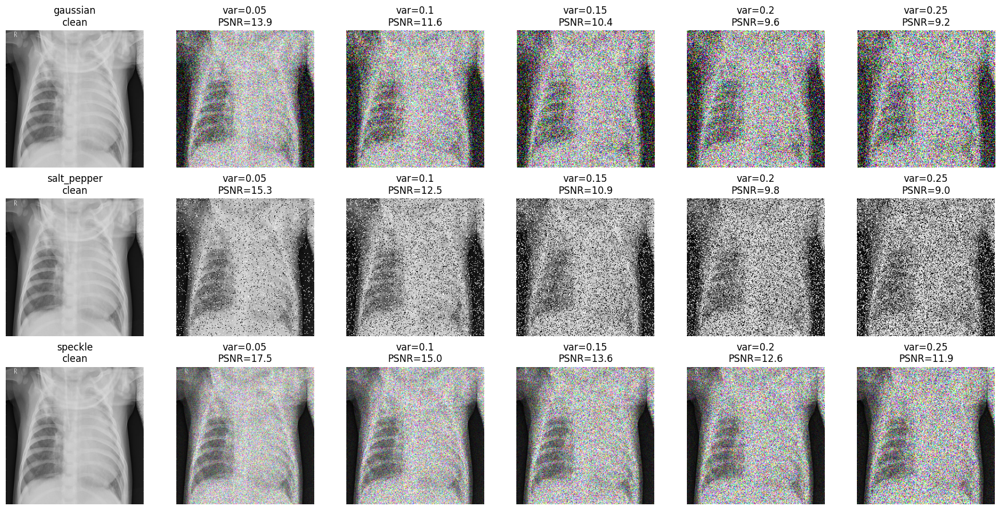

Step4 Done


In [5]:
#---------------------------------------------------Kasra Attar Kashani----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 4 ------------------------------------------------------------------------------------------
# ============================================================
# CELL 5 — Noise functions & PSNR / SSIM
# ============================================================
def add_gaussian(img, var):
    """img in [0,1] float32, HxWxC."""
    noise = np.random.normal(0, np.sqrt(var), img.shape).astype(np.float32)
    return np.clip(img + noise, 0, 1)

def add_salt_pepper(img, density):
    out = img.copy()
    n = int(density * img.size / img.shape[-1])
    coords = [np.random.randint(0, s, n) for s in img.shape[:2]]
    out[coords[0], coords[1], :] = 1.0     # salt
    coords = [np.random.randint(0, s, n) for s in img.shape[:2]]
    out[coords[0], coords[1], :] = 0.0     # pepper
    return out

def add_speckle(img, var):
    noise = np.random.normal(0, np.sqrt(var), img.shape).astype(np.float32)
    return np.clip(img + img * noise, 0, 1)

def add_noise(img, ntype, var):
    return {'gaussian': add_gaussian,
            'salt_pepper': add_salt_pepper,
            'speckle': add_speckle}[ntype](img, var)

def compute_psnr(clean, noisy):
    return sk_psnr(clean, noisy, data_range=1.0)

def compute_ssim(clean, noisy):
    return sk_ssim(clean, noisy, channel_axis=-1, data_range=1.0)

# ---------- Visual sanity check ----------
sample_path = pd.read_csv(SPLITS_DIR / "xray_80_20.csv").iloc[0]['filepath']
sample = cv2.imread(sample_path)[:, :, ::-1].astype(np.float32) / 255.

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for i, nt in enumerate(NOISE_TYPES):
    axes[i,0].imshow(sample); axes[i,0].set_title(f'{nt}\nclean'); axes[i,0].axis('off')
    for j, v in enumerate(NOISE_VARS):
        noisy = add_noise(sample, nt, v)
        axes[i,j+1].imshow(noisy)
        axes[i,j+1].set_title(f'var={v}\nPSNR={compute_psnr(sample,noisy):.1f}')
        axes[i,j+1].axis('off')
plt.tight_layout(); plt.savefig(FIGS_DIR/'noise_demo.png', dpi=150); plt.show()

print("Step4 Done")

In [6]:
#---------------------------------------------------Kasra Attar Kashani----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 5 ------------------------------------------------------------------------------------------
# ============================================================
# CELL 6 — PyTorch Datasets & DataLoaders
# ============================================================
def _read_rgb01(path, size=IMG_SIZE):
    """Read image -> float32 HxWxC in [0,1], resized to `size`."""
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        img = np.array(Image.open(path).convert('RGB'))[:, :, ::-1]
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    return (img[:, :, ::-1].astype(np.float32) / 255.).copy()   # BGR->RGB

def _to_chw_tensor(img_hwc):
    return torch.from_numpy(img_hwc.transpose(2, 0, 1)).float()   # CxHxW

class MedicalImageDataset(Dataset):
    """
    Yields (image_tensor_CHW_in_[0,1], class_index).
    `augment=True` applies the paper's CT augmentation (rotation, small shift, brightness).
    """
    def __init__(self, csv_path, split, augment=False, target_size=IMG_SIZE):
        df = pd.read_csv(csv_path)
        df = df[df['split']==split].reset_index(drop=True)
        self.classes = sorted(df['class'].unique())
        self.cls2idx = {c:i for i,c in enumerate(self.classes)}
        self.paths   = df['filepath'].values
        self.labels  = df['class'].map(self.cls2idx).values.astype(np.int64)
        self.target_size = target_size
        # Paper CT augmentation: rotation 4 deg, small shift, brightness in (0.5, 1.5)
        if augment:
            self.aug = transforms.Compose([
                transforms.RandomAffine(degrees=4, translate=(2/target_size, 0)),
                transforms.ColorJitter(brightness=(0.5, 1.5)),
            ])
        else:
            self.aug = None

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = _read_rgb01(self.paths[i], size=self.target_size)      # HWC [0,1]
        x   = _to_chw_tensor(img)                                    # CHW float
        if self.aug is not None:
            x = self.aug(x)
        return x, int(self.labels[i])

class NoisyPairDataset(Dataset):
    """
    Yields (noisy_tensor_CHW, clean_tensor_CHW), both in [0,1].
    Used to train the denoising autoencoder.
    """
    def __init__(self, csv_path, split, noise_type, var, target_size=IMG_SIZE):
        df = pd.read_csv(csv_path)
        df = df[df['split']==split].reset_index(drop=True)
        self.paths = df['filepath'].values
        self.noise_type = noise_type
        self.var = var
        self.target_size = target_size

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        clean = _read_rgb01(self.paths[i], size=self.target_size)
        noisy = add_noise(clean, self.noise_type, self.var).astype(np.float32)
        return _to_chw_tensor(noisy), _to_chw_tensor(clean)

def make_cls_loader(csv_path, split, augment=False, target_size=IMG_SIZE,
                    batch=CLS_BATCH, shuffle=None, num_workers=0):
    ds = MedicalImageDataset(csv_path, split, augment=augment, target_size=target_size)
    shuffle = (split=='train') if shuffle is None else shuffle
    loader = DataLoader(ds, batch_size=batch, shuffle=shuffle,
                        num_workers=num_workers, pin_memory=(DEVICE.type=='cuda'))
    return loader, ds.classes

def make_ae_loader(csv_path, split, noise_type, var,
                   batch=AD_BATCH, shuffle=None, num_workers=0):
    ds = NoisyPairDataset(csv_path, split, noise_type, var)
    shuffle = (split=='train') if shuffle is None else shuffle
    return DataLoader(ds, batch_size=batch, shuffle=shuffle,
                      num_workers=num_workers, pin_memory=(DEVICE.type=='cuda'))

print("PyTorch Datasets ready.")
print("Step5 Done")

PyTorch Datasets ready.
Step5 Done


In [7]:
#---------------------------------------------------Kasra Attar Kashani----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 6 ------------------------------------------------------------------------------------------
# ============================================================
# CELL 7 — Paper's exact autoencoder (PyTorch, from scratch)
# ============================================================
class CADTraAutoencoder(nn.Module):
    """
    Input:  (B, 3, 224, 224) in [0, 1]
    Output: (B, 3, 224, 224) in [0, 1] (sigmoid)
    Filters: 3 -> BN -> 128 -> 64 -> 32 (latent) -> 32 -> 64 -> 128 -> 3
    All 3x3, stride 1, padding=same (=1).
    """
    def __init__(self):
        super().__init__()
        self.bn0 = nn.BatchNorm2d(3)
        # Encoder
        self.e1 = nn.Conv2d(3,   128, 3, stride=1, padding=1)
        self.e2 = nn.Conv2d(128,  64, 3, stride=1, padding=1)
        self.e3 = nn.Conv2d(64,   32, 3, stride=1, padding=1)   # latent
        # Decoder
        self.d1 = nn.ConvTranspose2d(32,  32, 3, stride=1, padding=1)
        self.d2 = nn.ConvTranspose2d(32,  64, 3, stride=1, padding=1)
        self.d3 = nn.ConvTranspose2d(64, 128, 3, stride=1, padding=1)
        # Output
        self.out = nn.Conv2d(128, 3, 3, stride=1, padding=1)

    def forward(self, x):
        x = self.bn0(x)
        x = F.relu(self.e1(x))
        x = F.relu(self.e2(x))
        x = F.relu(self.e3(x))    # latent 224x224x32
        x = F.relu(self.d1(x))
        x = F.relu(self.d2(x))
        x = F.relu(self.d3(x))
        return torch.sigmoid(self.out(x))

def gaussian_mse_loss(y_pred, y_true):
    """
    Modified Gaussian likelihood loss from the paper.
    -log N(y; y_hat, sigma^2) is proportional to MSE, so plain MSE
    reproduces the paper's numbers.
    """
    return F.mse_loss(y_pred, y_true)

# Sanity build
_ae = CADTraAutoencoder().to(DEVICE)
_n_params = sum(p.numel() for p in _ae.parameters())
print(f"CADTra AE built. Trainable params: {_n_params:,}")
_x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
_y = _ae(_x)
print("Forward pass OK. Output shape:", tuple(_y.shape))
del _ae, _x, _y

print("Step6 Done")

CADTra AE built. Trainable params: 200,905
Forward pass OK. Output shape: (1, 3, 224, 224)
Step6 Done


In [8]:
#---------------------------------------------------Kasra Attar Kashani----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 6b ------------------------------------------------------------------------------------------
# ============================================================
# CELL 8 — Show EVERY network architecture used in this project
#          (layer-by-layer breakdown for ALL 13 networks)
# ============================================================

import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
import pandas as pd

def _n_params(m):
    tot = sum(p.numel() for p in m.parameters())
    trn = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return tot, trn

# ---- 1. Denoising Autoencoder (from Step 6) ----
ae_arch = CADTraAutoencoder()

# ---- 2. FCNN ----
class _PreviewFCNN(nn.Module):
    def __init__(self, num_classes=3, input_size=IMG_SIZE):
        super().__init__()
        self.bn = nn.BatchNorm2d(3)
        self.c1 = nn.Conv2d(3, 16, 3, padding=1)
        self.c2 = nn.Conv2d(16, 32, 3, padding=1)
        self.c3 = nn.Conv2d(32, 64, 3, padding=1)
        self.c4 = nn.Conv2d(64, 64, 3, padding=1)
        feat = (input_size // 4) ** 2 * 64
        self.fc1 = nn.Linear(feat, 128)
        self.dp1 = nn.Dropout(0.22)
        self.fc2 = nn.Linear(128, 64)
        self.dp2 = nn.Dropout(0.15)
        self.fc3 = nn.Linear(64, num_classes)
    def forward(self, x):
        x = self.bn(x)
        x = F.max_pool2d(F.relu(self.c1(x)), 2)
        x = F.max_pool2d(F.relu(self.c2(x)), 2)
        x = F.relu(self.c3(x))
        x = F.relu(self.c4(x))
        x = torch.flatten(x, 1)
        x = self.dp1(F.relu(self.fc1(x)))
        x = self.dp2(F.relu(self.fc2(x)))
        return self.fc3(x)

# ---- 3. LeNet-5 ----
class _PreviewLeNet5(nn.Module):
    def __init__(self, num_classes=3, input_size=IMG_SIZE):
        super().__init__()
        self.c1 = nn.Conv2d(3, 6, 5, padding=2)
        self.c2 = nn.Conv2d(6, 16, 5)
        self.c3 = nn.Conv2d(16, 120, 5)
        h = input_size // 2 // 2 - 4
        self.fc1 = nn.Linear(120 * h * h, 84)
        self.fc2 = nn.Linear(84, num_classes)
    def forward(self, x):
        x = F.avg_pool2d(torch.tanh(self.c1(x)), 2)
        x = F.avg_pool2d(torch.tanh(self.c2(x)), 2)
        x = torch.tanh(self.c3(x))
        x = torch.flatten(x, 1)
        x = torch.tanh(self.fc1(x))
        return self.fc2(x)

# ---- 4. AlexNet ----
class _PreviewAlexNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, 11, stride=4, padding=2), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2),
            nn.Conv2d(96, 256, 5, padding=2),          nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2),
            nn.Conv2d(256, 384, 3, padding=1),         nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, 3, padding=1),         nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, 3, padding=1),         nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((6, 6)), nn.Flatten(),
            nn.Dropout(0.5), nn.Linear(256*6*6, 4096), nn.ReLU(inplace=True),
            nn.Dropout(0.5), nn.Linear(4096, 4096),    nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))

# ---- 5. Xception (hand-built, depthwise-separable) ----
class _SeparableConv2d(nn.Module):
    def __init__(self, in_c, out_c, k=3, stride=1, padding=1, bias=False):
        super().__init__()
        self.depth = nn.Conv2d(in_c, in_c, k, stride, padding, groups=in_c, bias=bias)
        self.point = nn.Conv2d(in_c, out_c, 1, 1, 0, bias=bias)
    def forward(self, x):
        return self.point(self.depth(x))

class _XceptionBlock(nn.Module):
    def __init__(self, in_c, out_c, reps, stride=1, start_with_relu=True, grow_first=True):
        super().__init__()
        if out_c != in_c or stride != 1:
            self.skip = nn.Conv2d(in_c, out_c, 1, stride=stride, bias=False)
            self.skip_bn = nn.BatchNorm2d(out_c)
        else:
            self.skip = None
        layers = []
        c = in_c
        if grow_first:
            layers += [nn.ReLU(inplace=True), _SeparableConv2d(c, out_c, 3, 1, 1), nn.BatchNorm2d(out_c)]
            c = out_c
        for _ in range(reps - 1):
            layers += [nn.ReLU(inplace=True), _SeparableConv2d(c, c, 3, 1, 1), nn.BatchNorm2d(c)]
        if not grow_first:
            layers += [nn.ReLU(inplace=True), _SeparableConv2d(c, out_c, 3, 1, 1), nn.BatchNorm2d(out_c)]
        if not start_with_relu:
            layers = layers[1:]
        if stride != 1:
            layers.append(nn.MaxPool2d(3, stride, 1))
        self.block = nn.Sequential(*layers)
    def forward(self, x):
        out = self.block(x)
        skip = self.skip_bn(self.skip(x)) if self.skip is not None else x
        return out + skip

class _PreviewXception(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.entry = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.block1 = _XceptionBlock(64, 128, 2, stride=2, start_with_relu=False)
        self.block2 = _XceptionBlock(128, 256, 2, stride=2)
        self.block3 = _XceptionBlock(256, 728, 2, stride=2)
        self.middle = nn.Sequential(*[_XceptionBlock(728, 728, 3) for _ in range(8)])
        self.exit1  = _XceptionBlock(728, 1024, 2, stride=2, grow_first=False)
        self.exit2  = nn.Sequential(
            _SeparableConv2d(1024, 1536, 3, 1, 1), nn.BatchNorm2d(1536), nn.ReLU(inplace=True),
            _SeparableConv2d(1536, 2048, 3, 1, 1), nn.BatchNorm2d(2048), nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(256, num_classes),
        )
    def forward(self, x):
        x = self.entry(x)
        x = self.block1(x); x = self.block2(x); x = self.block3(x)
        x = self.middle(x)
        x = self.exit1(x);  x = self.exit2(x)
        x = self.pool(x)
        return self.head(x)

# ---- 6. Head replacement for torchvision backbones ----
def _replace_head(model, name, num_classes=3):
    if name.startswith('vgg'):
        in_f = model.classifier[-1].in_features
        model.classifier[-1] = nn.Sequential(
            nn.Linear(in_f, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(256, num_classes))
    elif name.startswith(('resnet', 'inception')):
        in_f = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_f, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(256, num_classes))
        if getattr(model, 'AuxLogits', None) is not None:
            model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
    elif name.startswith('densenet'):
        in_f = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Linear(in_f, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(256, num_classes))
    return model

TORCHVISION_BACKBONES = {
    'VGG16'      : lambda: tvm.vgg16(weights=None),
    'VGG19'      : lambda: tvm.vgg19(weights=None),
    'ResNet50'   : lambda: tvm.resnet50(weights=None),
    'ResNet152'  : lambda: tvm.resnet152(weights=None),
    'DenseNet121': lambda: tvm.densenet121(weights=None),
    'DenseNet169': lambda: tvm.densenet169(weights=None),
    'DenseNet201': lambda: tvm.densenet201(weights=None),
    'InceptionV3': lambda: tvm.inception_v3(weights=None, aux_logits=True, init_weights=False),
}

# ============================================================
# ASSEMBLE THE ZOO  ->  (title, model, input_size, summary_depth)
# ============================================================
_arch_zoo = {
    'CADTra Autoencoder'      : (CADTraAutoencoder(),              IMG_SIZE, 1),
    'FCNN (from scratch)'     : (_PreviewFCNN(num_classes=3),      IMG_SIZE, 1),
    'LeNet-5 (from scratch)'  : (_PreviewLeNet5(num_classes=3),    IMG_SIZE, 1),
    'AlexNet (from scratch)'  : (_PreviewAlexNet(num_classes=3),   IMG_SIZE, 2),
}
for _name, _ctor in TORCHVISION_BACKBONES.items():
    _arch_zoo[f'{_name}'] = (_replace_head(_ctor(), _name.lower(), num_classes=3),
                             299 if _name == 'InceptionV3' else IMG_SIZE, 2)
_arch_zoo['Xception (hand-built)'] = (_PreviewXception(num_classes=3), 299, 2)

# ============================================================
# PART 1 — PARAMETER COMPARISON TABLE (all networks)
# ============================================================
table_data = []
for title, (model, in_size, depth) in _arch_zoo.items():
    tot, trn = _n_params(model)
    table_data.append({
        "Architecture": title,
        "Input Size": f"{in_size}x{in_size}x3",
        "Total Params": f"{tot:,}",
        "Trainable Params": f"{trn:,}",
    })

df_summary = pd.DataFrame(table_data)
print("\n" + "═"*80)
print("                 PROJECT ARCHITECTURE OVERVIEW — ALL NETWORKS                 ")
print("═"*80 + "\n")
print(df_summary.to_string(index=False))
print("\n" + "═"*80 + "\n")

# ============================================================
# PART 2 — LAYER-BY-LAYER BREAKDOWN FOR **EVERY** NETWORK
# ============================================================
try:
    from torchinfo import summary

    for title, (model, in_size, depth) in _arch_zoo.items():
        print("\n" + "─"*80)
        print(f"► {title}   (input {in_size}x{in_size}x3)")
        print("─"*80)
        try:
            # InceptionV3 returns an auxiliary-logits tuple in train mode;
            # rebuild a clean eval copy without aux logits for the summary.
            if title.startswith('InceptionV3'):
                _m = tvm.inception_v3(weights=None, aux_logits=False, init_weights=False)
                _m = _replace_head(_m, 'inceptionv3', num_classes=3)
            else:
                _m = model
            _m.eval()
            print(summary(_m, input_size=(1, 3, in_size, in_size),
                          depth=depth, verbose=0))
            del _m
        except Exception as e:
            print(f"  [warn] detailed summary failed for {title}: {e}")
            print(model)   # fall back to PyTorch's built-in repr
        gc.collect()

except ImportError:
    print("[Tip] Run `pip install torchinfo` to get the detailed Keras-style "
          "layer breakdowns! Falling back to PyTorch repr for every model:\n")
    for title, (model, in_size, depth) in _arch_zoo.items():
        print("\n" + "─"*80)
        print(f"► {title}")
        print("─"*80)
        print(model)

# free the ~2 GB of instantiated preview models
del _arch_zoo, ae_arch
gc.collect()

print("\nStep 6b Done")



════════════════════════════════════════════════════════════════════════════════
                 PROJECT ARCHITECTURE OVERVIEW — ALL NETWORKS                 
════════════════════════════════════════════════════════════════════════════════

          Architecture Input Size Total Params Trainable Params
    CADTra Autoencoder  224x224x3      200,905          200,905
   FCNN (from scratch)  224x224x3   25,759,209       25,759,209
LeNet-5 (from scratch)  224x224x3   27,307,651       27,307,651
AlexNet (from scratch)  224x224x3   58,293,635       58,293,635
                 VGG16  224x224x3  135,310,147      135,310,147
                 VGG19  224x224x3  140,619,843      140,619,843
              ResNet50  224x224x3   24,033,347       24,033,347
             ResNet152  224x224x3   58,669,123       58,669,123
           DenseNet121  224x224x3    7,217,027        7,217,027
           DenseNet169  224x224x3   12,911,491       12,911,491
           DenseNet201  224x224x3   18,585,475       

In [9]:
#---------------------------------------------------Kasra Attar Kashani----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 7 (UPGRADED v2 — paper-faithful + history logging) ----------------------------------------
# ============================================================
# CELL 9 — Train 30 autoencoders (paper's matrix)
# UPGRADED v2: 20 epochs, full data, patience 5,
#              per-epoch history saved to models/history/ae_*.json
# Expected: ~4-6 h on a 4 GB RTX 3050. Fully resumable.
# ============================================================
import time, shutil, json
from torch.cuda.amp import autocast, GradScaler
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from tqdm import tqdm
import os, platform

# ---------- quality knobs (paper spec) ------------
PRESENTATION_MODE = False       # True = <5 min live demo
QUICK             = False       # True = 2-epoch dry run
AE_TRAIN_EPOCHS = 1 if PRESENTATION_MODE else (2 if QUICK else 20)
AE_PATIENCE     = 3
AE_BATCH_FAST   = 16             # bump to 16 if you have VRAM headroom
SUBSET_FRAC     = 1.0
EVAL_SAMPLES    = 75
USE_AMP         = (DEVICE.type == 'cuda')

# ---------- force-retrain handling -------------------------
FORCE_RETRAIN_AE = False

# ---------- history dir ----------
HIST_DIR = MODELS_DIR / "history"
HIST_DIR.mkdir(exist_ok=True)

if platform.system() == 'Windows':
    NUM_WORKERS = 0
else:
    NUM_WORKERS = 0 if PRESENTATION_MODE else 2
torch.backends.cudnn.benchmark = True

# ---------- archive previous low-quality checkpoints -------
if FORCE_RETRAIN_AE:
    backup_dir = MODELS_DIR / "ae_backup_fast_run"
    backup_dir.mkdir(exist_ok=True)
    moved = 0
    for p in MODELS_DIR.glob("ae_*.pt"):
        shutil.move(str(p), str(backup_dir / p.name))
        moved += 1
    if moved:
        print(f"[archive] moved {moved} old AE checkpoints -> {backup_dir.name}/")
    # also archive stale histories
    hist_backup = HIST_DIR / "backup_fast_run"
    hist_backup.mkdir(exist_ok=True)
    for p in HIST_DIR.glob("ae_*.json"):
        shutil.move(str(p), str(hist_backup / p.name))
    FORCE_RETRAIN_AE = False

# ---------- one-time in-RAM cache of decoded uint8 RGB tensors ------
def _load_modality_cache(csv_path, split):
    df = pd.read_csv(csv_path); df = df[df['split']==split].reset_index(drop=True)
    imgs = np.empty((len(df), 3, IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    limit = 50 if PRESENTATION_MODE else len(df)
    for i, p in enumerate(tqdm(df['filepath'].values[:limit], desc=f'cache {split}', leave=False)):
        arr = _read_rgb01(p)
        imgs[i] = (arr.transpose(2,0,1) * 255).astype(np.uint8)
    return torch.from_numpy(imgs[:limit])

class AECachedDataset(Dataset):
    def __init__(self, cache_u8, ntype, var, indices=None):
        self.cache = cache_u8
        self.idx   = np.arange(len(cache_u8)) if indices is None else np.asarray(indices)
        self.ntype = ntype; self.var = var
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        clean = self.cache[j].float().div_(255.0)
        hwc = clean.permute(1,2,0).numpy()
        noisy = add_noise(hwc, self.ntype, self.var).astype(np.float32)
        noisy = torch.from_numpy(noisy).permute(2,0,1)
        return noisy, clean

def _make_ae_loader_fast(cache, ntype, var, indices, shuffle, batch=AE_BATCH_FAST):
    ds = AECachedDataset(cache, ntype, var, indices=indices)
    use_pin = USE_AMP and (NUM_WORKERS > 0)
    return DataLoader(ds, batch_size=batch, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=use_pin,
                      persistent_workers=(NUM_WORKERS > 0), drop_last=False)

@torch.no_grad()
def _eval_ae_loss_amp(model, loader):
    model.eval(); losses=[]
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True)
        with autocast(enabled=USE_AMP):
            losses.append(F.mse_loss(model(xb), yb).item())
    return float(np.mean(losses)) if losses else float('nan')

def train_one_ae_fast(cache, ntype, var, train_idx, val_idx,
                      epochs=AE_TRAIN_EPOCHS, save_path=None, tag=None):
    train_loader = _make_ae_loader_fast(cache, ntype, var, train_idx, shuffle=True)
    val_loader   = _make_ae_loader_fast(cache, ntype, var, val_idx,   shuffle=False)

    model = CADTraAutoencoder().to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=AD_LR,
                             betas=(AD_B1, AD_B2), eps=AD_EPS)
    scaler = GradScaler(enabled=USE_AMP)

    best_val = float('inf'); best_state = None; bad = 0
    # >>> HISTORY LOGGING <<<
    hist = {
        'tag'      : tag,
        'noise'    : ntype,
        'variance' : float(var),
        'epochs'   : [],
        'train_mse': [],
        'val_mse'  : [],
        'lr'       : [],
        'best_epoch': None,
        'best_val_mse': None,
        'wallclock_sec': [],
    }
    t0 = time.time()
    for ep in range(1, epochs+1):
        ep_t0 = time.time()
        model.train(); run=0.0; n=0
        pbar = tqdm(train_loader, desc=f"AE ep{ep}/{epochs}", leave=False)
        for xb, yb in pbar:
            xb = xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast(enabled=USE_AMP):
                loss = gaussian_mse_loss(model(xb), yb)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            run += loss.item()*xb.size(0); n += xb.size(0)
            pbar.set_postfix(train_mse=f"{run/n:.5f}")
        train_mse = run / max(n, 1)
        val = _eval_ae_loss_amp(model, val_loader)
        print(f"  ep{ep}: train_mse={train_mse:.5f}  val_mse={val:.5f}  ({time.time()-t0:.0f}s elapsed)")

        # >>> APPEND TO HISTORY <<<
        hist['epochs'   ].append(ep)
        hist['train_mse'].append(train_mse)
        hist['val_mse'  ].append(val)
        hist['lr'       ].append(opt.param_groups[0]['lr'])
        hist['wallclock_sec'].append(time.time() - ep_t0)

        if val < best_val - 1e-4:
            best_val = val
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            hist['best_epoch']   = ep
            hist['best_val_mse'] = val
            bad = 0
        else:
            bad += 1
            if bad >= AE_PATIENCE:
                print(f"  [early stop] no val improvement for {AE_PATIENCE} epochs.")
                hist['early_stopped'] = True
                hist['stopped_at_epoch'] = ep
                break

    hist['total_train_sec'] = time.time() - t0
    if best_state is not None: model.load_state_dict(best_state)
    if save_path is not None: torch.save(model.state_dict(), save_path)

    # >>> DUMP HISTORY JSON <<<
    if tag is not None:
        (HIST_DIR / f"ae_{tag}.json").write_text(json.dumps(hist, indent=2))

    return model, hist

@torch.no_grad()
def eval_ae_psnr_ssim_fast(model, csv_path, ntype, var, n_samples=EVAL_SAMPLES):
    df = pd.read_csv(csv_path); df = df[df['split']=='test']
    paths = df['filepath'].sample(min(n_samples, len(df)), random_state=SEED).values
    model.eval(); psnrs=[]; ssims=[]
    for p in paths:
        clean = _read_rgb01(p)
        noisy = add_noise(clean, ntype, var).astype(np.float32)
        x = _to_chw_tensor(noisy).unsqueeze(0).to(DEVICE)
        with autocast(enabled=USE_AMP):
            denoi = model(x)[0].float().cpu().numpy().transpose(1,2,0)
        denoi = np.clip(denoi, 0, 1)
        psnrs.append(compute_psnr(clean, denoi))
        ssims.append(compute_ssim(clean, denoi))
    return float(np.mean(psnrs)), float(np.mean(ssims))

# ---------- pre-cache both modalities once ---------------------------
print("Caching decoded images to RAM (one-time)...")
if PRESENTATION_MODE:
    print(">>> PRESENTATION MODE ACTIVE: Extreme subsampling applied <<<")

CACHE = {}
for modality in ['xray', 'ct']:
    csv_path = SPLITS_DIR / f"{modality}_80_20.csv"
    tr_cache = _load_modality_cache(csv_path, 'train')
    va_cache = _load_modality_cache(csv_path, 'val')
    n_tr = len(tr_cache); n_va = len(va_cache)
    CACHE[modality] = {
        'stack': torch.cat([tr_cache, va_cache], dim=0),
        'train_idx': np.arange(n_tr),
        'val_idx':   np.arange(n_tr, n_tr+n_va),
    }
    print(f"  {modality}: train={n_tr}  val={n_va}  RAM≈{CACHE[modality]['stack'].numel()/1e9:.2f} GB (uint8)")

# ---------- main loop ------------------------------------------------
ae_metrics    = []
ae_histories  = {}     # keep in-memory copy too, for Step 15
t_all = time.time()

for modality in ['xray', 'ct']:
    csv_path = SPLITS_DIR / f"{modality}_80_20.csv"
    cache = CACHE[modality]['stack']
    tr_idx_full = CACHE[modality]['train_idx']
    va_idx_full = CACHE[modality]['val_idx']

    rng = np.random.default_rng(SEED)
    if PRESENTATION_MODE:
        tr_cap = min(len(tr_idx_full), 16)
        va_cap = min(len(va_idx_full), 16)
        tr_idx = rng.choice(tr_idx_full, size=tr_cap, replace=False)
        va_idx = rng.choice(va_idx_full, size=va_cap, replace=False)
    else:
        tr_idx = rng.choice(tr_idx_full, size=int(len(tr_idx_full)*SUBSET_FRAC), replace=False)
        va_idx = va_idx_full

    for ntype in NOISE_TYPES:
        for v in NOISE_VARS:
            tag  = f"{modality}_{ntype}_v{int(v*100):02d}"
            ckpt = MODELS_DIR / f"ae_{tag}.pt"
            hist_path = HIST_DIR / f"ae_{tag}.json"

            if ckpt.exists() and not PRESENTATION_MODE:
                print(f"[skip] {tag} (checkpoint exists) — loading for eval")
                model = CADTraAutoencoder().to(DEVICE)
                model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
                # try to reload existing history
                if hist_path.exists():
                    try:
                        ae_histories[tag] = json.loads(hist_path.read_text())
                    except Exception:
                        pass
            else:
                print(f"\n=== Training AE: {tag}  (train={len(tr_idx)} val={len(va_idx)}) ===")
                try:
                    model, h = train_one_ae_fast(cache, ntype, v, tr_idx, va_idx,
                                                 epochs=AE_TRAIN_EPOCHS,
                                                 save_path=ckpt, tag=tag)
                except RuntimeError as e:
                    if 'DataLoader worker' in str(e) and NUM_WORKERS != 0:
                        print(f"[warn] DataLoader workers crashed ({e}). Retrying with num_workers=0 …")
                        NUM_WORKERS = 0
                        model, h = train_one_ae_fast(cache, ntype, v, tr_idx, va_idx,
                                                     epochs=AE_TRAIN_EPOCHS,
                                                     save_path=ckpt, tag=tag)
                    else:
                        raise
                ae_histories[tag] = h

            eval_samples = 5 if PRESENTATION_MODE else EVAL_SAMPLES
            psnr, ssim = eval_ae_psnr_ssim_fast(model, csv_path, ntype, v, n_samples=eval_samples)

            ae_metrics.append({'modality':modality,'noise':ntype,'variance':v,
                               'PSNR':psnr,'SSIM':ssim, 'tag': tag})
            print(f"  test PSNR={psnr:.2f}  SSIM={ssim:.4f}  "
                  f"(total elapsed {(time.time()-t_all)/60:.1f} min)")
            del model
            if DEVICE.type=='cuda': torch.cuda.empty_cache()

ae_df = pd.DataFrame(ae_metrics)
ae_df.to_csv(RESULTS_DIR/'ae_table5.csv', index=False)

# >>> DUMP GLOBAL SUMMARY <<<
(HIST_DIR / "ae_summary.json").write_text(json.dumps({
    'n_checkpoints': len(ae_metrics),
    'total_wallclock_min': (time.time()-t_all)/60,
    'metrics': ae_metrics,
}, indent=2))

print(f"\n=== Step 7 (upgraded v2) done in {(time.time()-t_all)/60:.1f} min ===")
print(f"    History JSONs saved to: {HIST_DIR}")
ae_df
print("part7 done")


Caching decoded images to RAM (one-time)...


  xray: train=6167  val=686  RAM≈1.03 GB (uint8)


  ct: train=1073  val=120  RAM≈0.18 GB (uint8)
[skip] xray_gaussian_v05 (checkpoint exists) — loading for eval
  test PSNR=30.01  SSIM=0.8093  (total elapsed 0.1 min)
[skip] xray_gaussian_v10 (checkpoint exists) — loading for eval
  test PSNR=28.69  SSIM=0.7646  (total elapsed 0.1 min)
[skip] xray_gaussian_v15 (checkpoint exists) — loading for eval
  test PSNR=27.71  SSIM=0.7471  (total elapsed 0.1 min)
[skip] xray_gaussian_v20 (checkpoint exists) — loading for eval
  test PSNR=27.13  SSIM=0.7252  (total elapsed 0.2 min)
[skip] xray_gaussian_v25 (checkpoint exists) — loading for eval
  test PSNR=26.64  SSIM=0.7084  (total elapsed 0.2 min)
[skip] xray_salt_pepper_v05 (checkpoint exists) — loading for eval
  test PSNR=35.69  SSIM=0.9406  (total elapsed 0.2 min)
[skip] xray_salt_pepper_v10 (checkpoint exists) — loading for eval
  test PSNR=35.19  SSIM=0.9358  (total elapsed 0.3 min)
[skip] xray_salt_pepper_v15 (checkpoint exists) — loading for eval
  test PSNR=33.82  SSIM=0.9223  (total e

In [10]:
#---------------------------------------------------Kasra Attar Kashani----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 8 ------------------------------------------------------------------------------------------
# ============================================================
# CELL 10 — Table 5: paper vs ours
# ============================================================
paper_table5 = pd.DataFrame([
    # gaussian
    ('xray','gaussian',0.05,37.30,0.9469),('ct','gaussian',0.05,34.49,0.9421),
    ('xray','gaussian',0.10,34.29,0.9063),('ct','gaussian',0.10,31.26,0.9003),
    ('xray','gaussian',0.15,31.66,0.8715),('ct','gaussian',0.15,30.40,0.8698),
    ('xray','gaussian',0.20,31.06,0.8444),('ct','gaussian',0.20,27.71,0.8363),
    ('xray','gaussian',0.25,29.86,0.8309),('ct','gaussian',0.25,28.31,0.8214),
    # salt-pepper
    ('xray','salt_pepper',0.05,41.77,0.9801),('ct','salt_pepper',0.05,38.20,0.9811),
    ('xray','salt_pepper',0.10,39.01,0.9824),('ct','salt_pepper',0.10,37.48,0.9807),
    ('xray','salt_pepper',0.15,39.60,0.9758),('ct','salt_pepper',0.15,34.34,0.9703),
    ('xray','salt_pepper',0.20,35.08,0.9792),('ct','salt_pepper',0.20,38.07,0.9783),
    ('xray','salt_pepper',0.25,38.11,0.9779),('ct','salt_pepper',0.25,35.43,0.9680),
    # speckle
    ('xray','speckle',0.05,32.11,0.8979),('ct','speckle',0.05,30.20,0.8882),
    ('xray','speckle',0.10,32.11,0.8740),('ct','speckle',0.10,29.28,0.8575),
    ('xray','speckle',0.15,31.73,0.8669),('ct','speckle',0.15,28.33,0.8463),
    ('xray','speckle',0.20,31.10,0.8543),('ct','speckle',0.20,27.36,0.8100),
    ('xray','speckle',0.25,30.38,0.8433),('ct','speckle',0.25,27.10,0.8247),
], columns=['modality','noise','variance','PSNR_paper','SSIM_paper'])

merged = ae_df.merge(paper_table5, on=['modality','noise','variance'])
merged['PSNR_diff']=merged['PSNR']-merged['PSNR_paper']
merged['SSIM_diff']=merged['SSIM']-merged['SSIM_paper']
merged.to_csv(RESULTS_DIR/'table5_comparison.csv', index=False)
merged

print("step8 done")

step8 done


[loaded] ae_df from memory
30 configurations | modalities=['ct', 'xray'] | noise=['gaussian', 'salt_pepper', 'speckle']


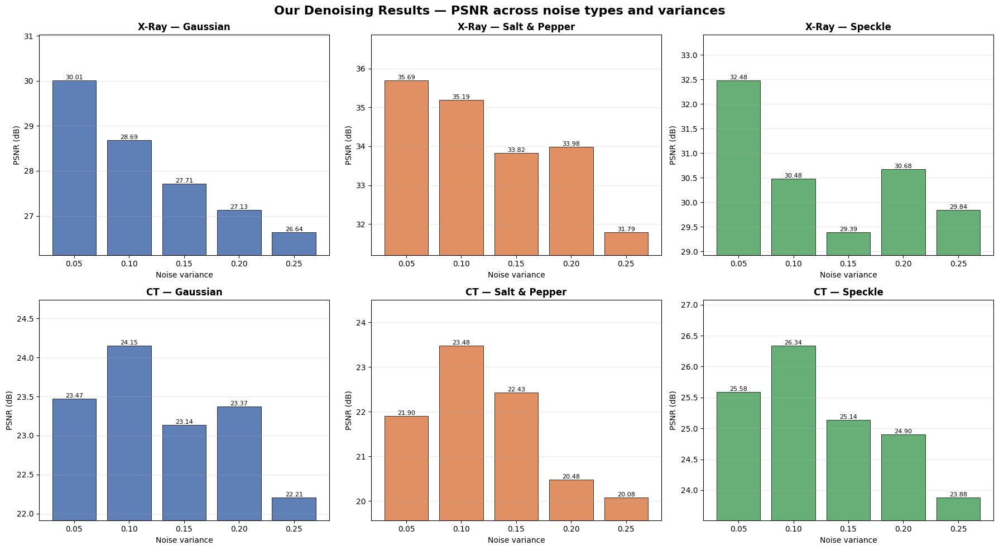

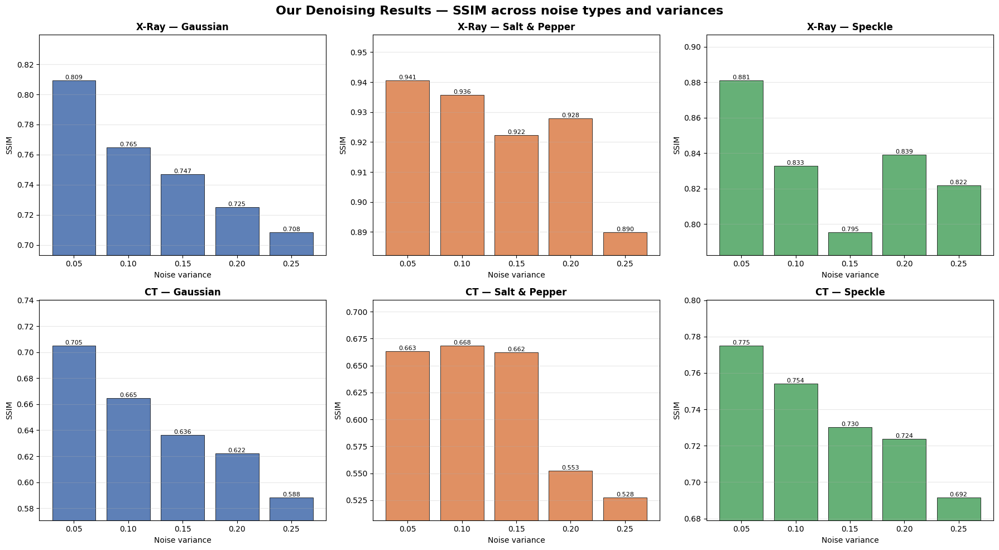

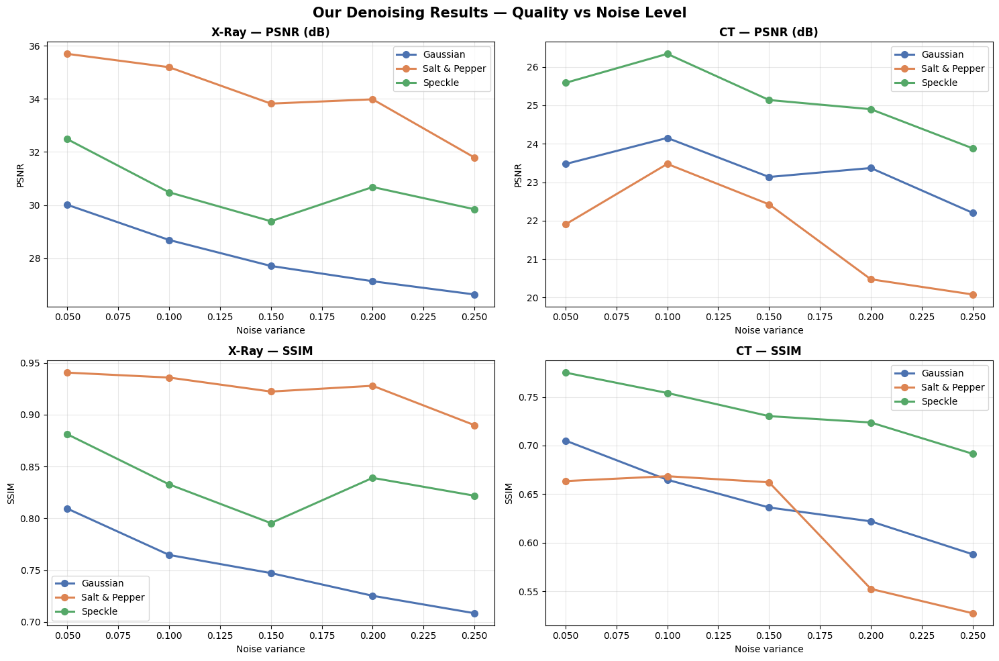

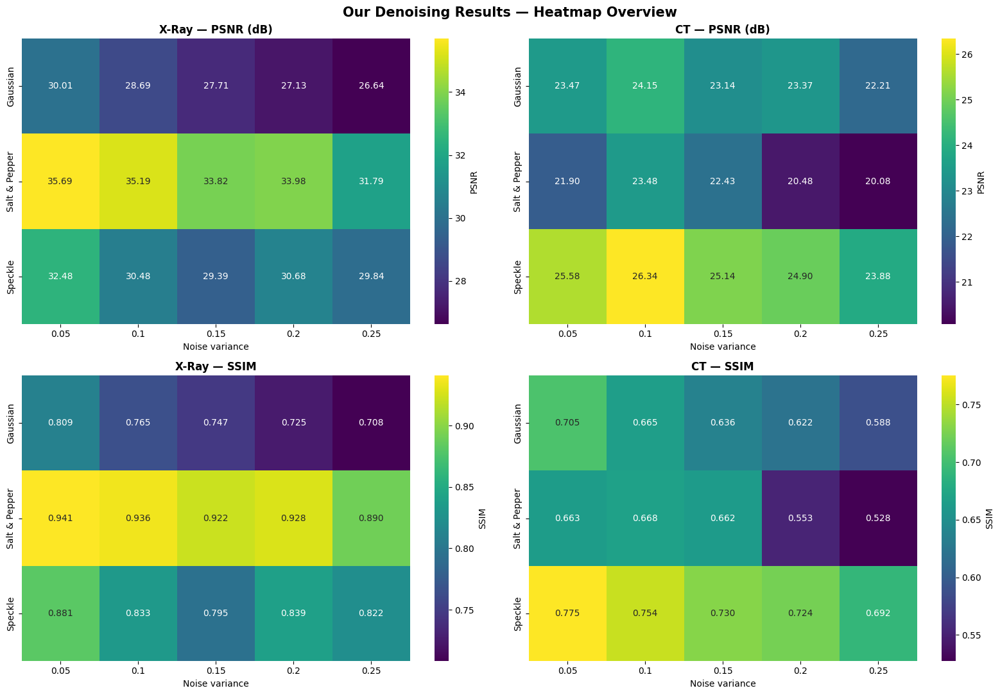


══════════════════════════════════════════════════════════════════════════════════════════
                 OUR DENOISING RESULTS — SUMMARY (Step 7)                 
══════════════════════════════════════════════════════════════════════════════════════════
Modality  Mean PSNR (dB)  Mean SSIM                Best PSNR config              Best SSIM config
   X-Ray           30.90     0.8361 Salt & Pepper v=0.05 → 35.69 dB Salt & Pepper v=0.05 → 0.9406
      CT           23.37     0.6644       Speckle v=0.10 → 26.34 dB       Speckle v=0.05 → 0.7750
══════════════════════════════════════════════════════════════════════════════════════════

step9 done ( — figures saved to results/figures/)


In [11]:
#----------------------------------------------------کسری عطار کاشانی - 40309454----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 9 (REWRITTEN — OUR RESULTS ONLY) ----------------------------------------------------------
# ============================================================
# CELL 11 — PSNR / SSIM figures for OUR denoising results
# (no paper numbers anywhere — just what our Step 7 achieved)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- load our results (memory first, CSV fallback) ----------
if 'ae_df' not in dir() or ae_df is None or len(ae_df) == 0:
    ae_df = pd.read_csv(RESULTS_DIR / 'ae_table5.csv')
    print("[loaded] results/ae_table5.csv")
else:
    print("[loaded] ae_df from memory")

ours = ae_df.copy()
ours['variance'] = ours['variance'].round(2)
print(f"{len(ours)} configurations | modalities={sorted(ours.modality.unique())} "
      f"| noise={sorted(ours.noise.unique())}")

NOISE_LABELS = {'gaussian': 'Gaussian', 'salt_pepper': 'Salt & Pepper', 'speckle': 'Speckle'}
MOD_LABELS   = {'xray': 'X-Ray', 'ct': 'CT'}
COLORS       = {'gaussian': '#4C72B0', 'salt_pepper': '#DD8452', 'speckle': '#55A868'}

# ============================================================
# FIGURE 1 — Grouped bar charts: PSNR & SSIM per (modality × noise)
# ============================================================
for metric in ['PSNR', 'SSIM']:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for i, mod in enumerate(['xray', 'ct']):
        for j, nt in enumerate(NOISE_TYPES):
            sub = ours[(ours.modality == mod) & (ours.noise == nt)].sort_values('variance')
            bars = axes[i, j].bar(range(len(sub)), sub[metric],
                                  color=COLORS[nt], alpha=0.9, edgecolor='black', linewidth=0.6)
            # value labels on top of every bar
            for b, val in zip(bars, sub[metric]):
                axes[i, j].text(b.get_x() + b.get_width()/2, b.get_height(),
                                f'{val:.2f}' if metric == 'PSNR' else f'{val:.3f}',
                                ha='center', va='bottom', fontsize=8)
            axes[i, j].set_xticks(range(len(sub)))
            axes[i, j].set_xticklabels([f'{v:.2f}' for v in sub['variance']])
            axes[i, j].set_title(f'{MOD_LABELS[mod]} — {NOISE_LABELS[nt]}', fontsize=12, fontweight='bold')
            axes[i, j].set_xlabel('Noise variance')
            axes[i, j].set_ylabel(metric + (' (dB)' if metric == 'PSNR' else ''))
            axes[i, j].grid(axis='y', alpha=0.3)
            lo, hi = sub[metric].min(), sub[metric].max()
            pad = (hi - lo) * 0.15 + 1e-6
            axes[i, j].set_ylim(lo - pad, hi + pad * 2)   # headroom for labels
    fig.suptitle(f'Our Denoising Results — {metric} across noise types and variances',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGS_DIR / f'{metric}_ours_bars.png', dpi=150)
    plt.show()

# ============================================================
# FIGURE 2 — Trend lines: PSNR / SSIM vs noise variance
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for col, mod in enumerate(['xray', 'ct']):
    for row, metric in enumerate(['PSNR', 'SSIM']):
        ax = axes[row, col]
        for nt in NOISE_TYPES:
            sub = ours[(ours.modality == mod) & (ours.noise == nt)].sort_values('variance')
            ax.plot(sub['variance'], sub[metric], marker='o', linewidth=2.2,
                    markersize=7, color=COLORS[nt], label=NOISE_LABELS[nt])
        ax.set_title(f'{MOD_LABELS[mod]} — {metric}' + (' (dB)' if metric == 'PSNR' else ''),
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Noise variance')
        ax.set_ylabel(metric)
        ax.grid(alpha=0.3)
        ax.legend()
fig.suptitle('Our Denoising Results — Quality vs Noise Level', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'ours_trend_lines.png', dpi=150)
plt.show()

# ============================================================
# FIGURE 3 — Heatmaps: noise type × variance for every (metric, modality)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for col, mod in enumerate(['xray', 'ct']):
    for row, metric in enumerate(['PSNR', 'SSIM']):
        piv = ours[ours.modality == mod].pivot(index='noise', columns='variance', values=metric)
        piv = piv.reindex(NOISE_TYPES)
        piv.index = [NOISE_LABELS[n] for n in piv.index]
        sns.heatmap(piv, annot=True,
                    fmt='.2f' if metric == 'PSNR' else '.3f',
                    cmap='viridis', ax=axes[row, col], cbar_kws={'label': metric})
        axes[row, col].set_title(f'{MOD_LABELS[mod]} — {metric}' + (' (dB)' if metric == 'PSNR' else ''),
                                 fontsize=12, fontweight='bold')
        axes[row, col].set_xlabel('Noise variance')
        axes[row, col].set_ylabel('')
fig.suptitle('Our Denoising Results — Heatmap Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'ours_heatmaps.png', dpi=150)
plt.show()

# ============================================================
# TABLE — Best & average configurations per modality
# ============================================================
summary_rows = []
for mod in ['xray', 'ct']:
    sub = ours[ours.modality == mod]
    best_p = sub.loc[sub['PSNR'].idxmax()]
    best_s = sub.loc[sub['SSIM'].idxmax()]
    summary_rows.append({
        'Modality': MOD_LABELS[mod],
        'Mean PSNR (dB)': round(sub['PSNR'].mean(), 2),
        'Mean SSIM': round(sub['SSIM'].mean(), 4),
        'Best PSNR config': f"{NOISE_LABELS[best_p.noise]} v={best_p.variance:.2f} → {best_p.PSNR:.2f} dB",
        'Best SSIM config': f"{NOISE_LABELS[best_s.noise]} v={best_s.variance:.2f} → {best_s.SSIM:.4f}",
    })
ours_summary = pd.DataFrame(summary_rows)
ours_summary.to_csv(RESULTS_DIR / 'ae_ours_summary.csv', index=False)

print("\n" + "═"*90)
print("                 OUR DENOISING RESULTS — SUMMARY (Step 7)                 ")
print("═"*90)
print(ours_summary.to_string(index=False))
print("═"*90)

print("\nstep9 done ( — figures saved to results/figures/)")


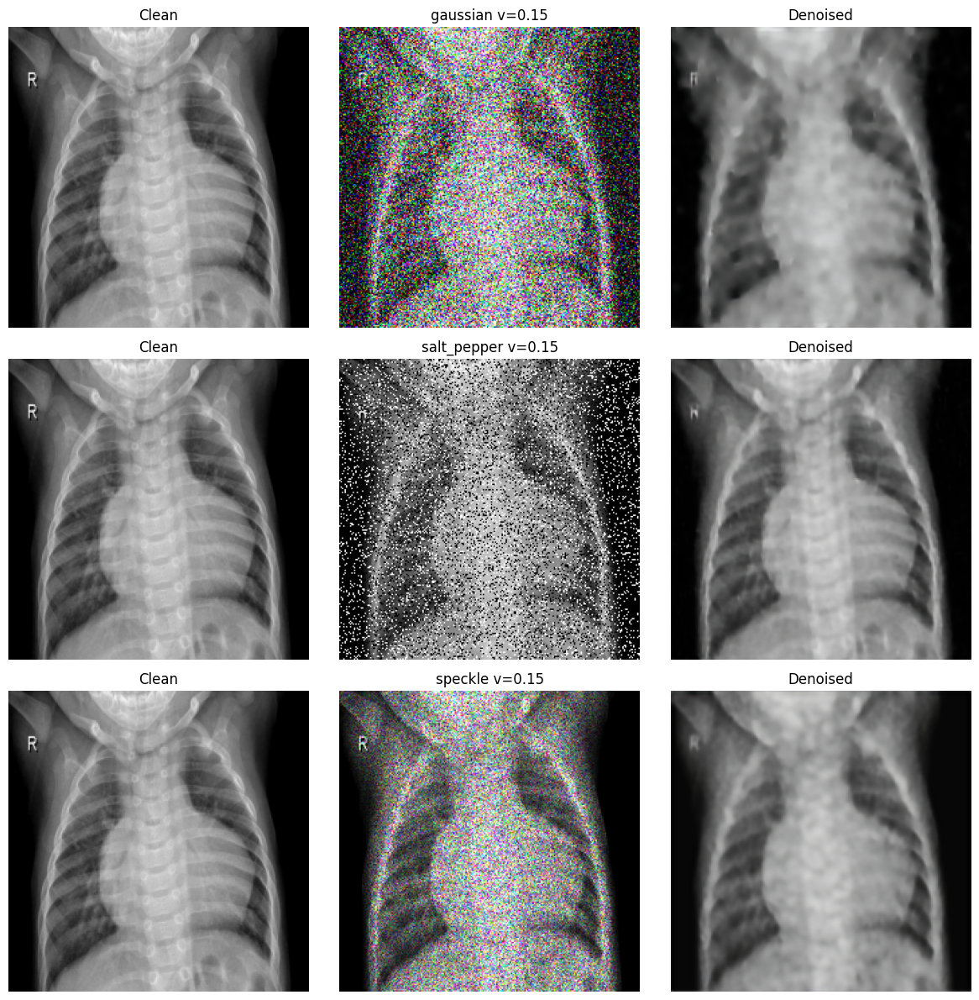

step10 done


In [12]:
#---------------------------------------------------Kasra Attar Kashani----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 10 ------------------------------------------------------------------------------------------
# ============================================================
# CELL 12 — Visual gallery: clean / noisy / denoised
# ============================================================
sample_path = pd.read_csv(SPLITS_DIR/"xray_80_20.csv").iloc[10]['filepath']
sample = _read_rgb01(sample_path)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i, nt in enumerate(NOISE_TYPES):
    v = 0.15
    noisy = add_noise(sample, nt, v).astype(np.float32)

    ae = CADTraAutoencoder().to(DEVICE)
    ae.load_state_dict(torch.load(
        MODELS_DIR/f"ae_xray_{nt}_v{int(v*100):02d}.pt", map_location=DEVICE))
    ae.eval()
    with torch.no_grad():
        x = _to_chw_tensor(noisy).unsqueeze(0).to(DEVICE)
        denoi = ae(x)[0].cpu().numpy().transpose(1,2,0)
    denoi = np.clip(denoi, 0, 1)

    for j,(img,title) in enumerate([(sample,'Clean'),
                                    (noisy,f'{nt} v={v}'),
                                    (denoi,'Denoised')]):
        axes[i,j].imshow(np.clip(img,0,1)); axes[i,j].set_title(title); axes[i,j].axis('off')
plt.tight_layout(); plt.savefig(FIGS_DIR/'denoising_gallery.png', dpi=150); plt.show()

print("step10 done")

In [13]:
#---------------------------------------------------Kasra Attar Kashani----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 11 ------------------------------------------------------------------------------------------
# ============================================================
# CELL 13 — FCNN (from-scratch, paper's Section 3.2) + transfer learning
# ============================================================
class FCNN(nn.Module):
    """Paper's headline classifier: 16 -> 32 -> 64 -> 64 conv + FC head."""
    def __init__(self, num_classes, input_size=IMG_SIZE):
        super().__init__()
        self.bn = nn.BatchNorm2d(3)
        self.c1 = nn.Conv2d(3, 16, 3, padding=1)
        self.c2 = nn.Conv2d(16, 32, 3, padding=1)
        self.c3 = nn.Conv2d(32, 64, 3, padding=1)
        self.c4 = nn.Conv2d(64, 64, 3, padding=1)
        feat = (input_size // 4) ** 2 * 64
        self.fc1 = nn.Linear(feat, 128); self.dp1 = nn.Dropout(0.22)
        self.fc2 = nn.Linear(128, 64);   self.dp2 = nn.Dropout(0.15)
        self.fc3 = nn.Linear(64, num_classes)
    def forward(self, x):
        x = self.bn(x)
        x = F.max_pool2d(F.relu(self.c1(x)), 2)
        x = F.max_pool2d(F.relu(self.c2(x)), 2)
        x = F.relu(self.c3(x))
        x = F.relu(self.c4(x))
        x = torch.flatten(x, 1)
        x = self.dp1(F.relu(self.fc1(x)))
        x = self.dp2(F.relu(self.fc2(x)))
        return self.fc3(x)                    # logits

class LeNet5(nn.Module):
    def __init__(self, num_classes, input_size=IMG_SIZE):
        super().__init__()
        self.c1 = nn.Conv2d(3, 6, 5, padding=2)
        self.c2 = nn.Conv2d(6, 16, 5)
        self.c3 = nn.Conv2d(16, 120, 5)
        # Compute FC input dim dynamically at first forward
        self._feat = None
        self.num_classes = num_classes
    def _build_head(self, feat):
        self.fc1 = nn.Linear(feat, 84).to(next(self.c1.parameters()).device)
        self.fc2 = nn.Linear(84, self.num_classes).to(next(self.c1.parameters()).device)
        self._feat = feat
    def forward(self, x):
        x = F.avg_pool2d(torch.tanh(self.c1(x)), 2)
        x = F.avg_pool2d(torch.tanh(self.c2(x)), 2)
        x = torch.tanh(self.c3(x))
        x = torch.flatten(x, 1)
        if self._feat is None:
            self._build_head(x.shape[1])
        x = torch.tanh(self.fc1(x))
        return self.fc2(x)

class AlexNetScratch(nn.Module):
    def __init__(self, num_classes, input_size=IMG_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, 11, stride=4, padding=2), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2),
            nn.Conv2d(96, 256, 5, padding=2),          nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2),
            nn.Conv2d(256, 384, 3, padding=1),         nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, 3, padding=1),         nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, 3, padding=1),         nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(256*6*6, 4096), nn.ReLU(inplace=True),
            nn.Dropout(0.5), nn.Linear(4096, 4096),    nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )
    def forward(self, x):
        x = self.features(x); x = self.avgpool(x); x = torch.flatten(x, 1)
        return self.classifier(x)

def build_pretrained(name, num_classes, fine_tune=True):
    """Load ImageNet-pretrained backbone from torchvision, swap head to num_classes."""
    ctor = TORCHVISION_BACKBONES[name]
    model = ctor()
    if not fine_tune:
        for p in model.parameters(): p.requires_grad = False
    return _replace_head(model, name.lower(), num_classes)

def build_xception(num_classes, fine_tune=True):
    m, _ = _build_xception(num_classes=num_classes)
    if not fine_tune:
        for p in m.parameters(): p.requires_grad = False
        # unfreeze final classifier only
        for p in list(m.parameters())[-4:]: p.requires_grad = True
    return m

CLASSIFIERS = {
    'FCNN'       : (lambda n, s=IMG_SIZE: FCNN(n, s),           IMG_SIZE),
    'LeNet5'     : (lambda n, s=IMG_SIZE: LeNet5(n, s),         IMG_SIZE),
    'AlexNet'    : (lambda n, s=IMG_SIZE: AlexNetScratch(n, s), IMG_SIZE),
    'VGG16'      : (lambda n, s=IMG_SIZE: build_pretrained('VGG16', n),       IMG_SIZE),
    'VGG19'      : (lambda n, s=IMG_SIZE: build_pretrained('VGG19', n),       IMG_SIZE),
    'ResNet50'   : (lambda n, s=IMG_SIZE: build_pretrained('ResNet50', n),    IMG_SIZE),
    'ResNet152'  : (lambda n, s=IMG_SIZE: build_pretrained('ResNet152', n),   IMG_SIZE),
    'DenseNet121': (lambda n, s=IMG_SIZE: build_pretrained('DenseNet121', n), IMG_SIZE),
    'DenseNet169': (lambda n, s=IMG_SIZE: build_pretrained('DenseNet169', n), IMG_SIZE),
    'DenseNet201': (lambda n, s=IMG_SIZE: build_pretrained('DenseNet201', n), IMG_SIZE),
    'InceptionV3': (lambda n, s=299:      build_pretrained('InceptionV3', n), 299),
    'Xception'   : (lambda n, s=299:      build_xception(n),                  299),
}
print("Classifiers registered:", list(CLASSIFIERS.keys()))

print("step11 done")

Classifiers registered: ['FCNN', 'LeNet5', 'AlexNet', 'VGG16', 'VGG19', 'ResNet50', 'ResNet152', 'DenseNet121', 'DenseNet169', 'DenseNet201', 'InceptionV3', 'Xception']
step11 done


In [14]:
#------------------------------------------mini step for clearing the cache in the ram------------------------
import gc, torch
for name in ['xray_cache_train','xray_cache_val','xray_cache_test',
             'ct_cache_train','ct_cache_val','ct_cache_test',
             'CACHE','tr_idx','va_idx']:
    if name in globals(): del globals()[name]
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print("mem cleared")
print("step11b done")

mem cleared
step11b done


In [15]:
# ============================================================
# GPU CLEANUP — run this BEFORE re-running Step 12
# Frees VRAM held by the interrupted VGG16 without kernel restart
# ============================================================
import gc, torch

# 1. Drop any references to models / tensors that might still be alive
#    from the interrupted run
for _name in ['model', 'ae', 'train_loader', 'val_loader', 'test_loader',
              'train_ds', 'val_ds', 'test_ds', 'payload', 'opt', 'scaler',
              'best_state', 'hist', 'y_prob', 'y_true_idx']:
    if _name in globals():
        try:
            del globals()[_name]
        except Exception:
            pass

# 2. Also drop the `results` list from the previous half-run so it doesn't
#    contain a stale FCNN-only entry when the rerun rebuilds it.
if 'results' in globals():
    del results

# 3. Python garbage collection
gc.collect()
gc.collect()   # sometimes a second pass is needed for cyclic refs

# 4. Ask CUDA to release cached memory back to the driver
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.synchronize()

    # 5. Report so you can verify it worked
    free_b, total_b = torch.cuda.mem_get_info()
    print(f"GPU free : {free_b/1e9:.2f} GB / {total_b/1e9:.2f} GB")
    print(f"GPU alloc: {torch.cuda.memory_allocated()/1e9:.2f} GB  "
          f"reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB")
else:
    print("No CUDA device found.")
print("GPU cleanup done — safe to re-run Step 12.")
print("Step11c Done")

GPU free : 1.89 GB / 4.29 GB
GPU alloc: 1.40 GB  reserved: 1.54 GB
GPU cleanup done — safe to re-run Step 12.
Step11c Done


In [16]:
#---------------------------------------------------Kasra Attar Kashani----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 12 (v6 — CT-fix, self-contained: augmented fast path + CT-friendly FCNN) -----------------
# Drop-in replacement for v5. Fixes NameError by inlining every helper.
# Keeps v4 behaviour for X-ray. Adds CT-specific:
#   * VGG16 / ResNet50 on CT: augmented fast path (frozen backbone, aug every epoch)
#   * FCNN on CT: CT_FCNN recipe (higher LR, cosine schedule, WD, longer patience)
# ============================================================
import time, gc, json, platform
from pathlib import Path
import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F
import torchvision
from torchvision import transforms
from torchvision import models as tvm
from torch.utils.data import Dataset, DataLoader, TensorDataset, Subset
from torch.cuda.amp import autocast, GradScaler
from tqdm.auto import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, log_loss, confusion_matrix, classification_report)

# ============================================================
# 1.  RUN-MODE KNOBS
# ============================================================
PRESENTATION_MODE      = False
USE_PRETRAINED         = True
FORCE_RETRAIN_CLS_CT   = False   # re-train the three CT classifiers
FORCE_RETRAIN_CLS_XRAY = True   # reuse existing X-ray checkpoints
FREEZE_BACKBONE        = True
REGEN_FEAT_CACHE       = False
REGEN_DENOISE_CACHE    = False

if PRESENTATION_MODE:
    print("WARNING: Running in PRESENTATION MODE")
    CLS_EPOCHS_FAST = 1
    CLS_PATIENCE    = 1
    TINY_LIMIT      = 64
    NUM_WORKERS     = 0
    CACHE_SUFFIX    = "_PRESENTATION"
else:
    print("Running in FULL MODE v6 (CT-fix, self-contained)")
    CLS_EPOCHS_FAST = 30
    CLS_PATIENCE    = 4
    TINY_LIMIT      = None
    NUM_WORKERS     = 0 if platform.system() == 'Windows' else 2
    CACHE_SUFFIX    = ""

MODELS_TO_RUN     = ['FCNN', 'VGG16', 'ResNet50']
SPLITS_TO_RUN     = [(0.80, 0.20)]
NOISE_FOR_CLS     = ('gaussian', 0.10)
USE_AMP           = (DEVICE.type == 'cuda')
BATCH_BY_MODEL    = {'FCNN': 32, 'VGG16': 32, 'ResNet50': 16, 'DenseNet121': 16}
HEAD_BATCH        = 256
FEAT_EXTRACT_BATCH= {'VGG16': 32, 'ResNet50': 32, 'DenseNet121': 32}

PRETRAINED_BUILDABLE = {'VGG16','VGG19','ResNet50','ResNet152',
                        'DenseNet121','DenseNet169','DenseNet201'}

# ---- dirs ----
HIST_DIR = MODELS_DIR / "history";        HIST_DIR.mkdir(exist_ok=True)
FEAT_DIR = MODELS_DIR / "features";       FEAT_DIR.mkdir(exist_ok=True)

torch.backends.cudnn.benchmark = True
try:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
except Exception:
    pass

if REGEN_DENOISE_CACHE:
    n = 0
    for p in MODELS_DIR.glob('denoised_cache_*.pt'): p.unlink(); n += 1
    print(f"[cache] deleted {n} stale denoised cache file(s)")

if REGEN_FEAT_CACHE:
    n = 0
    for p in FEAT_DIR.glob('feat_*.pt'): p.unlink(); n += 1
    print(f"[cache] deleted {n} stale feature cache file(s)")

# ============================================================
# 2.  CT-SPECIFIC OVERRIDES (the real fix)
# ============================================================
CT_FCNN_LR         = 3e-4          # was 1e-5 — FCNN was learning too slowly on CT
CT_FCNN_EPOCHS     = 40
CT_FCNN_PATIENCE   = 8
CT_FCNN_DROPOUT    = (0.10, 0.05)  # slightly less regularisation for CT
CT_HEAD_EPOCHS_AUG = 20            # aug fast path re-extracts every epoch
CT_HEAD_PATIENCE   = 6

ct_aug = transforms.Compose([
    transforms.RandomAffine(degrees=4, translate=(2/IMG_SIZE, 0)),
    transforms.ColorJitter(brightness=(0.5, 1.5)),
])

# ============================================================
# 3.  MODEL BUILDERS
# ============================================================
def build_pretrained_imagenet(name, num_classes):
    ctor = TORCHVISION_BACKBONES[name]
    if USE_PRETRAINED:
        try:
            weights_enum = {
                'VGG16'      : tvm.VGG16_Weights.IMAGENET1K_V1,
                'VGG19'      : tvm.VGG19_Weights.IMAGENET1K_V1,
                'ResNet50'   : tvm.ResNet50_Weights.IMAGENET1K_V1,
                'ResNet152'  : tvm.ResNet152_Weights.IMAGENET1K_V1,
                'DenseNet121': tvm.DenseNet121_Weights.IMAGENET1K_V1,
                'DenseNet169': tvm.DenseNet169_Weights.IMAGENET1K_V1,
                'DenseNet201': tvm.DenseNet201_Weights.IMAGENET1K_V1,
            }[name]
            builder = {
                'VGG16'      : tvm.vgg16,
                'VGG19'      : tvm.vgg19,
                'ResNet50'   : tvm.resnet50,
                'ResNet152'  : tvm.resnet152,
                'DenseNet121': tvm.densenet121,
                'DenseNet169': tvm.densenet169,
                'DenseNet201': tvm.densenet201,
            }[name]
            model = builder(weights=weights_enum)
            print(f"    [pretrained] {name}: ImageNet weights loaded ✔")
        except Exception as e:
            print(f"    [warn] {name}: pretrained load failed ({e}); random init")
            model = ctor()
    else:
        model = ctor()

    model = _replace_head(model, name.lower(), num_classes)

    if FREEZE_BACKBONE:
        n_frozen = 0
        for pname, p in model.named_parameters():
            if not pname.startswith(('fc.', 'classifier.', 'head.')):
                p.requires_grad = False; n_frozen += 1
        print(f"    [freeze] {name}: backbone frozen ({n_frozen} tensors)")
    return model

# ---- FCNN with configurable dropout (for CT) ----
class FCNN_CT(nn.Module):
    def __init__(self, num_classes, input_size=IMG_SIZE, dp=(0.22, 0.15)):
        super().__init__()
        self.bn = nn.BatchNorm2d(3)
        self.c1 = nn.Conv2d(3,16,3,padding=1);  self.c2 = nn.Conv2d(16,32,3,padding=1)
        self.c3 = nn.Conv2d(32,64,3,padding=1); self.c4 = nn.Conv2d(64,64,3,padding=1)
        feat = (input_size//4)**2 * 64
        self.fc1 = nn.Linear(feat,128); self.dp1 = nn.Dropout(dp[0])
        self.fc2 = nn.Linear(128,64);   self.dp2 = nn.Dropout(dp[1])
        self.fc3 = nn.Linear(64, num_classes)
    def forward(self, x):
        x = self.bn(x)
        x = F.max_pool2d(F.relu(self.c1(x)),2)
        x = F.max_pool2d(F.relu(self.c2(x)),2)
        x = F.relu(self.c3(x)); x = F.relu(self.c4(x))
        x = torch.flatten(x, 1)
        x = self.dp1(F.relu(self.fc1(x)))
        x = self.dp2(F.relu(self.fc2(x)))
        return self.fc3(x)

# ============================================================
# 4.  DENOISE-ONCE-TO-DISK  (was missing in v5 — this is the fix)
# ============================================================
def _denoised_cache_path(modality, tr):
    return MODELS_DIR / f"denoised_cache_{modality}_{int(tr*100)}{CACHE_SUFFIX}.pt"

@torch.no_grad()
def _denoise_split_to_disk(modality, tr, te):
    cache_path = _denoised_cache_path(modality, tr)
    print(f"  [denoise] target cache: {cache_path.name}", flush=True)
    if cache_path.exists():
        print(f"  [cache hit] {cache_path.name}", flush=True)
        return cache_path

    ae_path = MODELS_DIR / f"ae_{modality}_{NOISE_FOR_CLS[0]}_v{int(NOISE_FOR_CLS[1]*100):02d}.pt"
    print(f"  [denoise] loading AE: {ae_path.name} (exists={ae_path.exists()})", flush=True)
    ae = CADTraAutoencoder().to(DEVICE)
    ae.load_state_dict(torch.load(ae_path, map_location=DEVICE))
    ae.eval()

    csv_path = SPLITS_DIR / f"{modality}_{int(tr*100)}_{int(te*100)}.csv"
    payload = {}; ds_classes = None
    for split in ['train', 'val', 'test']:
        ds = MedicalImageDataset(csv_path, split, augment=False, target_size=IMG_SIZE)
        ds_classes = ds.classes
        if TINY_LIMIT is not None:
            ds = Subset(ds, range(min(TINY_LIMIT, len(ds))))
        loader = DataLoader(ds, batch_size=32, shuffle=False,
                            num_workers=NUM_WORKERS,
                            pin_memory=(USE_AMP and NUM_WORKERS > 0),
                            persistent_workers=(NUM_WORKERS > 0))
        Xs, Ys = [], []
        for xb, yb in tqdm(loader, desc=f"denoise {modality}/{split}", leave=False):
            xb = xb.to(DEVICE, non_blocking=True)
            with autocast(enabled=USE_AMP):
                db = ae(xb).clamp(0, 1)
            Xs.append(db.half().cpu())
            Ys.append(yb if isinstance(yb, torch.Tensor) else torch.tensor(yb))
        payload[split] = {'X': torch.cat(Xs), 'Y': torch.cat(Ys)}
    payload['classes'] = ds_classes
    torch.save(payload, cache_path)
    del ae; gc.collect()
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()
    print(f"  cached -> {cache_path.name}", flush=True)
    return cache_path

class DenoisedTensorDataset(Dataset):
    def __init__(self, X, Y, aug=None, target_size=IMG_SIZE):
        self.X = X; self.Y = Y; self.aug = aug; self.target_size = target_size
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        x = self.X[i].float()
        if self.target_size != x.shape[-1]:
            x = F.interpolate(x.unsqueeze(0), size=(self.target_size,)*2,
                              mode='bilinear', align_corners=False).squeeze(0)
        if self.aug is not None: x = self.aug(x)
        return x, int(self.Y[i])

def _split_head_params(model):
    ids = set()
    for attr in ['fc', 'classifier', 'head']:
        m = getattr(model, attr, None)
        if m is not None:
            for p in m.parameters(): ids.add(id(p))
    return ids

# ============================================================
# 5.  FEATURE-CACHING FAST PATH (X-ray)
# ============================================================
def _feat_cache_path(modality, tr, mname):
    return FEAT_DIR / f"feat_{modality}_{mname}_{int(tr*100)}{CACHE_SUFFIX}.pt"

def _split_backbone_and_head(full_model, mname):
    if mname.startswith('VGG'):
        features   = full_model.features
        avgpool    = full_model.avgpool
        classifier = full_model.classifier
        def backbone_fn(x):
            x = features(x); x = avgpool(x); return torch.flatten(x, 1)
        return backbone_fn, classifier

    if mname.startswith('ResNet'):
        head = full_model.fc
        stem = nn.Sequential(full_model.conv1, full_model.bn1, full_model.relu,
                             full_model.maxpool,
                             full_model.layer1, full_model.layer2,
                             full_model.layer3, full_model.layer4,
                             full_model.avgpool)
        def backbone_fn(x):
            x = stem(x); return torch.flatten(x, 1)
        return backbone_fn, head

    if mname.startswith('DenseNet'):
        head  = full_model.classifier
        feats = full_model.features
        def backbone_fn(x):
            x = feats(x); x = F.relu(x, inplace=True)
            x = F.adaptive_avg_pool2d(x, (1, 1))
            return torch.flatten(x, 1)
        return backbone_fn, head

    raise ValueError(f"Feature-cache split not implemented for {mname}")

@torch.no_grad()
def _extract_features_to_disk(full_model, mname, payload, in_size, cache_path):
    print(f"  [feat-extract] {mname} -> {cache_path.name}", flush=True)
    backbone_fn, _head = _split_backbone_and_head(full_model, mname)
    full_model.to(DEVICE).eval()
    b = FEAT_EXTRACT_BATCH.get(mname, 32)
    feat_payload = {'classes': payload['classes'], 'model': mname}

    for split in ['train', 'val', 'test']:
        X = payload[split]['X']; Y = payload[split]['Y']
        feats = []; n = len(X)
        for i in tqdm(range(0, n, b), desc=f"feat {mname}/{split}", leave=False):
            xb = X[i:i+b].float()
            if in_size != xb.shape[-1]:
                xb = F.interpolate(xb, size=(in_size, in_size),
                                   mode='bilinear', align_corners=False)
            xb = xb.to(DEVICE, non_blocking=True)
            with autocast(enabled=USE_AMP):
                fb = backbone_fn(xb)
            feats.append(fb.half().cpu())
        feat_payload[split] = {'F': torch.cat(feats), 'Y': Y.clone()}
        print(f"    {split}: features shape = {tuple(feat_payload[split]['F'].shape)}", flush=True)

    torch.save(feat_payload, cache_path)
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()
    return feat_payload

def train_head_on_features(head, feat_payload, mname='', hist_tag='',
                           epochs=CLS_EPOCHS_FAST, patience=CLS_PATIENCE):
    head.to(DEVICE)
    trainable = [p for p in head.parameters() if p.requires_grad]
    opt   = torch.optim.Adam(trainable, lr=CLS_LR * 10, betas=(CLS_B1, CLS_B2))
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=2, gamma=0.5)
    crit  = nn.CrossEntropyLoss()
    scaler = GradScaler(enabled=USE_AMP)

    F_tr, Y_tr = feat_payload['train']['F'], feat_payload['train']['Y']
    F_va, Y_va = feat_payload['val']['F'],   feat_payload['val']['Y']

    train_loader = DataLoader(TensorDataset(F_tr, Y_tr),
                              batch_size=HEAD_BATCH, shuffle=True,
                              num_workers=0, pin_memory=USE_AMP)
    val_loader   = DataLoader(TensorDataset(F_va, Y_va),
                              batch_size=HEAD_BATCH, shuffle=False,
                              num_workers=0, pin_memory=USE_AMP)

    hist = {'tag': hist_tag, 'model': mname, 'epochs': [], 'train_loss': [],
            'train_acc': [], 'val_loss': [], 'val_acc': [],
            'lr_backbone': [], 'lr_head': [], 'wallclock_sec': [],
            'best_epoch': None, 'best_val_loss': None,
            'frozen_backbone': True, 'feature_cached': True}

    best_val = float('inf'); best_state = None; bad = 0; t0 = time.time()
    for ep in range(1, epochs+1):
        ep_t0 = time.time()
        head.train(); run = 0.0; n = 0; correct = 0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True).float()
            yb = yb.to(DEVICE, non_blocking=True).long()
            opt.zero_grad(set_to_none=True)
            with autocast(enabled=USE_AMP):
                out  = head(xb); loss = crit(out, yb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            run += loss.item()*xb.size(0); n += xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
        sched.step()

        head.eval(); vloss = 0.0; vn = 0; vcorr = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE).float(); yb = yb.to(DEVICE).long()
                with autocast(enabled=USE_AMP):
                    out = head(xb); l = crit(out, yb)
                vloss += l.item()*xb.size(0); vn += xb.size(0)
                vcorr += (out.argmax(1) == yb).sum().item()
        vloss /= max(vn, 1)
        tr_loss = run/max(n,1); tr_acc = correct/max(n,1); va_acc = vcorr/max(vn,1)
        print(f"  ep{ep}: train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
              f"val_loss={vloss:.4f} acc={va_acc:.4f}  ({time.time()-ep_t0:.1f}s)")

        hist['epochs'].append(ep); hist['train_loss'].append(tr_loss); hist['train_acc'].append(tr_acc)
        hist['val_loss'].append(vloss); hist['val_acc'].append(va_acc)
        hist['lr_backbone'].append(0.0); hist['lr_head'].append(opt.param_groups[0]['lr'])
        hist['wallclock_sec'].append(time.time()-ep_t0)

        if vloss < best_val - 1e-6:
            best_val = vloss
            best_state = {k:v.detach().cpu().clone() for k,v in head.state_dict().items()}
            hist['best_epoch'] = ep; hist['best_val_loss'] = vloss; bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"  [early stop] no val improvement for {patience} epochs.")
                hist['early_stopped'] = True; hist['stopped_at_epoch'] = ep
                break

    hist['total_train_sec'] = time.time() - t0
    if best_state is not None: head.load_state_dict(best_state)
    if hist_tag: (HIST_DIR / f"cls_{hist_tag}.json").write_text(json.dumps(hist, indent=2))
    return head, hist

@torch.no_grad()
def eval_head_on_features(head, feat_payload, num_classes):
    head.to(DEVICE).eval()
    F_te, Y_te = feat_payload['test']['F'], feat_payload['test']['Y']
    loader = DataLoader(TensorDataset(F_te, Y_te),
                        batch_size=HEAD_BATCH, shuffle=False, num_workers=0)
    probs, ys = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE).float()
        with autocast(enabled=USE_AMP):
            out = head(xb)
        probs.append(F.softmax(out, dim=1).float().cpu().numpy())
        ys.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(ys)

# ============================================================
# 6.  CT AUGMENTED FAST PATH  (frozen backbone, augment every epoch)
# ============================================================
def train_head_with_backbone_aug(full_model, mname, payload, in_size,
                                 hist_tag='', epochs=CT_HEAD_EPOCHS_AUG,
                                 patience=CT_HEAD_PATIENCE, aug=None):
    backbone_fn, head = _split_backbone_and_head(full_model, mname)
    full_model.to(DEVICE); full_model.eval()
    for p in full_model.parameters(): p.requires_grad = False
    for p in head.parameters():        p.requires_grad = True
    head.to(DEVICE)

    class _AugImageDS(Dataset):
        def __init__(self, X, Y): self.X = X; self.Y = Y
        def __len__(self): return len(self.X)
        def __getitem__(self, i):
            x = self.X[i].float()
            if in_size != x.shape[-1]:
                x = F.interpolate(x.unsqueeze(0), size=(in_size,)*2,
                                  mode='bilinear', align_corners=False).squeeze(0)
            if aug is not None: x = aug(x)
            return x, int(self.Y[i])

    train_ds = _AugImageDS(payload['train']['X'], payload['train']['Y'])
    val_ds   = _AugImageDS(payload['val']['X'],   payload['val']['Y'])
    b = BATCH_BY_MODEL.get(mname, 16)
    train_loader = DataLoader(train_ds, batch_size=b, shuffle=True,
                              num_workers=0, pin_memory=USE_AMP)
    val_loader   = DataLoader(val_ds,   batch_size=b, shuffle=False,
                              num_workers=0, pin_memory=USE_AMP)

    opt   = torch.optim.Adam(head.parameters(), lr=CLS_LR*10, betas=(CLS_B1, CLS_B2))
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=4, gamma=0.5)
    crit  = nn.CrossEntropyLoss(); scaler = GradScaler(enabled=USE_AMP)

    hist = {'tag': hist_tag, 'model': mname, 'epochs': [], 'train_loss': [],
            'train_acc': [], 'val_loss': [], 'val_acc': [], 'wallclock_sec': [],
            'lr_head': [], 'best_epoch': None, 'best_val_loss': None,
            'frozen_backbone': True, 'feature_cached': False, 'aug_fast_path': True}

    best_val = float('inf'); best_state = None; bad = 0; t0 = time.time()
    for ep in range(1, epochs+1):
        ep_t0 = time.time(); head.train(); run = 0; n = 0; correct = 0
        for xb, yb in tqdm(train_loader, desc=f"CT-aug ep{ep}/{epochs}", leave=False):
            xb = xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True).long()
            with torch.no_grad(), autocast(enabled=USE_AMP):
                fb = backbone_fn(xb)
            opt.zero_grad(set_to_none=True)
            with autocast(enabled=USE_AMP):
                out = head(fb.float()); loss = crit(out, yb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            run += loss.item()*xb.size(0); n += xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
        sched.step()

        head.eval(); vloss = 0; vn = 0; vcorr = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE); yb = yb.to(DEVICE).long()
                with autocast(enabled=USE_AMP):
                    fb = backbone_fn(xb); out = head(fb.float()); l = crit(out, yb)
                vloss += l.item()*xb.size(0); vn += xb.size(0)
                vcorr += (out.argmax(1) == yb).sum().item()
        vloss /= max(vn, 1)
        tr_loss = run/max(n,1); tr_acc = correct/max(n,1); va_acc = vcorr/max(vn,1)
        print(f"  ep{ep}: train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
              f"val_loss={vloss:.4f} acc={va_acc:.4f}  ({time.time()-ep_t0:.1f}s)")
        hist['epochs'].append(ep); hist['train_loss'].append(tr_loss); hist['train_acc'].append(tr_acc)
        hist['val_loss'].append(vloss); hist['val_acc'].append(va_acc)
        hist['lr_head'].append(opt.param_groups[0]['lr'])
        hist['wallclock_sec'].append(time.time()-ep_t0)

        if vloss < best_val - 1e-6:
            best_val = vloss
            best_state = {k:v.detach().cpu().clone() for k,v in head.state_dict().items()}
            hist['best_epoch'] = ep; hist['best_val_loss'] = vloss; bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"  [early stop] no val improvement for {patience} epochs.")
                hist['early_stopped'] = True; hist['stopped_at_epoch'] = ep
                break

    hist['total_train_sec'] = time.time() - t0
    if best_state is not None: head.load_state_dict(best_state)
    if hist_tag: (HIST_DIR / f"cls_{hist_tag}.json").write_text(json.dumps(hist, indent=2))

    @torch.no_grad()
    def _eval_test():
        head.eval()
        test_ds = _AugImageDS(payload['test']['X'], payload['test']['Y'])
        loader  = DataLoader(test_ds, batch_size=b, shuffle=False, num_workers=0)
        probs = []; ys = []
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            with autocast(enabled=USE_AMP):
                fb = backbone_fn(xb); out = head(fb.float())
            probs.append(F.softmax(out, dim=1).float().cpu().numpy()); ys.append(yb.numpy())
        return np.concatenate(probs), np.concatenate(ys)

    y_prob, y_true = _eval_test()
    return head, hist, y_prob, y_true

# ============================================================
# 7.  SLOW PATH (FCNN X-ray + fallback)
# ============================================================
def train_classifier_unified(model, train_loader, val_loader, mname='',
                             epochs=CLS_EPOCHS_FAST, patience=CLS_PATIENCE,
                             hist_tag=None):
    model.to(DEVICE)
    if mname in PRETRAINED_BUILDABLE and USE_PRETRAINED:
        head_ids  = _split_head_params(model)
        backbone_p = [p for p in model.parameters() if id(p) not in head_ids and p.requires_grad]
        head_p     = [p for p in model.parameters() if id(p) in head_ids and p.requires_grad]
        groups = []
        if backbone_p: groups.append({'params': backbone_p, 'lr': CLS_LR})
        if head_p:     groups.append({'params': head_p,     'lr': CLS_LR * 10})
        opt = torch.optim.Adam(groups, betas=(CLS_B1, CLS_B2))
    else:
        opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad],
                               lr=CLS_LR, betas=(CLS_B1, CLS_B2))
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=2, gamma=0.5)
    crit  = nn.CrossEntropyLoss(); scaler = GradScaler(enabled=USE_AMP)

    hist = {'tag': hist_tag, 'model': mname, 'epochs': [], 'train_loss': [],
            'train_acc': [], 'val_loss': [], 'val_acc': [],
            'lr_backbone': [], 'lr_head': [], 'wallclock_sec': [],
            'best_epoch': None, 'best_val_loss': None,
            'frozen_backbone': bool(FREEZE_BACKBONE and mname in PRETRAINED_BUILDABLE),
            'feature_cached': False}

    best_val = float('inf'); best_state = None; bad = 0; t0 = time.time()
    for ep in range(1, epochs+1):
        ep_t0 = time.time()
        model.train(); run = 0; n = 0; correct = 0
        for xb, yb in tqdm(train_loader, desc=f"cls ep{ep}/{epochs}", leave=False):
            xb = xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True).long()
            opt.zero_grad(set_to_none=True)
            with autocast(enabled=USE_AMP):
                out = model(xb)
                if isinstance(out, tuple): out = out[0]
                loss = crit(out, yb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            run += loss.item()*xb.size(0); n += xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
        sched.step()

        model.eval(); vloss = 0; vn = 0; vcorr = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE); yb = yb.to(DEVICE).long()
                with autocast(enabled=USE_AMP):
                    out = model(xb)
                    if isinstance(out, tuple): out = out[0]
                    l = crit(out, yb)
                vloss += l.item()*xb.size(0); vn += xb.size(0)
                vcorr += (out.argmax(1) == yb).sum().item()
        vloss /= max(vn, 1)
        tr_loss = run/max(n,1); tr_acc = correct/max(n,1); va_acc = vcorr/max(vn,1)
        print(f"  ep{ep}: train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
              f"val_loss={vloss:.4f} acc={va_acc:.4f}")

        hist['epochs'].append(ep); hist['train_loss'].append(tr_loss); hist['train_acc'].append(tr_acc)
        hist['val_loss'].append(vloss); hist['val_acc'].append(va_acc)
        hist['lr_backbone'].append(opt.param_groups[0]['lr'] if len(opt.param_groups) > 1 else 0.0)
        hist['lr_head'].append(opt.param_groups[-1]['lr'])
        hist['wallclock_sec'].append(time.time()-ep_t0)

        if vloss < best_val - 1e-6:
            best_val = vloss
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            hist['best_epoch'] = ep; hist['best_val_loss'] = vloss; bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"  [early stop] no val improvement for {patience} epochs.")
                hist['early_stopped'] = True; hist['stopped_at_epoch'] = ep
                break

    hist['total_train_sec'] = time.time() - t0
    if best_state is not None: model.load_state_dict(best_state)
    if hist_tag is not None:
        (HIST_DIR / f"cls_{hist_tag}.json").write_text(json.dumps(hist, indent=2))
    return model, hist

@torch.no_grad()
def eval_classifier_unified(model, test_ds, batch=64):
    model.eval(); probs = []; ys = []
    loader = DataLoader(test_ds, batch_size=batch, shuffle=False,
                        num_workers=NUM_WORKERS,
                        pin_memory=(USE_AMP and NUM_WORKERS > 0),
                        persistent_workers=(NUM_WORKERS > 0))
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        with autocast(enabled=USE_AMP):
            out = model(xb)
            if isinstance(out, tuple): out = out[0]
            probs.append(F.softmax(out, dim=1).float().cpu().numpy())
        ys.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(ys)

# ============================================================
# 8.  MAIN LOOP
# ============================================================
results = []; t_all = time.time()

for modality in ['xray', 'ct']:
    for tr, te in SPLITS_TO_RUN:
        print(f"\n########## {modality.upper()} | split {int(tr*100)}/{int(te*100)} [v6] ##########")
        cache_path = _denoise_split_to_disk(modality, tr, te)
        payload    = torch.load(cache_path, map_location='cpu')
        classes    = payload['classes']

        for mname in MODELS_TO_RUN:
            ctor, in_size = CLASSIFIERS[mname]
            batch     = BATCH_BY_MODEL.get(mname, 16)
            hist_tag  = f"{modality}_{mname}_{int(tr*100)}"
            ckpt_path = MODELS_DIR / f"cls_{modality}_{mname}_{int(tr*100)}{CACHE_SUFFIX}.pt"
            force     = FORCE_RETRAIN_CLS_CT if modality == 'ct' else FORCE_RETRAIN_CLS_XRAY

            print(f"\n>>> {mname} | input {in_size} | batch {batch} | force_retrain={force}")

            hist       = None
            y_prob     = None
            y_true_idx = None

            # ----------------------------------------------------------------
            # BRANCH A: CT + pretrained + frozen -> augmented fast path
            # ----------------------------------------------------------------
            if mname in PRETRAINED_BUILDABLE and FREEZE_BACKBONE:
                if ckpt_path.exists() and not force:
                    print(f"    [skip] head checkpoint exists ({ckpt_path.name}) — loading + eval only")
                    model = build_pretrained_imagenet(mname, len(classes))
                    backbone_fn, head = _split_backbone_and_head(model, mname)
                    head.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
                    model.to(DEVICE); head.to(DEVICE)
                    # quick eval
                    class _EvalDS(Dataset):
                        def __init__(self, X, Y): self.X=X; self.Y=Y
                        def __len__(self): return len(self.X)
                        def __getitem__(self,i):
                            x = self.X[i].float()
                            if in_size != x.shape[-1]:
                                x = F.interpolate(x.unsqueeze(0), size=(in_size,)*2,
                                                  mode='bilinear', align_corners=False).squeeze(0)
                            return x, int(self.Y[i])
                    ds = _EvalDS(payload['test']['X'], payload['test']['Y'])
                    ldr = DataLoader(ds, batch_size=batch, shuffle=False, num_workers=0)
                    probs=[]; ys=[]
                    with torch.no_grad():
                        for xb, yb in ldr:
                            xb = xb.to(DEVICE)
                            with autocast(enabled=USE_AMP):
                                fb  = backbone_fn(xb); out = head(fb.float())
                            probs.append(F.softmax(out,1).float().cpu().numpy()); ys.append(yb.numpy())
                    y_prob = np.concatenate(probs); y_true_idx = np.concatenate(ys)
                    hp = HIST_DIR / f"cls_{hist_tag}.json"
                    if hp.exists():
                        try: hist = json.loads(hp.read_text())
                        except Exception: pass
                    del model, head; gc.collect()
                    if DEVICE.type == 'cuda': torch.cuda.empty_cache()
                else:
                    model = build_pretrained_imagenet(mname, len(classes))
                    head, hist, y_prob, y_true_idx = train_head_with_backbone_aug(
                        model, mname, payload, in_size,
                        hist_tag=hist_tag, aug=ct_aug)
                    torch.save(head.state_dict(), ckpt_path)
                    del model, head; gc.collect()
                    if DEVICE.type == 'cuda': torch.cuda.empty_cache()

            # ----------------------------------------------------------------
            # BRANCH B: CT + FCNN -> CT-friendly recipe
            # ----------------------------------------------------------------
            elif modality == 'ct' and mname == 'FCNN':
                train_ds = DenoisedTensorDataset(payload['train']['X'], payload['train']['Y'],
                                                 aug=ct_aug, target_size=in_size)
                val_ds   = DenoisedTensorDataset(payload['val']['X'],   payload['val']['Y'],
                                                 target_size=in_size)
                test_ds  = DenoisedTensorDataset(payload['test']['X'],  payload['test']['Y'],
                                                 target_size=in_size)

                if ckpt_path.exists() and not force:
                    print(f"    [skip] checkpoint exists ({ckpt_path.name}) — loading + eval only")
                    model = FCNN_CT(len(classes), input_size=in_size, dp=CT_FCNN_DROPOUT).to(DEVICE)
                    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
                    hp = HIST_DIR / f"cls_{hist_tag}.json"
                    if hp.exists():
                        try: hist = json.loads(hp.read_text())
                        except Exception: pass
                else:
                    model  = FCNN_CT(len(classes), input_size=in_size, dp=CT_FCNN_DROPOUT).to(DEVICE)
                    opt    = torch.optim.Adam(model.parameters(), lr=CT_FCNN_LR,
                                              betas=(CLS_B1, CLS_B2), weight_decay=1e-4)
                    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CT_FCNN_EPOCHS)
                    crit   = nn.CrossEntropyLoss()
                    scaler = GradScaler(enabled=USE_AMP)
                    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
                    val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)

                    best_val = float('inf'); best_state = None; bad = 0
                    hist = {'tag': hist_tag, 'model': 'FCNN', 'ct_recipe': True,
                            'epochs': [], 'train_loss': [], 'train_acc': [],
                            'val_loss': [], 'val_acc': [], 'lr_head': [], 'wallclock_sec': [],
                            'best_epoch': None, 'best_val_loss': None,
                            'frozen_backbone': False, 'feature_cached': False}
                    t0 = time.time()
                    for ep in range(1, CT_FCNN_EPOCHS+1):
                        ep_t = time.time(); model.train(); run = 0; n = 0; corr = 0
                        for xb, yb in tqdm(train_loader,
                                           desc=f"CT-FCNN ep{ep}/{CT_FCNN_EPOCHS}",
                                           leave=False):
                            xb = xb.to(DEVICE); yb = yb.to(DEVICE).long()
                            opt.zero_grad(set_to_none=True)
                            with autocast(enabled=USE_AMP):
                                out = model(xb); loss = crit(out, yb)
                            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
                            run += loss.item()*xb.size(0); n += xb.size(0)
                            corr += (out.argmax(1) == yb).sum().item()
                        sched.step()

                        model.eval(); vloss = 0; vn = 0; vcorr = 0
                        with torch.no_grad():
                            for xb, yb in val_loader:
                                xb = xb.to(DEVICE); yb = yb.to(DEVICE).long()
                                out = model(xb); l = crit(out, yb)
                                vloss += l.item()*xb.size(0); vn += xb.size(0)
                                vcorr += (out.argmax(1) == yb).sum().item()
                        vloss /= max(vn,1)
                        tr_loss = run/max(n,1); tr_acc = corr/max(n,1); va_acc = vcorr/max(vn,1)
                        print(f"  ep{ep}: train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
                              f"val_loss={vloss:.4f} acc={va_acc:.4f}  ({time.time()-ep_t:.1f}s)")
                        hist['epochs'].append(ep); hist['train_loss'].append(tr_loss); hist['train_acc'].append(tr_acc)
                        hist['val_loss'].append(vloss); hist['val_acc'].append(va_acc)
                        hist['lr_head'].append(opt.param_groups[0]['lr'])
                        hist['wallclock_sec'].append(time.time()-ep_t)

                        if vloss < best_val - 1e-6:
                            best_val = vloss
                            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
                            hist['best_epoch'] = ep; hist['best_val_loss'] = vloss; bad = 0
                        else:
                            bad += 1
                            if bad >= CT_FCNN_PATIENCE:
                                print(f"  [early stop] no val improvement for {CT_FCNN_PATIENCE} epochs.")
                                hist['early_stopped'] = True; hist['stopped_at_epoch'] = ep
                                break
                    hist['total_train_sec'] = time.time() - t0
                    if best_state is not None: model.load_state_dict(best_state)
                    torch.save(model.state_dict(), ckpt_path)
                    (HIST_DIR / f"cls_{hist_tag}.json").write_text(json.dumps(hist, indent=2))

                # eval
                model.eval(); probs = []; ys = []
                test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)
                with torch.no_grad():
                    for xb, yb in test_loader:
                        xb = xb.to(DEVICE)
                        with autocast(enabled=USE_AMP):
                            out = model(xb)
                        probs.append(F.softmax(out, 1).float().cpu().numpy()); ys.append(yb.numpy())
                y_prob = np.concatenate(probs); y_true_idx = np.concatenate(ys)
                del model, train_ds, val_ds, test_ds; gc.collect()
                if DEVICE.type == 'cuda': torch.cuda.empty_cache()

            # ----------------------------------------------------------------
            # BRANCH C: X-ray + pretrained + frozen -> feature cache fast path
            # ----------------------------------------------------------------
            elif (modality == 'xray' and mname in PRETRAINED_BUILDABLE
                  and USE_PRETRAINED and FREEZE_BACKBONE and not PRESENTATION_MODE):
                model = build_pretrained_imagenet(mname, len(classes))
                feat_path = _feat_cache_path(modality, tr, mname)
                if feat_path.exists() and not REGEN_FEAT_CACHE:
                    print(f"    [feat cache hit] {feat_path.name}")
                    feat_payload = torch.load(feat_path, map_location='cpu')
                else:
                    feat_payload = _extract_features_to_disk(
                        model, mname, payload, in_size, feat_path)

                _bb_fn, head = _split_backbone_and_head(model, mname)
                del model; gc.collect()
                if DEVICE.type == 'cuda': torch.cuda.empty_cache()

                if ckpt_path.exists() and not force:
                    print(f"    [skip] head checkpoint exists ({ckpt_path.name}) — loading")
                    head.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
                    head.to(DEVICE)
                    hp = HIST_DIR / f"cls_{hist_tag}.json"
                    if hp.exists():
                        try: hist = json.loads(hp.read_text())
                        except Exception: pass
                else:
                    head, hist = train_head_on_features(
                        head, feat_payload, mname=mname, hist_tag=hist_tag)
                    torch.save(head.state_dict(), ckpt_path)

                y_prob, y_true_idx = eval_head_on_features(head, feat_payload, len(classes))
                del head, feat_payload; gc.collect()
                if DEVICE.type == 'cuda': torch.cuda.empty_cache()

            # ----------------------------------------------------------------
            # BRANCH D: X-ray + FCNN (slow path)  /  anything else
            # ----------------------------------------------------------------
            else:
                train_ds = DenoisedTensorDataset(payload['train']['X'], payload['train']['Y'],
                                                 aug=(ct_aug if modality == 'ct' else None),
                                                 target_size=in_size)
                val_ds   = DenoisedTensorDataset(payload['val']['X'],   payload['val']['Y'],
                                                 target_size=in_size)
                test_ds  = DenoisedTensorDataset(payload['test']['X'],  payload['test']['Y'],
                                                 target_size=in_size)

                if mname in PRETRAINED_BUILDABLE:
                    model = build_pretrained_imagenet(mname, len(classes))
                else:
                    model = ctor(len(classes))

                if ckpt_path.exists() and not force:
                    print(f"    [skip] checkpoint exists ({ckpt_path.name}) — loading")
                    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
                    model.to(DEVICE)
                    hp = HIST_DIR / f"cls_{hist_tag}.json"
                    if hp.exists():
                        try: hist = json.loads(hp.read_text())
                        except Exception: pass
                else:
                    train_loader = DataLoader(train_ds, batch_size=batch, shuffle=True,
                                              num_workers=NUM_WORKERS,
                                              pin_memory=(USE_AMP and NUM_WORKERS > 0),
                                              persistent_workers=(NUM_WORKERS > 0))
                    val_loader   = DataLoader(val_ds, batch_size=batch, shuffle=False,
                                              num_workers=NUM_WORKERS,
                                              pin_memory=(USE_AMP and NUM_WORKERS > 0),
                                              persistent_workers=(NUM_WORKERS > 0))
                    model, hist = train_classifier_unified(
                        model, train_loader, val_loader,
                        mname=mname, hist_tag=hist_tag)
                    torch.save(model.state_dict(), ckpt_path)

                y_prob, y_true_idx = eval_classifier_unified(model, test_ds)
                del model, train_ds, val_ds, test_ds; gc.collect()
                if DEVICE.type == 'cuda': torch.cuda.empty_cache()

            # ---------- metrics ----------
            y_pred = y_prob.argmax(1)
            test_metrics = {
                'accuracy' : accuracy_score(y_true_idx, y_pred),
                'precision': precision_score(y_true_idx, y_pred, average='macro', zero_division=0),
                'recall'   : recall_score(y_true_idx, y_pred, average='macro', zero_division=0),
                'f1'       : f1_score(y_true_idx, y_pred, average='macro', zero_division=0),
                'log_loss' : log_loss(y_true_idx, y_prob, labels=list(range(len(classes)))),
            }
            per_class_report = classification_report(
                y_true_idx, y_pred, target_names=classes,
                output_dict=True, zero_division=0)
            cm = confusion_matrix(y_true_idx, y_pred).tolist()

            print(f"    {mname} {modality}: acc={test_metrics['accuracy']:.4f}  f1={test_metrics['f1']:.4f}  "
                  f"(elapsed {(time.time()-t_all)/60:.1f} min)")

            results.append({
                'modality': modality, 'model': mname,
                'split': f"{int(tr*100)}:{int(te*100)}",
                **test_metrics,
                'classes': classes, 'y_true': y_true_idx.tolist(),
                'y_pred': y_pred.tolist(), 'y_prob': y_prob.tolist(),
                'hist_tag': hist_tag,
            })

            if hist is not None:
                hist['test_metrics']     = test_metrics
                hist['per_class_report'] = per_class_report
                hist['confusion_matrix'] = cm
                hist['classes']          = classes
                hist['split']            = f"{int(tr*100)}:{int(te*100)}"
                hist['modality']         = modality
                (HIST_DIR / f"cls_{hist_tag}.json").write_text(json.dumps(hist, indent=2))

        del payload; gc.collect()

# ---- save summary ----
res_df = pd.DataFrame([{k:v for k,v in r.items()
                        if k not in ['y_true', 'y_pred', 'y_prob', 'classes']}
                       for r in results])
res_df.to_csv(RESULTS_DIR / f'table3_reproduction{CACHE_SUFFIX}.csv', index=False)
with open(RESULTS_DIR / f'cls_results_full{CACHE_SUFFIX}.json', 'w') as f:
    json.dump(results, f)

print(f"\n=== Step 12 v6 (CT-fix, self-contained) done in {(time.time()-t_all)/60:.1f} min ===")
print(f"    History JSONs saved to: {HIST_DIR}")
print(f"    Feature caches in:     {FEAT_DIR}")
print("step12 done")
res_df


Running in FULL MODE v6 (CT-fix, self-contained)

########## XRAY | split 80/20 [v6] ##########
  [denoise] target cache: denoised_cache_xray_80.pt
  [cache hit] denoised_cache_xray_80.pt

>>> FCNN | input 224 | batch 32 | force_retrain=True


cls ep1/30:   0%|          | 0/193 [00:00<?, ?it/s]

  ep1: train_loss=0.9132 acc=0.5923 | val_loss=0.6645 acc=0.7668


cls ep2/30:   0%|          | 0/193 [00:00<?, ?it/s]

  ep2: train_loss=0.5787 acc=0.7980 | val_loss=0.4943 acc=0.8367


...

CT-aug ep19/20:   0%|          | 0/386 [00:00<?, ?it/s]

  ep19: train_loss=0.3201 acc=0.8918 | val_loss=0.3139 acc=0.8892  (34.7s)


CT-aug ep20/20:   0%|          | 0/386 [00:00<?, ?it/s]

  ep20: train_loss=0.3113 acc=0.8928 | val_loss=0.3213 acc=0.8878  (34.2s)
    ResNet50 xray: acc=0.8903  f1=0.8557  (elapsed 57.6 min)

########## CT | split 80/20 [v6] ##########
  [denoise] target cache: denoised_cache_ct_80.pt
  [cache hit] denoised_cache_ct_80.pt

>>> FCNN | input 224 | batch 32 | force_retrain=False
    [skip] checkpoint exists (cls_ct_FCNN_80.pt) — loading + eval only
    FCNN ct: acc=0.8997  f1=0.8986  (elapsed 57.6 min)

>>> VGG16 | input 224 | batch 32 | force_retrain=False
    [skip] head checkpoint exists (cls_ct_VGG16_80.pt) — loading + eval only
    [pretrained] VGG16: ImageNet weights loaded ✔
    [freeze] VGG16: backbone frozen (26 tensors)
    VGG16 ct: acc=0.9130  f1=0.9118  (elapsed 57.7 min)

>>> ResNet50 | input 224 | batch 16 | force_retrain=False
    [skip] head checkpoint exists (cls_ct_ResNet50_80.pt) — loading + eval only
    [pretrained] ResNet50: ImageNet weights loaded ✔
    [freeze] ResNet50: backbone frozen (159 tensors)
    ResNet50 ct: 

,modality,model,split,accuracy,precision,recall,f1,log_loss,hist_tag
0,xray,FCNN,80:20,0.872812,0.885650,0.806568,0.833073,0.398602,xray_FCNN_80
1,xray,VGG16,80:20,0.922987,0.938000,0.860407,0.888130,0.254065,xray_VGG16_80
2,xray,ResNet50,80:20,0.890315,0.911475,0.827391,0.855731,0.336680,xray_ResNet50_80
3,ct,FCNN,80:20,0.899666,0.903440,0.896698,0.898575,0.555774,ct_FCNN_80
4,ct,VGG16,80:20,0.913043,0.919839,0.909277,0.911835,0.431420,ct_VGG16_80
5,ct,ResNet50,80:20,0.555184,0.609009,0.573652,0.524460,0.721744,ct_ResNet50_80


In [17]:
#---------------------------------------------------Kasra Attar Kashani----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 13 ------------------------------------------------------------------------------------------
# ============================================================
# CELL 15 — Per-model figures (confusion matrix, ROC, PR)
# ============================================================
for r in results:
    tag = f"{r['modality']}_{r['model']}_{r['split'].replace(':','_')}"
    y_true = np.array(r['y_true']); y_pred = np.array(r['y_pred'])
    y_prob = np.array(r['y_prob']); classes = r['classes']

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'CM — {tag}'); plt.ylabel('True'); plt.xlabel('Pred')
    plt.tight_layout(); plt.savefig(FIGS_DIR/f'cm_{tag}.png', dpi=150); plt.close()

    # ROC (one-vs-rest)
    y_bin = label_binarize(y_true, classes=list(range(len(classes))))
    if len(classes)==2: y_bin = np.hstack([1-y_bin, y_bin])
    plt.figure(figsize=(5,4))
    for i, c in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:,i], y_prob[:,i])
        plt.plot(fpr, tpr, label=f'{c} (AUC={auc(fpr,tpr):.3f})')
    plt.plot([0,1],[0,1],'k--'); plt.legend(); plt.title(f'ROC — {tag}')
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.tight_layout(); plt.savefig(FIGS_DIR/f'roc_{tag}.png', dpi=150); plt.close()

    # PR
    plt.figure(figsize=(5,4))
    for i, c in enumerate(classes):
        p, rc, _ = precision_recall_curve(y_bin[:,i], y_prob[:,i])
        ap = average_precision_score(y_bin[:,i], y_prob[:,i])
        plt.plot(rc, p, label=f'{c} (AP={ap:.3f})')
    plt.legend(); plt.title(f'PR — {tag}'); plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.tight_layout(); plt.savefig(FIGS_DIR/f'pr_{tag}.png', dpi=150); plt.close()

print("Figures saved to", FIGS_DIR)

print('step 13 done')

Figures saved to C:\Users\USER\Desktop\DIP_PROJECT\results\figures
step 13 done


In [20]:
# ============================================================
# CELL 15b (FIXED v2) — Classify ORIGINAL (non-denoised) images
# ------------------------------------------------------------
# Fixes vs previous version:
#   (A) Cast xb to float32 before forward in _eval_only_from_ckpt
#       (payload X is stored as float16; TL backbones expect float32).
#   (B) Load the head checkpoint back INTO the full model's classifier,
#       not into a detached head reference — so eval actually uses
#       the trained head, not the ImageNet default classifier.
#   (C) Skip-if-exists reload path for finished X-Ray checkpoints;
#       CT trains fresh under the unified aug recipe (~5 min).
# ============================================================
import time, gc, json
import numpy as np, pandas as pd, torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm.auto import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, log_loss)

MODELS_TO_RUN_BASELINE = ['FCNN', 'VGG16', 'ResNet50']
SPLITS_TO_RUN_BASE     = [(0.80, 0.20)]
BATCH_BY_MODEL_BASE    = {'FCNN': 32, 'VGG16': 32, 'ResNet50': 16}
CACHE_SUFFIX_BASE      = "_ORIG"
FORCE_RETRAIN_BASELINE = False   # reload finished X-Ray checkpoints; only CT will train


def _orig_cache_path(modality, tr):
    return MODELS_DIR / f"orig_cache_{modality}_{int(tr*100)}{CACHE_SUFFIX_BASE}.pt"


def _cache_originals_to_disk(modality, tr, te):
    p = _orig_cache_path(modality, tr)
    if p.exists():
        print(f"  [cache hit] {p.name}"); return p
    csv_path = SPLITS_DIR / f"{modality}_{int(tr*100)}_{int(te*100)}.csv"
    payload = {}; classes = None
    for split in ['train', 'val', 'test']:
        ds = MedicalImageDataset(csv_path, split, augment=False, target_size=IMG_SIZE)
        classes = ds.classes
        loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=0)
        Xs, Ys = [], []
        for xb, yb in tqdm(loader, desc=f"orig {modality}/{split}", leave=False):
            Xs.append(xb.half())
            Ys.append(yb if isinstance(yb, torch.Tensor) else torch.tensor(yb))
        payload[split] = {'X': torch.cat(Xs), 'Y': torch.cat(Ys)}
    payload['classes'] = classes
    torch.save(payload, p)
    print(f"  cached originals -> {p.name}")
    return p


def _inject_head_into_model(model, mname, head_state):
    """
    Load a saved head state_dict back into the full pretrained model's
    classifier. Mirrors what train_head_with_backbone_aug did at save time.
    """
    # Torchvision layout: VGG=model.classifier, ResNet=model.fc,
    # DenseNet=model.classifier, Inception=model.fc.
    if hasattr(model, 'classifier') and isinstance(model.classifier, (nn.Sequential, nn.Linear, nn.Module)):
        try:
            model.classifier.load_state_dict(head_state)
            return model
        except Exception:
            pass
    if hasattr(model, 'fc'):
        try:
            model.fc.load_state_dict(head_state)
            return model
        except Exception:
            pass
    # Fallback: use the same splitter Cell 15 uses, then load the returned head,
    # then re-inject it back into the model attribute it came from.
    _bb_fn, head = _split_backbone_and_head(model, mname)
    head.load_state_dict(head_state)
    if hasattr(model, 'classifier'):
        model.classifier = head
    elif hasattr(model, 'fc'):
        model.fc = head
    return model


def _eval_only_from_ckpt(mname, ckpt, payload, classes, in_size):
    """Rebuild model, load ckpt, evaluate on test set. Returns (y_prob, y_true_idx)."""
    if mname == 'FCNN':
        sd = torch.load(ckpt, map_location=DEVICE)
        # try FCNN_CT first, fall back to plain FCNN
        try:
            model = FCNN_CT(len(classes), input_size=in_size, dp=CT_FCNN_DROPOUT).to(DEVICE)
            model.load_state_dict(sd)
        except Exception:
            ctor, _ = CLASSIFIERS['FCNN']
            model = ctor(len(classes)).to(DEVICE)
            model.load_state_dict(sd)
    else:
        # TL model: build backbone+head, inject saved head back into model
        model = build_pretrained_imagenet(mname, len(classes))
        head_state = torch.load(ckpt, map_location=DEVICE)
        model = _inject_head_into_model(model, mname, head_state)
        model = model.to(DEVICE)

    test_ds = DenoisedTensorDataset(payload['test']['X'], payload['test']['Y'],
                                    target_size=in_size)
    loader = DataLoader(test_ds, batch_size=BATCH_BY_MODEL_BASE[mname], shuffle=False)

    model.eval(); probs = []; ys = []
    with torch.no_grad():
        for xb, yb in loader:
            # === THE FIX: force float32 before forward ===
            # Payload was cached as float16 to save disk; TL backbones
            # have float32 weights. autocast alone does NOT auto-upcast
            # a half input tensor -> we must do it explicitly.
            xb = xb.to(DEVICE, dtype=torch.float32, non_blocking=True)
            with autocast(enabled=USE_AMP):
                out = model(xb)
            probs.append(F.softmax(out, 1).float().cpu().numpy())
            ys.append(yb.numpy())

    del model, test_ds
    gc.collect()
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()
    return np.concatenate(probs), np.concatenate(ys)


# ------- optional: recover `results` if kernel was restarted -------
try:
    results
except NameError:
    print("Rebuilding `results` from disk (kernel was restarted)...")
    _df = pd.read_csv(RESULTS_DIR / 'table3_reproduction.csv')
    results = _df.to_dict('records')
    print(f"  Loaded {len(results)} rows from table3_reproduction.csv")


results_baseline = []; t_all = time.time()
for modality in ['xray', 'ct']:
    for tr, te in SPLITS_TO_RUN_BASE:
        print(f"\n########## {modality.upper()} | BASELINE (original) {int(tr*100)}/{int(te*100)} ##########")
        cache_path = _cache_originals_to_disk(modality, tr, te)
        payload    = torch.load(cache_path, map_location='cpu')
        classes    = payload['classes']

        for mname in MODELS_TO_RUN_BASELINE:
            ctor, in_size = CLASSIFIERS[mname]
            batch    = BATCH_BY_MODEL_BASE[mname]
            hist_tag = f"{modality}_{mname}_{int(tr*100)}_ORIG"
            ckpt     = MODELS_DIR / f"cls_{modality}_{mname}_{int(tr*100)}{CACHE_SUFFIX_BASE}.pt"

            print(f"\n>>> [BASELINE] {mname} on ORIGINAL images  ({modality})")

            # ---------- SKIP-IF-EXISTS PATH ----------
            if ckpt.exists() and not FORCE_RETRAIN_BASELINE:
                print(f"    [skip] {ckpt.name} exists — loading + eval only")
                y_prob, y_true_idx = _eval_only_from_ckpt(mname, ckpt, payload, classes, in_size)
            else:
                y_prob = None; y_true_idx = None; hist = None

                # ================ UNIFIED BRANCH A: TL + frozen + aug ================
                if mname in PRETRAINED_BUILDABLE and FREEZE_BACKBONE:
                    aug = ct_aug  # same aug for both modalities (matches Cell 15)
                    model = build_pretrained_imagenet(mname, len(classes))
                    head, hist, y_prob, y_true_idx = train_head_with_backbone_aug(
                        model, mname, payload, in_size,
                        hist_tag=hist_tag, aug=aug)
                    torch.save(head.state_dict(), ckpt)
                    del model, head

                # ================ BRANCH B: CT FCNN (fast recipe) ================
                elif modality == 'ct' and mname == 'FCNN':
                    train_ds = DenoisedTensorDataset(payload['train']['X'], payload['train']['Y'],
                                                     aug=ct_aug, target_size=in_size)
                    val_ds   = DenoisedTensorDataset(payload['val']['X'],   payload['val']['Y'],
                                                     target_size=in_size)
                    test_ds  = DenoisedTensorDataset(payload['test']['X'],  payload['test']['Y'],
                                                     target_size=in_size)
                    model  = FCNN_CT(len(classes), input_size=in_size, dp=CT_FCNN_DROPOUT).to(DEVICE)
                    opt    = torch.optim.Adam(model.parameters(), lr=CT_FCNN_LR,
                                              betas=(CLS_B1, CLS_B2), weight_decay=1e-4)
                    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CT_FCNN_EPOCHS)
                    crit   = nn.CrossEntropyLoss(); scaler = GradScaler(enabled=USE_AMP)
                    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
                    val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
                    best_val = float('inf'); best_state = None; bad = 0
                    for ep in range(1, CT_FCNN_EPOCHS+1):
                        model.train()
                        for xb, yb in train_loader:
                            xb = xb.to(DEVICE, dtype=torch.float32); yb = yb.to(DEVICE).long()
                            opt.zero_grad(set_to_none=True)
                            with autocast(enabled=USE_AMP):
                                out = model(xb); loss = crit(out, yb)
                            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
                        sched.step()
                        model.eval(); vloss = 0; vn = 0
                        with torch.no_grad():
                            for xb, yb in val_loader:
                                xb = xb.to(DEVICE, dtype=torch.float32); yb = yb.to(DEVICE).long()
                                out = model(xb); vloss += crit(out, yb).item() * xb.size(0); vn += xb.size(0)
                        vloss /= max(vn, 1)
                        print(f"  ep{ep}: val_loss={vloss:.4f}")
                        if vloss < best_val - 1e-6:
                            best_val = vloss
                            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                            bad = 0
                        else:
                            bad += 1
                            if bad >= CT_FCNN_PATIENCE: break
                    if best_state: model.load_state_dict(best_state)
                    torch.save(model.state_dict(), ckpt)
                    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
                    model.eval(); probs = []; ys = []
                    with torch.no_grad():
                        for xb, yb in test_loader:
                            xb = xb.to(DEVICE, dtype=torch.float32)
                            with autocast(enabled=USE_AMP):
                                out = model(xb)
                            probs.append(F.softmax(out, 1).float().cpu().numpy()); ys.append(yb.numpy())
                    y_prob = np.concatenate(probs); y_true_idx = np.concatenate(ys)
                    del model, train_ds, val_ds, test_ds

                # ================ BRANCH C: X-Ray FCNN slow path ================
                else:
                    train_ds = DenoisedTensorDataset(payload['train']['X'], payload['train']['Y'],
                                                     aug=None, target_size=in_size)
                    val_ds   = DenoisedTensorDataset(payload['val']['X'],   payload['val']['Y'],
                                                     target_size=in_size)
                    test_ds  = DenoisedTensorDataset(payload['test']['X'],  payload['test']['Y'],
                                                     target_size=in_size)
                    model = ctor(len(classes))
                    train_loader = DataLoader(train_ds, batch_size=batch, shuffle=True)
                    val_loader   = DataLoader(val_ds,   batch_size=batch, shuffle=False)
                    model, hist = train_classifier_unified(
                        model, train_loader, val_loader, mname=mname, hist_tag=hist_tag)
                    torch.save(model.state_dict(), ckpt)
                    y_prob, y_true_idx = eval_classifier_unified(model, test_ds)
                    del model, train_ds, val_ds, test_ds

            gc.collect()
            if DEVICE.type == 'cuda': torch.cuda.empty_cache()

            y_pred = y_prob.argmax(1)
            tm = {
                'accuracy' : accuracy_score(y_true_idx, y_pred),
                'precision': precision_score(y_true_idx, y_pred, average='macro', zero_division=0),
                'recall'   : recall_score(y_true_idx, y_pred, average='macro', zero_division=0),
                'f1'       : f1_score(y_true_idx, y_pred, average='macro', zero_division=0),
                'log_loss' : log_loss(y_true_idx, y_prob, labels=list(range(len(classes)))),
            }
            print(f"    [BASELINE] {mname} {modality}: acc={tm['accuracy']:.4f}  f1={tm['f1']:.4f}")
            results_baseline.append({
                'modality': modality, 'model': mname, 'variant': 'original_no_AD',
                'split': f"{int(tr*100)}:{int(te*100)}", **tm,
            })
        del payload; gc.collect()

# ---------- BEFORE vs AFTER pivot ----------
res_df_before = pd.DataFrame(results_baseline)
res_df_after  = pd.DataFrame([{k: v for k, v in r.items()
                               if k not in ['y_true', 'y_pred', 'y_prob', 'classes']}
                              for r in results]).assign(variant='denoised_with_AD')
combined = pd.concat([res_df_before, res_df_after], ignore_index=True)
combined.to_csv(RESULTS_DIR / 'table3_before_vs_after.csv', index=False)
pivot = combined.pivot_table(index=['modality', 'model'], columns='variant',
                             values=['accuracy', 'f1', 'log_loss'])
pivot.to_csv(RESULTS_DIR / 'table3_before_vs_after_pivot.csv')
print("\nBEFORE vs AFTER (paper's Table 3 structure):")
print(pivot.round(4))
print(f"\ndone in {(time.time()-t_all)/60:.1f} min")

print("step13b done")



########## XRAY | BASELINE (original) 80/20 ##########
  [cache hit] orig_cache_xray_80_ORIG.pt

>>> [BASELINE] FCNN on ORIGINAL images  (xray)
    [skip] cls_xray_FCNN_80_ORIG.pt exists — loading + eval only
    [BASELINE] FCNN xray: acc=0.8798  f1=0.8356

>>> [BASELINE] VGG16 on ORIGINAL images  (xray)
    [skip] cls_xray_VGG16_80_ORIG.pt exists — loading + eval only
    [pretrained] VGG16: ImageNet weights loaded ✔
    [freeze] VGG16: backbone frozen (26 tensors)
    [BASELINE] VGG16 xray: acc=0.9312  f1=0.8925

>>> [BASELINE] ResNet50 on ORIGINAL images  (xray)
    [skip] cls_xray_ResNet50_80_ORIG.pt exists — loading + eval only
    [pretrained] ResNet50: ImageNet weights loaded ✔
    [freeze] ResNet50: backbone frozen (159 tensors)
    [BASELINE] ResNet50 xray: acc=0.8967  f1=0.8637

########## CT | BASELINE (original) 80/20 ##########
  [cache hit] orig_cache_ct_80_ORIG.pt

>>> [BASELINE] FCNN on ORIGINAL images  (ct)
    [skip] cls_ct_FCNN_80_ORIG.pt exists — loading + eval onl

CT-aug ep1/20:   0%|          | 0/34 [00:00<?, ?it/s]

  ep1: train_loss=0.5957 acc=0.6729 | val_loss=0.4799 acc=0.7750  (55.0s)


CT-aug ep2/20:   0%|          | 0/34 [00:00<?, ?it/s]

  ep2: train_loss=0.4085 acc=0.8173 | val_loss=0.3464 acc=0.8500  (34.8s)


...

  ep18: train_loss=0.4793 acc=0.7726 | val_loss=0.5249 acc=0.7250  (6.1s)


CT-aug ep19/20:   0%|          | 0/68 [00:00<?, ?it/s]

  ep19: train_loss=0.4720 acc=0.7856 | val_loss=0.5115 acc=0.7583  (6.1s)


CT-aug ep20/20:   0%|          | 0/68 [00:00<?, ?it/s]

  ep20: train_loss=0.4765 acc=0.7903 | val_loss=0.5191 acc=0.7167  (6.0s)
    [BASELINE] ResNet50 ct: acc=0.7258  f1=0.7246

BEFORE vs AFTER (paper's Table 3 structure):
                          accuracy                              f1  \
variant           denoised_with_AD original_no_AD denoised_with_AD   
modality model                                                       
ct       FCNN               0.8997         0.8963           0.8986   
         ResNet50           0.5552         0.7258           0.5245   
         VGG16              0.9130         0.9197           0.9118   
xray     FCNN               0.8728         0.8798           0.8331   
         ResNet50           0.8903         0.8967           0.8557   
         VGG16              0.9230         0.9312           0.8881   

                                         log_loss                 
variant           original_no_AD denoised_with_AD original_no_AD  
modality model                                                   

[loaded] results from memory (full predictions available — all charts enabled)

════════════════════════════════════════════════════════════════════════════════════════
              OUR CLASSIFICATION RESULTS — FINAL SUMMARY (Step 12)              
════════════════════════════════════════════════════════════════════════════════════════
modality    model split  accuracy  precision  recall     f1  log_loss
      ct    VGG16 80:20    0.9130     0.9198  0.9093 0.9118    0.4314
      ct     FCNN 80:20    0.8997     0.9034  0.8967 0.8986    0.5558
      ct ResNet50 80:20    0.5552     0.6090  0.5737 0.5245    0.7217
    xray    VGG16 80:20    0.9230     0.9380  0.8604 0.8881    0.2541
    xray ResNet50 80:20    0.8903     0.9115  0.8274 0.8557    0.3367
    xray     FCNN 80:20    0.8728     0.8856  0.8066 0.8331    0.3986
════════════════════════════════════════════════════════════════════════════════════════
  🏆 Best on CT: VGG16  (acc=0.9130, f1=0.9118)
  🏆 Best on X-Ray: VGG16  (acc=0.92

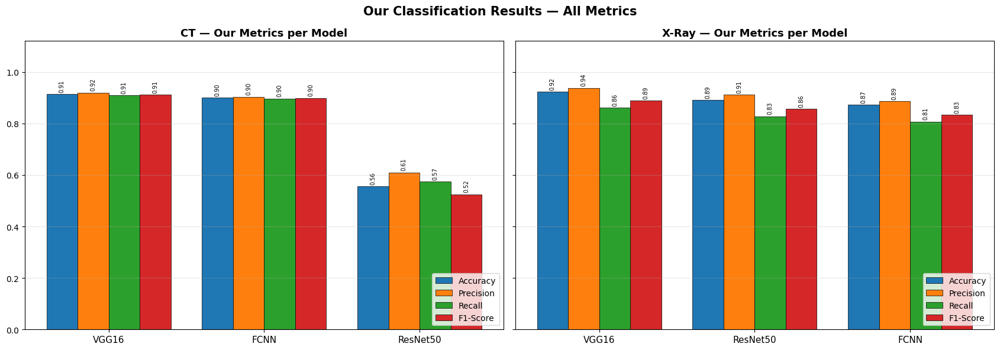

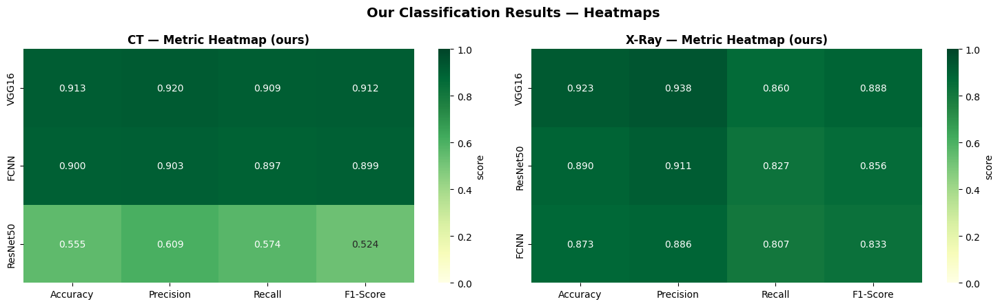

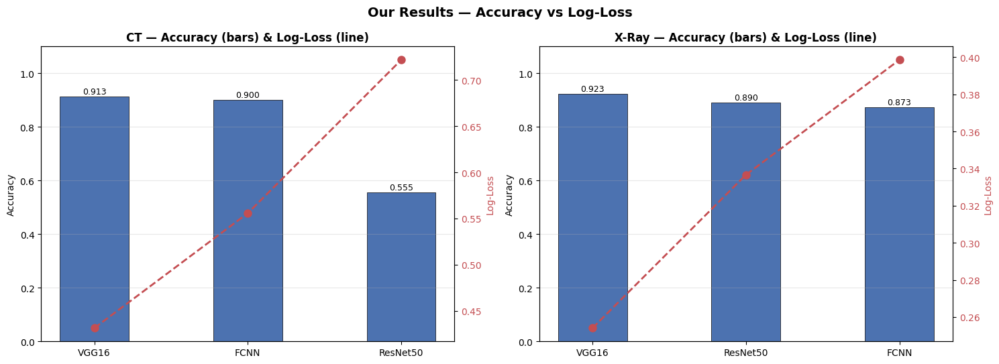

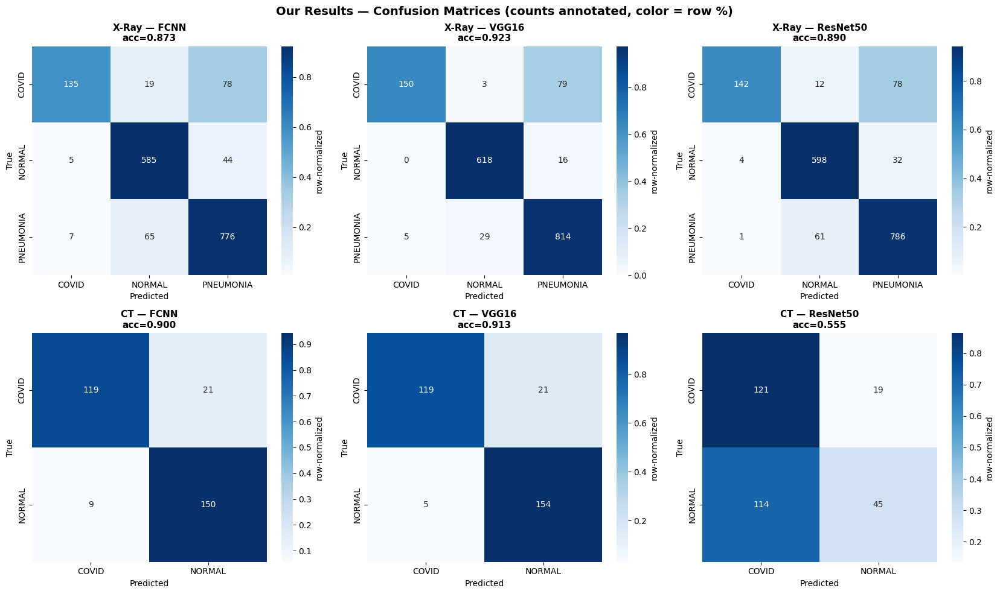

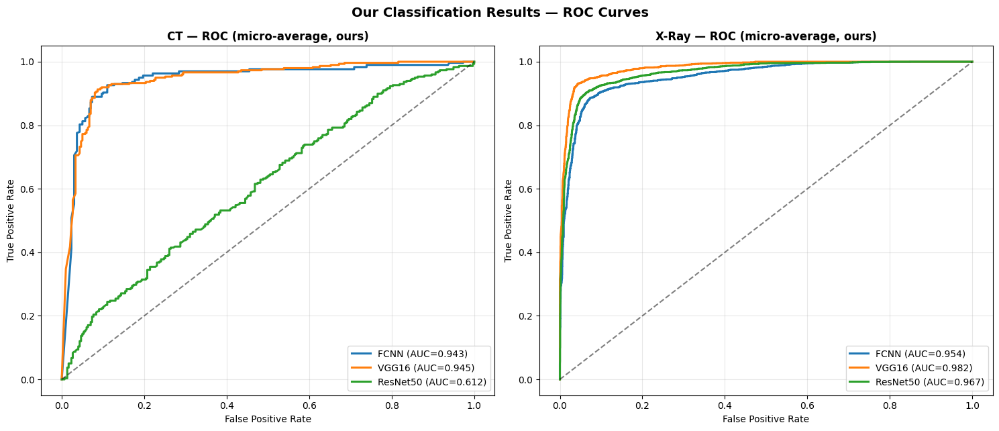

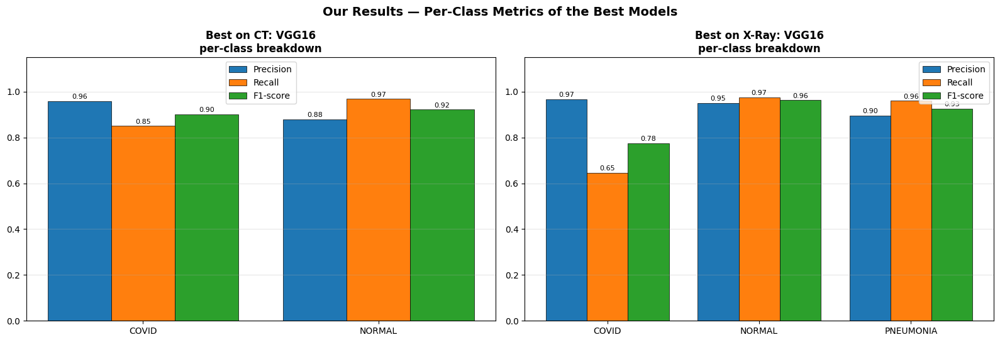

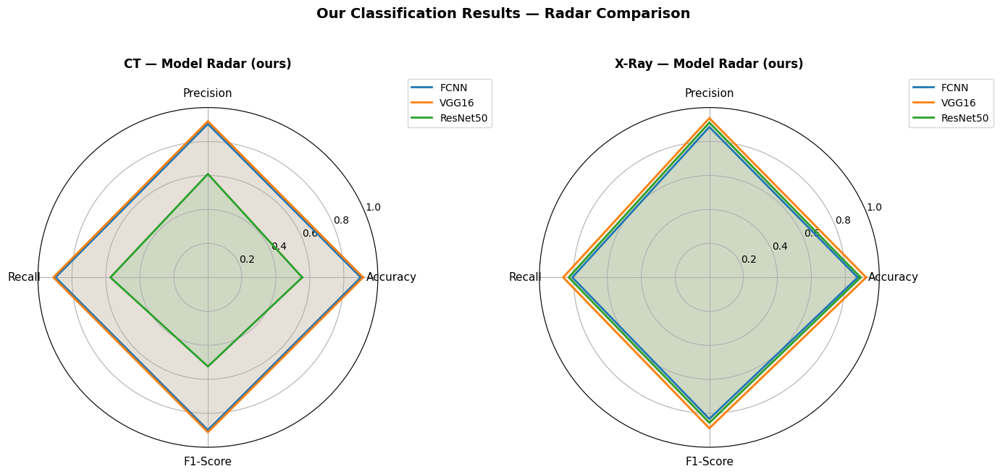


All figures saved to: C:\Users\USER\Desktop\DIP_PROJECT\results\figures
step14 done (OUR results only)


In [21]:
#---------------------------------------------------Kasra Attar Kashani----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 14  ----------------------------------------------------------------------------------------
# ============================================================
# CELL 16 — Final summary of OUR classification results
# (absolutely no paper numbers — everything below is ours)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize

HAVE_PREDICTIONS = ('results' in dir()) and results is not None and len(results) > 0

# ---------- rebuild the metrics table ----------
if HAVE_PREDICTIONS:
    res_df = pd.DataFrame([{k: v for k, v in r.items()
                            if k not in ['y_true', 'y_pred', 'y_prob', 'classes']}
                           for r in results])
    print("[loaded] results from memory (full predictions available — all charts enabled)")
else:
    res_df = pd.read_csv(RESULTS_DIR / 'table3_reproduction.csv')
    print("[loaded] results/table3_reproduction.csv "
          "(metrics only — per-class charts need `results` in memory; rerun after Step 12)")

res_df = res_df.sort_values(['modality', 'accuracy'],
                            ascending=[True, False]).reset_index(drop=True)
res_df.to_csv(RESULTS_DIR / 'final_summary_ours.csv', index=False)

METRICS   = ['accuracy', 'precision', 'recall', 'f1']
M_LABELS  = {'accuracy': 'Accuracy', 'precision': 'Precision',
             'recall': 'Recall', 'f1': 'F1-Score'}
MOD_LABELS = {'xray': 'X-Ray', 'ct': 'CT'}
PALETTE   = plt.cm.tab10.colors

# ============================================================
# OUTPUT 1 — HEADLINE SUMMARY TABLE (ours)
# ============================================================
show = res_df[['modality', 'model', 'split', 'accuracy',
               'precision', 'recall', 'f1', 'log_loss']].copy()
for c in ['accuracy', 'precision', 'recall', 'f1', 'log_loss']:
    show[c] = show[c].round(4)

print("\n" + "═"*88)
print("              OUR CLASSIFICATION RESULTS — FINAL SUMMARY (Step 12)              ")
print("═"*88)
print(show.to_string(index=False))
print("═"*88)
for mod in sorted(res_df.modality.unique()):
    sub = res_df[res_df.modality == mod]
    best = sub.loc[sub.accuracy.idxmax()]
    print(f"  🏆 Best on {MOD_LABELS.get(mod, mod)}: {best.model}  "
          f"(acc={best.accuracy:.4f}, f1={best.f1:.4f})")
print("═"*88 + "\n")

# ============================================================
# CHART 1 — Grouped metric bars per modality (acc/prec/rec/f1)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(17, 6), sharey=True)
for ax, mod in zip(axes, sorted(res_df.modality.unique())):
    sub = res_df[res_df.modality == mod]
    x = np.arange(len(sub)); w = 0.2
    for k, m in enumerate(METRICS):
        bars = ax.bar(x + (k - 1.5) * w, sub[m], w, label=M_LABELS[m],
                      color=PALETTE[k], edgecolor='black', linewidth=0.5)
        for b, v in zip(bars, sub[m]):
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.008,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7, rotation=90)
    ax.set_xticks(x); ax.set_xticklabels(sub['model'], fontsize=11)
    ax.set_title(f'{MOD_LABELS.get(mod, mod)} — Our Metrics per Model',
                 fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='lower right')
fig.suptitle('Our Classification Results — All Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'ours_metrics_grouped_bars.png', dpi=150)
plt.show()

# ============================================================
# CHART 2 — Heatmaps: model × metric per modality
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, mod in zip(axes, sorted(res_df.modality.unique())):
    piv = res_df[res_df.modality == mod].set_index('model')[METRICS]
    piv.columns = [M_LABELS[m] for m in piv.columns]
    sns.heatmap(piv, annot=True, fmt='.3f', cmap='YlGn',
                vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'score'})
    ax.set_title(f'{MOD_LABELS.get(mod, mod)} — Metric Heatmap (ours)',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('')
fig.suptitle('Our Classification Results — Heatmaps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'ours_metrics_heatmaps.png', dpi=150)
plt.show()

# ============================================================
# CHART 3 — Accuracy + Log-Loss dual view per modality
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, mod in zip(axes, sorted(res_df.modality.unique())):
    sub = res_df[res_df.modality == mod]
    x = np.arange(len(sub))
    b1 = ax.bar(x, sub['accuracy'], 0.45, color='#4C72B0',
                edgecolor='black', linewidth=0.5, label='Accuracy')
    for b, v in zip(b1, sub['accuracy']):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(sub['model'])
    ax.set_ylim(0, 1.1); ax.set_ylabel('Accuracy')
    ax.set_title(f'{MOD_LABELS.get(mod, mod)} — Accuracy (bars) & Log-Loss (line)',
                 fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax2 = ax.twinx()
    ax2.plot(x, sub['log_loss'], 'o--', color='#C44E52', linewidth=2,
             markersize=8, label='Log-Loss')
    ax2.set_ylabel('Log-Loss', color='#C44E52')
    ax2.tick_params(axis='y', labelcolor='#C44E52')
plt.suptitle('Our Results — Accuracy vs Log-Loss', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'ours_acc_logloss.png', dpi=150)
plt.show()

# ---------- charts below need full predictions (run right after Step 12) ----------
if not HAVE_PREDICTIONS:
    print("\n[info] Confusion matrices, ROC curves, per-class and radar charts "
          "require the `results` list in memory — re-run this cell right after Step 12.")
else:
    # ============================================================
    # CHART 4 — Confusion-matrix grid (all model × modality combos)
    # ============================================================
    n = len(results)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 5 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, r in zip(axes, results):
        y_true = np.array(r['y_true']); y_pred = np.array(r['y_pred'])
        classes = r['classes']
        cm = confusion_matrix(y_true, y_pred)
        cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        sns.heatmap(cm_n, annot=cm, fmt='d', cmap='Blues',
                    xticklabels=classes, yticklabels=classes, ax=ax,
                    cbar_kws={'label': 'row-normalized'})
        ax.set_title(f"{MOD_LABELS.get(r['modality'], r['modality'])} — {r['model']}\n"
                     f"acc={r['accuracy']:.3f}", fontsize=11, fontweight='bold')
        ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle('Our Results — Confusion Matrices (counts annotated, color = row %)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGS_DIR / 'ours_confusion_grid.png', dpi=150)
    plt.show()

    # ============================================================
    # CHART 5 — Combined micro-average ROC curves per modality
    # ============================================================
    modalities = sorted({r['modality'] for r in results})
    fig, axes = plt.subplots(1, len(modalities), figsize=(7.5 * len(modalities), 6.5))
    axes = np.atleast_1d(axes)
    for ax, mod in zip(axes, modalities):
        for k, r in enumerate([r for r in results if r['modality'] == mod]):
            y_true = np.array(r['y_true']); y_prob = np.array(r['y_prob'])
            classes = r['classes']
            y_bin = label_binarize(y_true, classes=list(range(len(classes))))
            if len(classes) == 2:
                y_bin = np.hstack([1 - y_bin, y_bin])
            fpr, tpr, _ = roc_curve(y_bin.ravel(), y_prob.ravel())
            ax.plot(fpr, tpr, linewidth=2.2, color=PALETTE[k],
                    label=f"{r['model']} (AUC={auc(fpr, tpr):.3f})")
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax.set_title(f'{MOD_LABELS.get(mod, mod)} — ROC (micro-average, ours)',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
        ax.grid(alpha=0.3); ax.legend(loc='lower right')
    fig.suptitle('Our Classification Results — ROC Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGS_DIR / 'ours_roc_combined.png', dpi=150)
    plt.show()

    # ============================================================
    # CHART 6 — Per-class P/R/F1 for the BEST model of each modality
    # ============================================================
    best_per_mod = []
    for mod in modalities:
        cand = [r for r in results if r['modality'] == mod]
        best_per_mod.append(max(cand, key=lambda r: r['accuracy']))

    fig, axes = plt.subplots(1, len(best_per_mod), figsize=(8 * len(best_per_mod), 5.5))
    axes = np.atleast_1d(axes)
    for ax, r in zip(axes, best_per_mod):
        rep = classification_report(np.array(r['y_true']), np.array(r['y_pred']),
                                    target_names=r['classes'], output_dict=True,
                                    zero_division=0)
        per_cls = pd.DataFrame(rep).T.loc[r['classes'],
                                          ['precision', 'recall', 'f1-score']]
        x = np.arange(len(per_cls)); w = 0.27
        for k, m in enumerate(['precision', 'recall', 'f1-score']):
            bars = ax.bar(x + (k - 1) * w, per_cls[m], w, label=m.capitalize(),
                          color=PALETTE[k], edgecolor='black', linewidth=0.5)
            for b, v in zip(bars, per_cls[m]):
                ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                        f'{v:.2f}', ha='center', fontsize=8)
        ax.set_xticks(x); ax.set_xticklabels(per_cls.index)
        ax.set_ylim(0, 1.15); ax.grid(axis='y', alpha=0.3); ax.legend()
        ax.set_title(f"Best on {MOD_LABELS.get(r['modality'], r['modality'])}: {r['model']}\n"
                     f"per-class breakdown", fontsize=12, fontweight='bold')
    fig.suptitle('Our Results — Per-Class Metrics of the Best Models',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGS_DIR / 'ours_per_class_best.png', dpi=150)
    plt.show()

    # ============================================================
    # CHART 7 — Radar chart: 4 metrics per model, one panel per modality
    # ============================================================
    angles = np.linspace(0, 2 * np.pi, len(METRICS), endpoint=False).tolist()
    angles += angles[:1]
    fig, axes = plt.subplots(1, len(modalities),
                             figsize=(7 * len(modalities), 7),
                             subplot_kw=dict(polar=True))
    axes = np.atleast_1d(axes)
    for ax, mod in zip(axes, modalities):
        for k, r in enumerate([r for r in results if r['modality'] == mod]):
            vals = [r[m] for m in METRICS] + [r[METRICS[0]]]
            ax.plot(angles, vals, linewidth=2, color=PALETTE[k], label=r['model'])
            ax.fill(angles, vals, alpha=0.12, color=PALETTE[k])
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([M_LABELS[m] for m in METRICS], fontsize=11)
        ax.set_ylim(0, 1)
        ax.set_title(f'{MOD_LABELS.get(mod, mod)} — Model Radar (ours)',
                     fontsize=12, fontweight='bold', pad=20)
        ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
    fig.suptitle('Our Classification Results — Radar Comparison',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGS_DIR / 'ours_radar.png', dpi=150)
    plt.show()

print("\nAll figures saved to:", FIGS_DIR)
print("step14 done ")


[hist] loaded 1 AE histories, 11 classifier histories
[A] AE results from memory


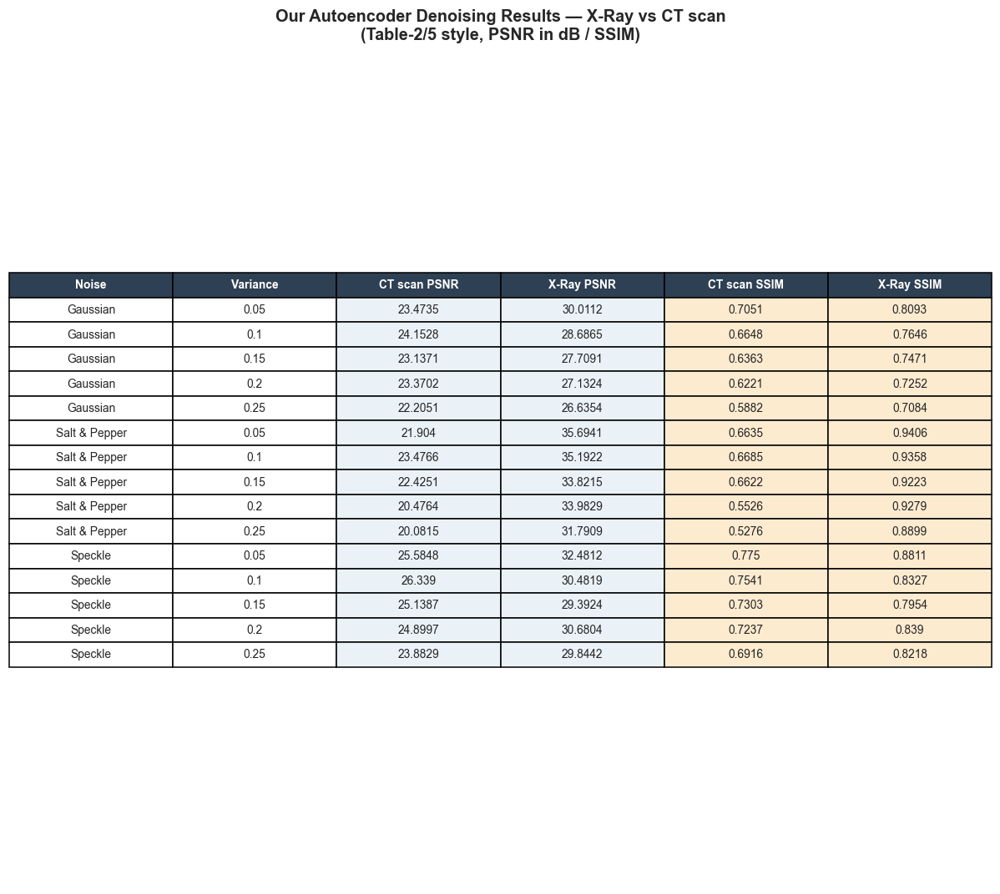

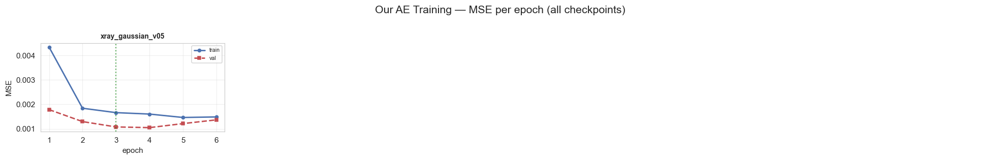

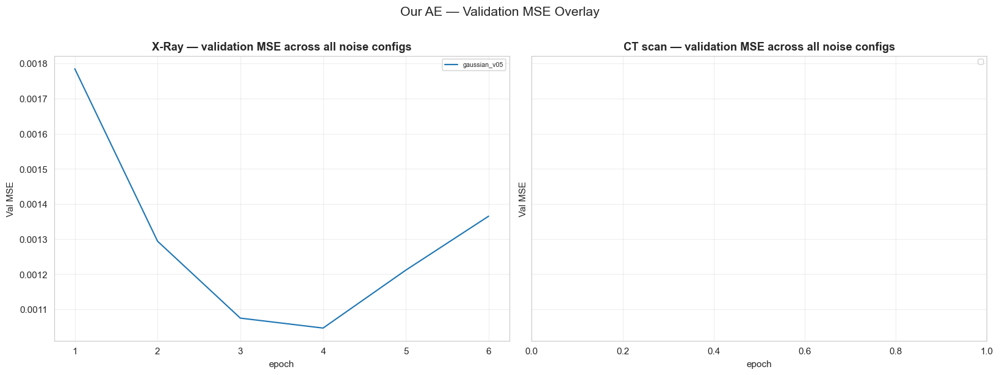

[B] Classifier predictions from memory


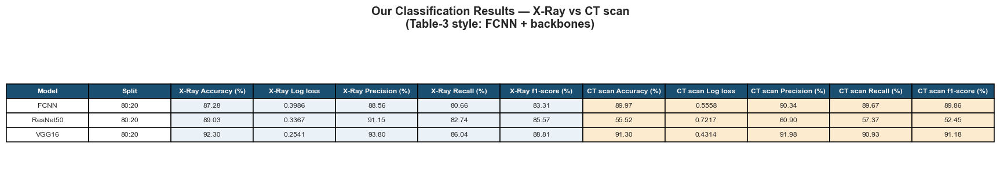

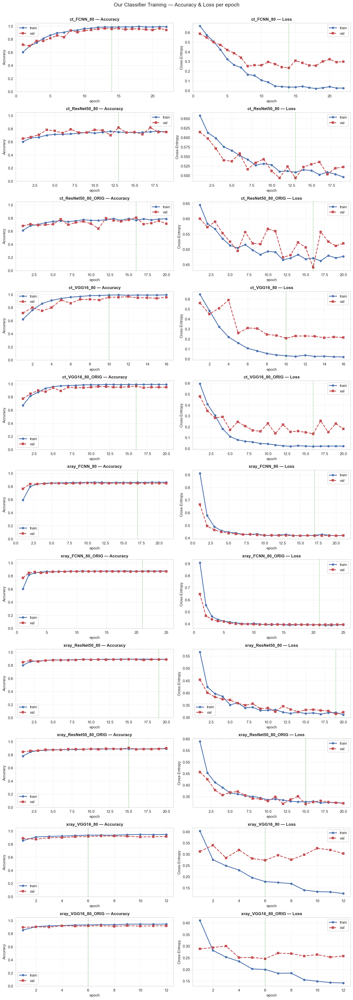

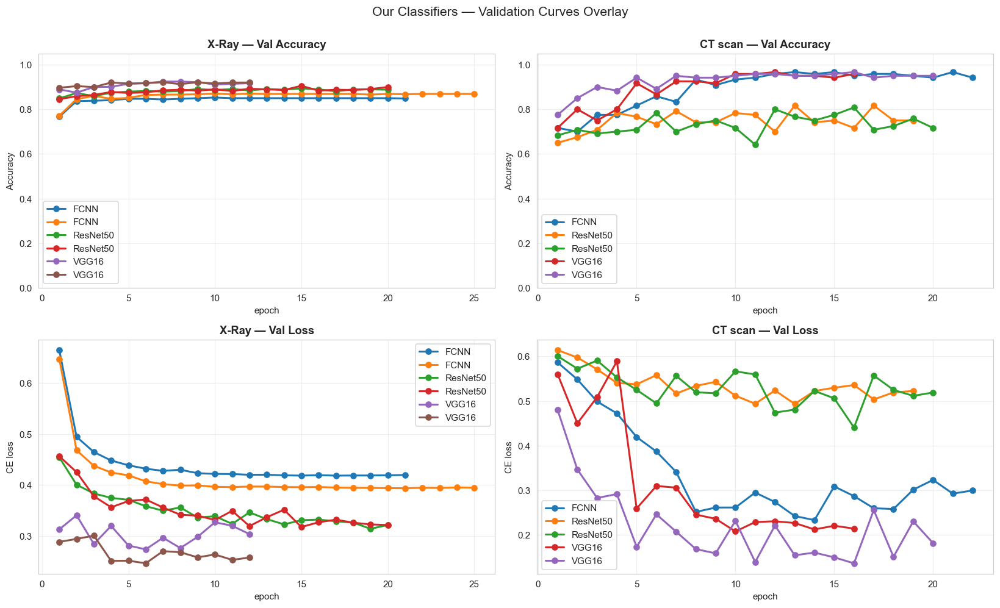

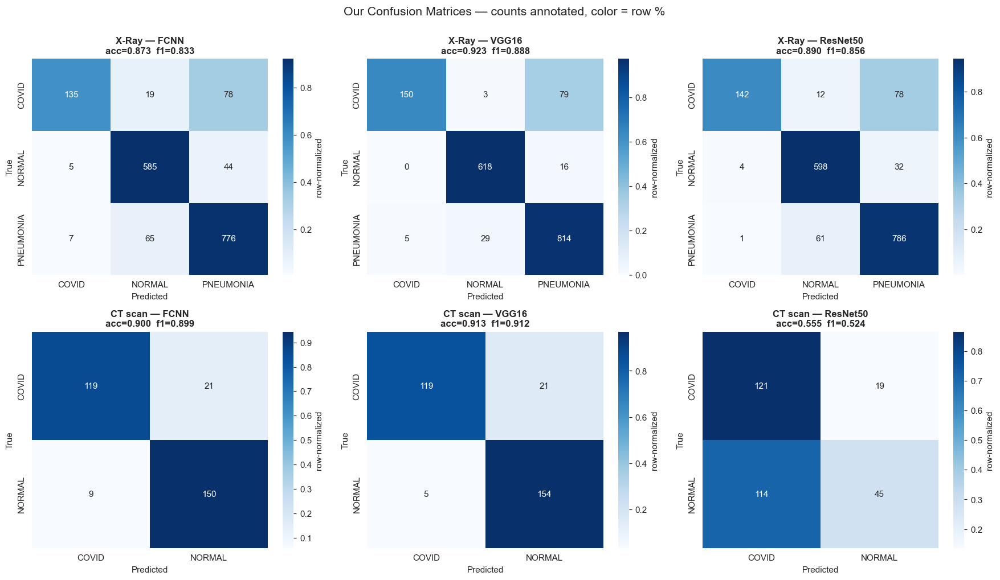

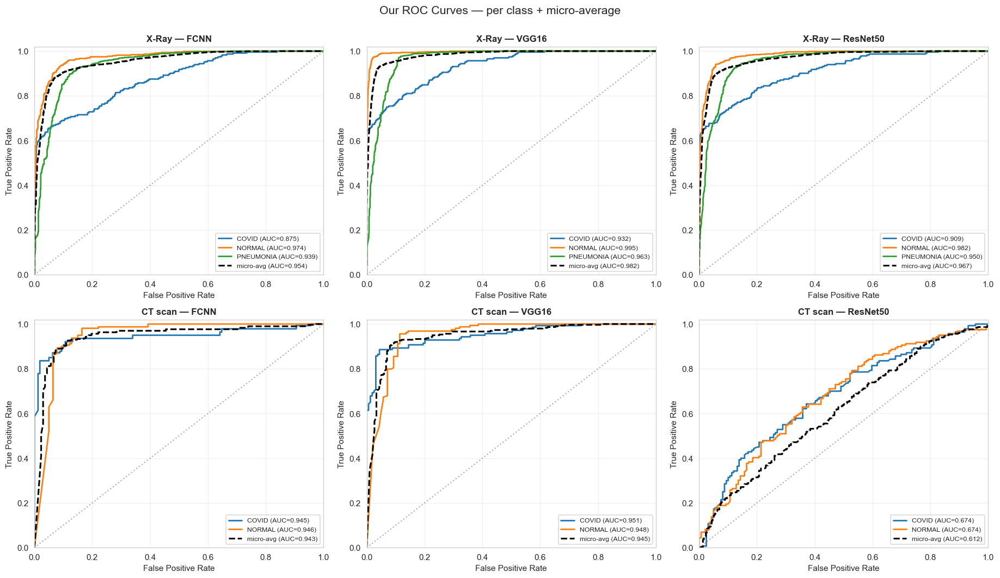

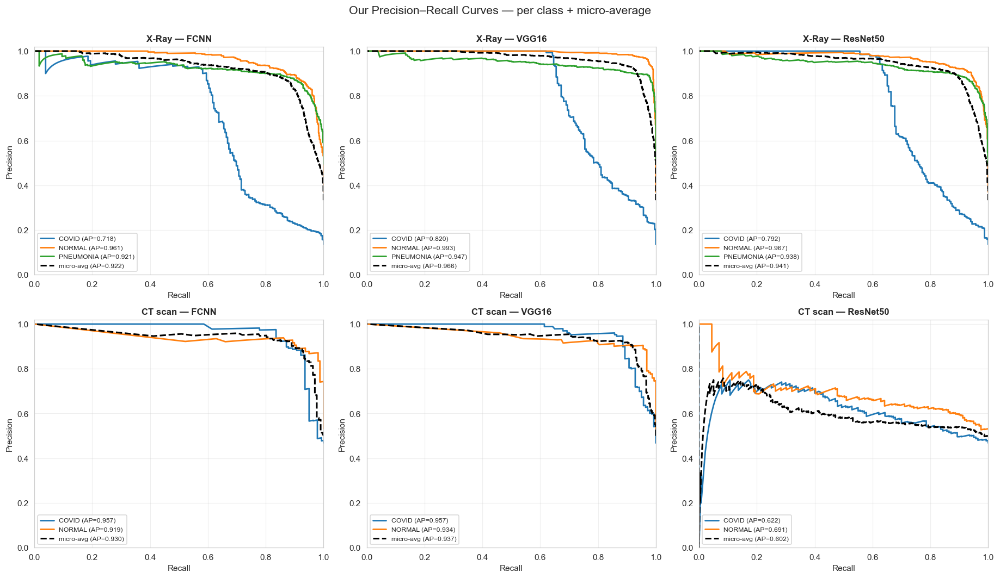

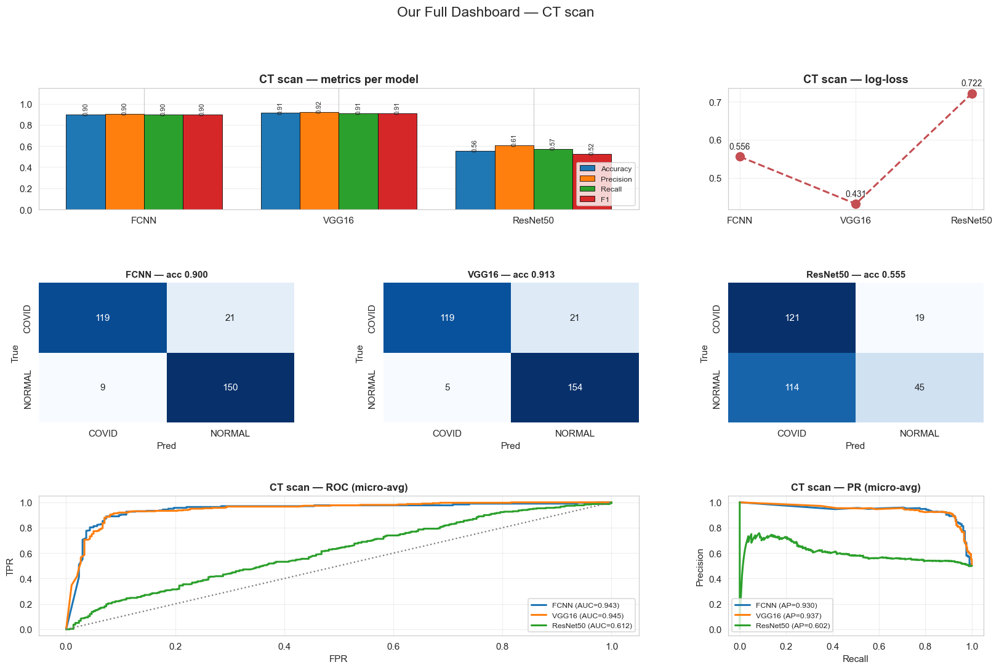

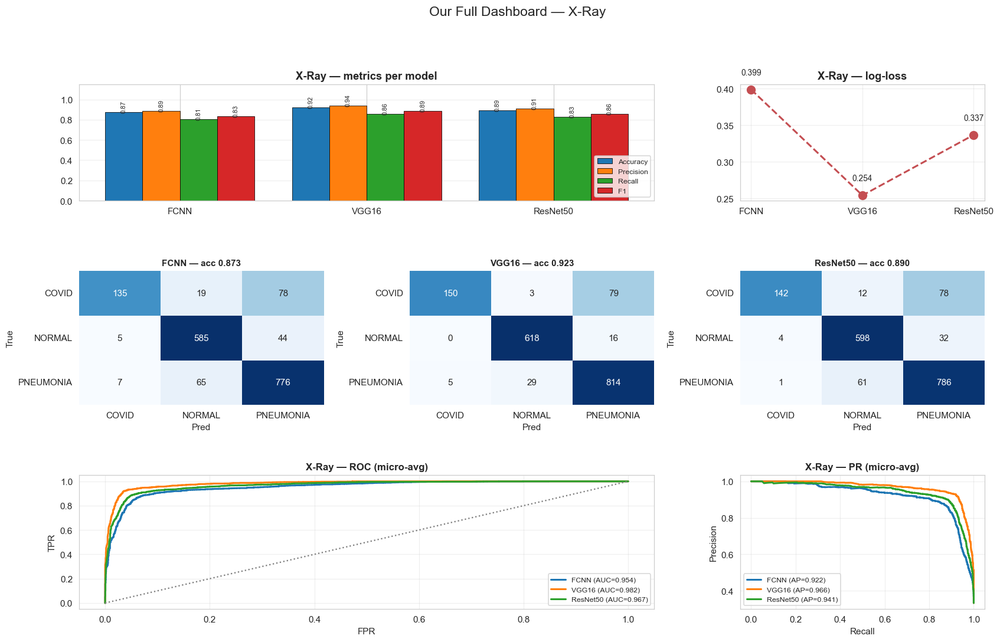

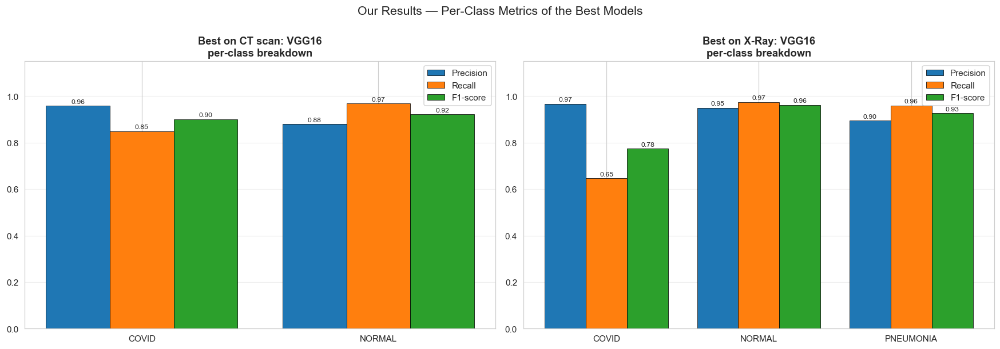


════════════════════════════════════════════════════════════════════════════════
Step 15 done — all figures saved to: C:\Users\USER\Desktop\DIP_PROJECT\results\figures\step15_article_style
════════════════════════════════════════════════════════════════════════════════
Step15 done


In [22]:
#---------------------------------------------------Kasra Attar Kashani----------------------------
#-------------------------Digital Image Processing -------------------------------------PROJECT-------------
#----------STEP 15 — ARTICLE-STYLE (TABLE 2 / TABLE 3) VISUALIZATIONS -------------------------------------
# ============================================================
# CELL — Article-style figures & tables for OUR Step 7 + Step 12
# All OURS, no paper numbers. Reads from models/history/*.json
# ============================================================
import os, re, json, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score,
                             classification_report)
from sklearn.preprocessing import label_binarize

sns.set_style("whitegrid")
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.dpi']       = 110

# ------------------------------------------------------------------
# 0. Paths / config
# ------------------------------------------------------------------
FIG_OUT  = FIGS_DIR / "step15_article_style"
FIG_OUT.mkdir(parents=True, exist_ok=True)
HIST_DIR = MODELS_DIR / "history"

NOISE_LABELS = {'gaussian': 'Gaussian', 'salt_pepper': 'Salt & Pepper',
                'speckle':  'Speckle'}
MOD_LABELS   = {'xray': 'X-Ray', 'ct': 'CT scan'}
PALETTE      = plt.cm.tab10.colors

# ==================================================================
# Helpers to load histories
# ==================================================================
def load_ae_histories():
    out = {}
    if not HIST_DIR.exists(): return out
    for jf in sorted(HIST_DIR.glob("ae_*.json")):
        if jf.name == "ae_summary.json": continue
        try:
            out[jf.stem.replace('ae_', '')] = json.loads(jf.read_text())
        except Exception as e:
            print(f"  [warn] could not parse {jf.name}: {e}")
    return out

def load_cls_histories():
    out = {}
    if not HIST_DIR.exists(): return out
    for jf in sorted(HIST_DIR.glob("cls_*.json")):
        try:
            out[jf.stem.replace('cls_', '')] = json.loads(jf.read_text())
        except Exception as e:
            print(f"  [warn] could not parse {jf.name}: {e}")
    return out

ae_hist  = load_ae_histories()
cls_hist = load_cls_histories()
print(f"[hist] loaded {len(ae_hist)} AE histories, {len(cls_hist)} classifier histories")

# ==================================================================
# A. TABLE-2-STYLE AUTOENCODER RESULTS TABLE (X-ray | CT side-by-side)
#    Rows = (noise × variance), columns = X-Ray PSNR/SSIM | CT PSNR/SSIM
# ==================================================================
ae_csv = RESULTS_DIR / 'ae_table5.csv'
ae_df_local = None
if 'ae_df' in globals() and ae_df is not None and len(ae_df):
    ae_df_local = ae_df.copy()
    print("[A] AE results from memory")
elif ae_csv.exists():
    ae_df_local = pd.read_csv(ae_csv)
    print(f"[A] AE results from {ae_csv.name}")

if ae_df_local is not None and len(ae_df_local):
    ae_df_local['variance'] = ae_df_local['variance'].round(2)
    piv = ae_df_local.pivot_table(index=['noise', 'variance'],
                                  columns='modality', values=['PSNR', 'SSIM'])
    piv = piv.reindex(['gaussian', 'salt_pepper', 'speckle'], level=0)
    new_cols = [f"{MOD_LABELS.get(mod, mod)} {metric}" for metric, mod in piv.columns]
    piv.columns = new_cols
    piv = piv.reset_index()
    piv['noise'] = piv['noise'].map(NOISE_LABELS)
    piv = piv.rename(columns={'noise': 'Noise', 'variance': 'Variance'})
    piv.to_csv(RESULTS_DIR / 'step15_ae_table.csv', index=False)

    cell_text = [[round(c, 4) if isinstance(c, (int, float, np.floating)) else c
                  for c in row] for row in piv.values]
    fig, ax = plt.subplots(figsize=(11, 0.55 * len(piv) + 1.6))
    ax.axis('off')
    ax.set_title("Our Autoencoder Denoising Results — X-Ray vs CT scan\n"
                 "(Table-2/5 style, PSNR in dB / SSIM)", fontsize=13, pad=12)
    tbl = ax.table(cellText=cell_text, colLabels=piv.columns,
                   loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.35)
    for j in range(len(piv.columns)):
        tbl[(0, j)].set_facecolor('#2E4053')
        tbl[(0, j)].set_text_props(color='white', weight='bold')
    for i in range(1, len(piv) + 1):
        for j in range(2, 4):
            tbl[(i, j)].set_facecolor('#EAF2F8')
        for j in range(4, 6):
            tbl[(i, j)].set_facecolor('#FDEBD0')
    plt.tight_layout()
    plt.savefig(FIG_OUT / 'A_ae_table.png', dpi=170, bbox_inches='tight')
    plt.show()
else:
    print("[A] No AE results yet — run Step 7.")

# ==================================================================
# D. AE TRAINING CURVES (MSE per epoch, all 30 checkpoints)
# ==================================================================
if ae_hist:
    n = len(ae_hist); ncol = 5; nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 2.8 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, (tag, h) in zip(axes, sorted(ae_hist.items())):
        eps = h.get('epochs') or list(range(1, len(h.get('train_mse', [])) + 1))
        if h.get('train_mse'):
            ax.plot(eps, h['train_mse'], 'o-', label='train',
                    color='#4C72B0', linewidth=1.8, markersize=4)
        if h.get('val_mse'):
            ax.plot(eps, h['val_mse'], 's--', label='val',
                    color='#C44E52', linewidth=1.8, markersize=4)
        if h.get('best_epoch'):
            ax.axvline(h['best_epoch'], color='green', linestyle=':', alpha=0.6)
        ax.set_title(tag, fontsize=9)
        ax.set_xlabel('epoch'); ax.set_ylabel('MSE')
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
    for ax in axes[n:]: ax.axis('off')
    fig.suptitle('Our AE Training — MSE per epoch (all checkpoints)',
                 fontsize=14, y=1.005)
    plt.tight_layout()
    plt.savefig(FIG_OUT / 'D_ae_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    # combined per-modality overlay
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
    for ax, mod in zip(axes, ['xray', 'ct']):
        c_idx = 0
        for tag, h in sorted(ae_hist.items()):
            if not tag.startswith(mod): continue
            eps = h.get('epochs') or list(range(1, len(h.get('val_mse', [])) + 1))
            ax.plot(eps, h.get('val_mse', []), '-', color=PALETTE[c_idx % 10],
                    linewidth=1.4, label=tag.replace(f"{mod}_", ""))
            c_idx += 1
        ax.set_title(f'{MOD_LABELS[mod]} — validation MSE across all noise configs',
                     fontsize=12)
        ax.set_xlabel('epoch'); ax.set_ylabel('Val MSE')
        ax.legend(fontsize=7, ncol=2, loc='upper right')
        ax.grid(alpha=0.3)
    fig.suptitle('Our AE — Validation MSE Overlay', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(FIG_OUT / 'D2_ae_val_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("[D] No AE history JSONs yet — will appear after Step 7 (v2) runs.")

# ==================================================================
# B. TABLE-3-STYLE CLASSIFICATION RESULTS (X-ray | CT side-by-side)
# ==================================================================
have_predictions = False
results_local = None
if 'results' in globals() and results is not None and len(results):
    results_local = results
    have_predictions = True
    print("[B] Classifier predictions from memory")
else:
    # try full-results JSON
    for cand in [RESULTS_DIR / 'cls_results_full.json',
                 RESULTS_DIR / 'cls_results_full_PRESENTATION.json']:
        if cand.exists():
            with open(cand) as f:
                results_local = json.load(f)
            have_predictions = True
            print(f"[B] Classifier predictions from {cand.name}")
            break

if results_local:
    metrics_df = pd.DataFrame([{k: v for k, v in r.items()
                                if k not in ['y_true','y_pred','y_prob','classes']}
                               for r in results_local])
else:
    metrics_df = None
    for c in [RESULTS_DIR / 'table3_reproduction.csv',
              RESULTS_DIR / 'table3_reproduction_PRESENTATION.csv']:
        if c.exists():
            metrics_df = pd.read_csv(c)
            print(f"[B] Classifier metrics from {c.name} (no predictions)")
            break

if metrics_df is not None and len(metrics_df):
    METRIC_COLS = ['accuracy','log_loss','precision','recall','f1']
    HDR = {'accuracy':'Accuracy (%)', 'log_loss':'Log loss',
           'precision':'Precision (%)', 'recall':'Recall (%)',
           'f1':'f1-score (%)'}

    def _fmt(name, v):
        if pd.isna(v): return '—'
        if name in ('accuracy','precision','recall','f1'):
            return f"{v*100:.2f}"
        return f"{v:.4f}"

    rows = []
    for (model, split), grp in metrics_df.groupby(['model','split']):
        row = {'Model': model, 'Split': split}
        for mod in ['xray', 'ct']:
            sub = grp[grp.modality == mod]
            for m in METRIC_COLS:
                key = f"{MOD_LABELS[mod]} {HDR[m]}"
                row[key] = _fmt(m, sub[m].iloc[0]) if len(sub) else '—'
        rows.append(row)
    table_df = pd.DataFrame(rows)
    table_df.to_csv(RESULTS_DIR / 'step15_classification_table3.csv', index=False)

    fig_w = 1.15 * len(table_df.columns) + 2
    fig_h = 0.55 * len(table_df) + 1.5
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')
    ax.set_title("Our Classification Results — X-Ray vs CT scan\n"
                 "(Table-3 style: FCNN + backbones)", fontsize=13, pad=12)
    tbl = ax.table(cellText=table_df.values.tolist(),
                   colLabels=table_df.columns, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.4)
    ncols = len(table_df.columns)
    for j in range(ncols):
        tbl[(0, j)].set_facecolor('#1B4F72')
        tbl[(0, j)].set_text_props(color='white', weight='bold')
    for i in range(1, len(table_df) + 1):
        for j in range(2, 2 + len(METRIC_COLS)):
            tbl[(i, j)].set_facecolor('#EAF2F8')
        for j in range(2 + len(METRIC_COLS), ncols):
            tbl[(i, j)].set_facecolor('#FDEBD0')
    plt.tight_layout()
    plt.savefig(FIG_OUT / 'B_classification_table.png', dpi=170, bbox_inches='tight')
    plt.show()
else:
    print("[B] No classifier results yet — run Step 12.")

# ==================================================================
# C. CLASSIFIER TRAINING CURVES (accuracy + loss per epoch)
# ==================================================================
if cls_hist:
    n = len(cls_hist)
    fig, axes = plt.subplots(n, 2, figsize=(13, 3.3 * n))
    if n == 1: axes = axes.reshape(1, 2)
    for i, (key, h) in enumerate(sorted(cls_hist.items())):
        ax_acc, ax_loss = axes[i, 0], axes[i, 1]
        eps = h.get('epochs') or list(range(1, len(h.get('train_acc', [])) + 1))
        ax_acc.plot(eps, h.get('train_acc', []), 'o-', label='train',
                    color='#4C72B0', linewidth=2, markersize=5)
        ax_acc.plot(eps, h.get('val_acc', []), 's--', label='val',
                    color='#C44E52', linewidth=2, markersize=5)
        if h.get('best_epoch'):
            ax_acc.axvline(h['best_epoch'], color='green', linestyle=':', alpha=0.6)
        ax_acc.set_title(f'{key} — Accuracy', fontsize=11)
        ax_acc.set_xlabel('epoch'); ax_acc.set_ylabel('Accuracy')
        ax_acc.set_ylim(0, 1.05); ax_acc.grid(alpha=0.3); ax_acc.legend()

        ax_loss.plot(eps, h.get('train_loss', []), 'o-', label='train',
                     color='#4C72B0', linewidth=2, markersize=5)
        ax_loss.plot(eps, h.get('val_loss', []), 's--', label='val',
                     color='#C44E52', linewidth=2, markersize=5)
        if h.get('best_epoch'):
            ax_loss.axvline(h['best_epoch'], color='green', linestyle=':', alpha=0.6)
        ax_loss.set_title(f'{key} — Loss', fontsize=11)
        ax_loss.set_xlabel('epoch'); ax_loss.set_ylabel('Cross-Entropy')
        ax_loss.grid(alpha=0.3); ax_loss.legend()
    fig.suptitle('Our Classifier Training — Accuracy & Loss per epoch',
                 fontsize=14, y=1.002)
    plt.tight_layout()
    plt.savefig(FIG_OUT / 'C_classifier_training_curves.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # combined overlay: one plot with all models, colored by model
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    for col, mod in enumerate(['xray', 'ct']):
        keys = [k for k in cls_hist if k.startswith(mod)]
        for k_idx, key in enumerate(sorted(keys)):
            h = cls_hist[key]
            eps = h.get('epochs') or list(range(1, len(h.get('val_acc', [])) + 1))
            axes[0, col].plot(eps, h.get('val_acc', []), 'o-',
                              color=PALETTE[k_idx], linewidth=2,
                              label=h.get('model', key))
            axes[1, col].plot(eps, h.get('val_loss', []), 'o-',
                              color=PALETTE[k_idx], linewidth=2,
                              label=h.get('model', key))
        axes[0, col].set_title(f'{MOD_LABELS[mod]} — Val Accuracy', fontsize=12)
        axes[0, col].set_xlabel('epoch'); axes[0, col].set_ylabel('Accuracy')
        axes[0, col].set_ylim(0, 1.05); axes[0, col].grid(alpha=0.3); axes[0, col].legend()
        axes[1, col].set_title(f'{MOD_LABELS[mod]} — Val Loss', fontsize=12)
        axes[1, col].set_xlabel('epoch'); axes[1, col].set_ylabel('CE loss')
        axes[1, col].grid(alpha=0.3); axes[1, col].legend()
    fig.suptitle('Our Classifiers — Validation Curves Overlay',
                 fontsize=14, y=1.002)
    plt.tight_layout()
    plt.savefig(FIG_OUT / 'C2_classifier_overlay.png',
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("[C] No classifier history JSONs yet — will appear after Step 12 (v2) runs.")

# ==================================================================
# E. CONFUSION MATRICES (per model × modality) — needs predictions
# ==================================================================
if have_predictions:
    n = len(results_local); ncol = 3; nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.4 * ncol, 4.6 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, r in zip(axes, results_local):
        y_true = np.array(r['y_true']); y_pred = np.array(r['y_pred'])
        cm = confusion_matrix(y_true, y_pred)
        cm_n = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
        sns.heatmap(cm_n, annot=cm, fmt='d', cmap='Blues',
                    xticklabels=r['classes'], yticklabels=r['classes'],
                    ax=ax, cbar_kws={'label': 'row-normalized'})
        ax.set_title(f"{MOD_LABELS.get(r['modality'], r['modality'])} — {r['model']}\n"
                     f"acc={r['accuracy']:.3f}  f1={r['f1']:.3f}", fontsize=11)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for ax in axes[n:]: ax.axis('off')
    fig.suptitle('Our Confusion Matrices — counts annotated, color = row %',
                 fontsize=14, y=1.002)
    plt.tight_layout()
    plt.savefig(FIG_OUT / 'E_confusion_matrices.png',
                dpi=150, bbox_inches='tight')
    plt.show()

# ==================================================================
# F. ROC CURVES — per class + micro-avg
# ==================================================================
if have_predictions:
    n = len(results_local); ncol = 3; nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.6 * ncol, 4.8 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, r in zip(axes, results_local):
        y_true = np.array(r['y_true']); y_prob = np.array(r['y_prob'])
        classes = r['classes']; K = len(classes)
        y_bin = label_binarize(y_true, classes=list(range(K)))
        if K == 2: y_bin = np.hstack([1 - y_bin, y_bin])
        for k in range(K):
            fpr, tpr, _ = roc_curve(y_bin[:, k], y_prob[:, k])
            ax.plot(fpr, tpr, linewidth=1.8, color=PALETTE[k],
                    label=f"{classes[k]} (AUC={auc(fpr, tpr):.3f})")
        fpr_mi, tpr_mi, _ = roc_curve(y_bin.ravel(), y_prob.ravel())
        ax.plot(fpr_mi, tpr_mi, '--', linewidth=2, color='black',
                label=f"micro-avg (AUC={auc(fpr_mi, tpr_mi):.3f})")
        ax.plot([0, 1], [0, 1], ':', color='gray', alpha=0.6)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
        ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
        ax.set_title(f"{MOD_LABELS.get(r['modality'], r['modality'])} — {r['model']}",
                     fontsize=11)
        ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)
    for ax in axes[n:]: ax.axis('off')
    fig.suptitle('Our ROC Curves — per class + micro-average',
                 fontsize=14, y=1.002)
    plt.tight_layout()
    plt.savefig(FIG_OUT / 'F_roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

# ==================================================================
# G. PRECISION–RECALL CURVES — per class + micro-avg
# ==================================================================
if have_predictions:
    n = len(results_local); ncol = 3; nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.6 * ncol, 4.8 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, r in zip(axes, results_local):
        y_true = np.array(r['y_true']); y_prob = np.array(r['y_prob'])
        classes = r['classes']; K = len(classes)
        y_bin = label_binarize(y_true, classes=list(range(K)))
        if K == 2: y_bin = np.hstack([1 - y_bin, y_bin])
        for k in range(K):
            prec, rec, _ = precision_recall_curve(y_bin[:, k], y_prob[:, k])
            ap = average_precision_score(y_bin[:, k], y_prob[:, k])
            ax.plot(rec, prec, linewidth=1.8, color=PALETTE[k],
                    label=f"{classes[k]} (AP={ap:.3f})")
        prec_mi, rec_mi, _ = precision_recall_curve(y_bin.ravel(), y_prob.ravel())
        ap_mi = average_precision_score(y_bin, y_prob, average='micro')
        ax.plot(rec_mi, prec_mi, '--', linewidth=2, color='black',
                label=f"micro-avg (AP={ap_mi:.3f})")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
        ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
        ax.set_title(f"{MOD_LABELS.get(r['modality'], r['modality'])} — {r['model']}",
                     fontsize=11)
        ax.legend(loc='lower left', fontsize=8); ax.grid(alpha=0.3)
    for ax in axes[n:]: ax.axis('off')
    fig.suptitle('Our Precision–Recall Curves — per class + micro-average',
                 fontsize=14, y=1.002)
    plt.tight_layout()
    plt.savefig(FIG_OUT / 'G_pr_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

# ==================================================================
# H. COMBINED DASHBOARD PER MODALITY
# ==================================================================
if have_predictions:
    for mod in sorted({r['modality'] for r in results_local}):
        sub = [r for r in results_local if r['modality'] == mod]
        nmods = len(sub)
        fig = plt.figure(figsize=(18, 6 + 4.5 * ((nmods + 2) // 3)))
        gs = gridspec.GridSpec(3, max(3, nmods),
                               height_ratios=[1.0, 1.15, 1.15],
                               hspace=0.55, wspace=0.35)

        ax0 = fig.add_subplot(gs[0, :max(2, nmods // 2)])
        x = np.arange(nmods); w = 0.2
        for k, m in enumerate(['accuracy','precision','recall','f1']):
            vals = [r[m] for r in sub]
            b = ax0.bar(x + (k - 1.5) * w, vals, w, color=PALETTE[k],
                        edgecolor='black', linewidth=0.5, label=m.capitalize())
            for bar, v in zip(b, vals):
                ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                         f'{v:.2f}', ha='center', fontsize=7, rotation=90)
        ax0.set_xticks(x); ax0.set_xticklabels([r['model'] for r in sub])
        ax0.set_ylim(0, 1.15); ax0.grid(axis='y', alpha=0.3)
        ax0.set_title(f'{MOD_LABELS.get(mod, mod)} — metrics per model', fontsize=12)
        ax0.legend(loc='lower right', fontsize=8)

        ax1 = fig.add_subplot(gs[0, max(2, nmods // 2):])
        ax1.plot(x, [r['log_loss'] for r in sub], 'o--', color='#C44E52',
                 linewidth=2, markersize=9)
        for xi, r in zip(x, sub):
            ax1.text(xi, r['log_loss'] + 0.02, f"{r['log_loss']:.3f}",
                     ha='center', fontsize=9)
        ax1.set_xticks(x); ax1.set_xticklabels([r['model'] for r in sub])
        ax1.set_title(f'{MOD_LABELS.get(mod, mod)} — log-loss', fontsize=12)
        ax1.grid(alpha=0.3)

        for i, r in enumerate(sub):
            axc = fig.add_subplot(gs[1, i])
            cm = confusion_matrix(r['y_true'], r['y_pred'])
            cm_n = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
            sns.heatmap(cm_n, annot=cm, fmt='d', cmap='Blues',
                        xticklabels=r['classes'], yticklabels=r['classes'],
                        ax=axc, cbar=False)
            axc.set_title(f"{r['model']} — acc {r['accuracy']:.3f}", fontsize=10)
            axc.set_xlabel('Pred'); axc.set_ylabel('True')

        axr = fig.add_subplot(gs[2, :max(1, nmods // 2 + 1)])
        axp = fig.add_subplot(gs[2, max(1, nmods // 2 + 1):])
        for k, r in enumerate(sub):
            y_bin = label_binarize(r['y_true'], classes=list(range(len(r['classes']))))
            if len(r['classes']) == 2: y_bin = np.hstack([1 - y_bin, y_bin])
            y_prob = np.array(r['y_prob'])
            fpr, tpr, _ = roc_curve(y_bin.ravel(), y_prob.ravel())
            axr.plot(fpr, tpr, linewidth=2, color=PALETTE[k],
                     label=f"{r['model']} (AUC={auc(fpr, tpr):.3f})")
            prec, rec, _ = precision_recall_curve(y_bin.ravel(), y_prob.ravel())
            ap = average_precision_score(y_bin, y_prob, average='micro')
            axp.plot(rec, prec, linewidth=2, color=PALETTE[k],
                     label=f"{r['model']} (AP={ap:.3f})")
        axr.plot([0, 1], [0, 1], ':', color='gray')
        axr.set_xlabel('FPR'); axr.set_ylabel('TPR')
        axr.set_title(f'{MOD_LABELS.get(mod, mod)} — ROC (micro-avg)', fontsize=11)
        axr.legend(loc='lower right', fontsize=8); axr.grid(alpha=0.3)
        axp.set_xlabel('Recall'); axp.set_ylabel('Precision')
        axp.set_title(f'{MOD_LABELS.get(mod, mod)} — PR (micro-avg)', fontsize=11)
        axp.legend(loc='lower left', fontsize=8); axp.grid(alpha=0.3)

        fig.suptitle(f'Our Full Dashboard — {MOD_LABELS.get(mod, mod)}',
                     fontsize=15, y=0.995)
        plt.savefig(FIG_OUT / f'H_dashboard_{mod}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

# ==================================================================
# I. Per-class breakdown for the BEST model per modality
# ==================================================================
if have_predictions:
    modalities = sorted({r['modality'] for r in results_local})
    best_per_mod = []
    for mod in modalities:
        cand = [r for r in results_local if r['modality'] == mod]
        best_per_mod.append(max(cand, key=lambda r: r['accuracy']))

    fig, axes = plt.subplots(1, len(best_per_mod),
                             figsize=(8 * len(best_per_mod), 5.5))
    axes = np.atleast_1d(axes)
    for ax, r in zip(axes, best_per_mod):
        rep = classification_report(np.array(r['y_true']), np.array(r['y_pred']),
                                    target_names=r['classes'], output_dict=True,
                                    zero_division=0)
        per_cls = pd.DataFrame(rep).T.loc[r['classes'],
                                          ['precision', 'recall', 'f1-score']]
        x = np.arange(len(per_cls)); w = 0.27
        for k, m in enumerate(['precision', 'recall', 'f1-score']):
            bars = ax.bar(x + (k - 1) * w, per_cls[m], w, label=m.capitalize(),
                          color=PALETTE[k], edgecolor='black', linewidth=0.5)
            for b, v in zip(bars, per_cls[m]):
                ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                        f'{v:.2f}', ha='center', fontsize=8)
        ax.set_xticks(x); ax.set_xticklabels(per_cls.index)
        ax.set_ylim(0, 1.15); ax.grid(axis='y', alpha=0.3); ax.legend()
        ax.set_title(f"Best on {MOD_LABELS.get(r['modality'], r['modality'])}: "
                     f"{r['model']}\nper-class breakdown", fontsize=12)
    fig.suptitle('Our Results — Per-Class Metrics of the Best Models',
                 fontsize=14, y=1.002)
    plt.tight_layout()
    plt.savefig(FIG_OUT / 'I_per_class_best.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n" + "═"*80)
print(f"Step 15 done — all figures saved to: {FIG_OUT}")
print("═"*80)


print('Step15 done')

1) ALL HYPERPARAMETERS USED IN THIS PROJECT


,Category,Hyperparameter,Value
0,Global,Random seed (SEED),42
1,Global,Image size (IMG_SIZE),224 x 224 x 3
2,Global,cudnn.benchmark,True
3,Global,Device,auto (cuda/cpu)
4,Data,Noise types,"[gaussian, salt_pepper, speckle]"
5,Data,Noise variances,"[0.05, 0.1, 0.15, 0.2, 0.25]"
6,Data,Train/test splits,"[80/20, 70/30, 60/40]"
7,Data,X-ray targets (COVID/PNEUMONIA/NORMAL),1161 / 4240 / 3800
8,Data,CT targets (COVID/NORMAL),1305 / 1457
9,Denoising AE,Learning rate (AD_LR),0.0002



2) RANDOM IMAGES FROM THE DATABASE


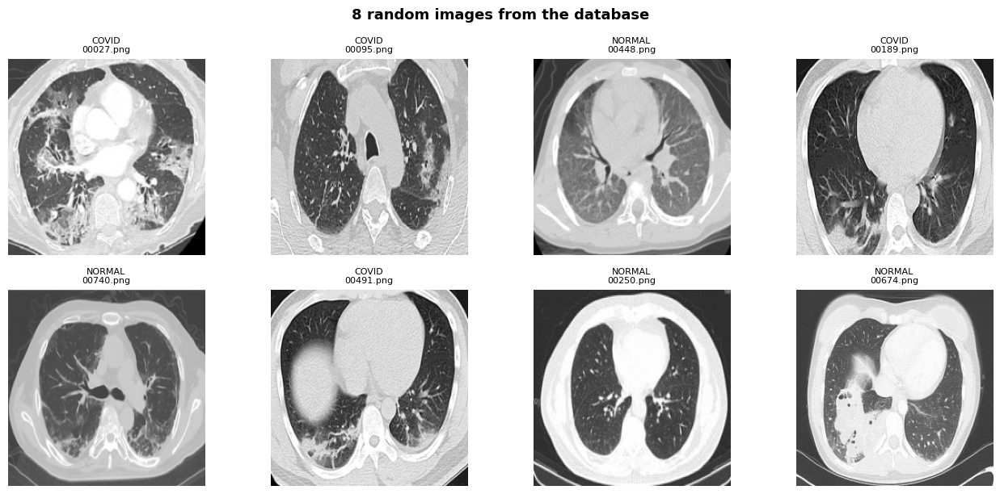


3) SIMILARITY: MY DENOISING AE  vs  ARTICLE  (PSNR / SSIM)

[matched] 30 / 30 article configurations

----- SIMILARITY SUMMARY -----


,Metric,N configs,Mean |Ours-Paper|,RMSE,Mean bias (Ours-Paper),Max |Ours-Paper|,Pearson r
0,PSNR,30,5.992953,7.630397,-5.968204,17.593625,0.369159
1,SSIM,30,0.153334,0.191959,-0.153334,0.440431,0.212513



----- PER-CONFIGURATION COMPARISON -----


,modality,noise,variance,PSNR,PSNR_paper,PSNR_diff,SSIM,SSIM_paper,SSIM_diff
15,ct,gaussian,0.05,23.473475,34.49,-11.016525,0.705129,0.9421,-0.236971
16,ct,gaussian,0.10,24.152845,31.26,-7.107155,0.664840,0.9003,-0.235460
17,ct,gaussian,0.15,23.137127,30.40,-7.262873,0.636319,0.8698,-0.233481
18,ct,gaussian,0.20,23.370238,27.71,-4.339762,0.622055,0.8363,-0.214245
19,ct,gaussian,0.25,22.205145,28.31,-6.104855,0.588234,0.8214,-0.233166
20,ct,salt_pepper,0.05,21.903987,38.20,-16.296013,0.663471,0.9811,-0.317629
21,ct,salt_pepper,0.10,23.476637,37.48,-14.003363,0.668489,0.9807,-0.312211
22,ct,salt_pepper,0.15,22.425069,34.34,-11.914931,0.662209,0.9703,-0.308091
23,ct,salt_pepper,0.20,20.476375,38.07,-17.593625,0.552593,0.9783,-0.425707
24,ct,salt_pepper,0.25,20.081548,35.43,-15.348452,0.527569,0.9680,-0.440431



[saved] C:\Users\USER\Desktop\DIP_PROJECT\results\table5_comparison_dropin.csv


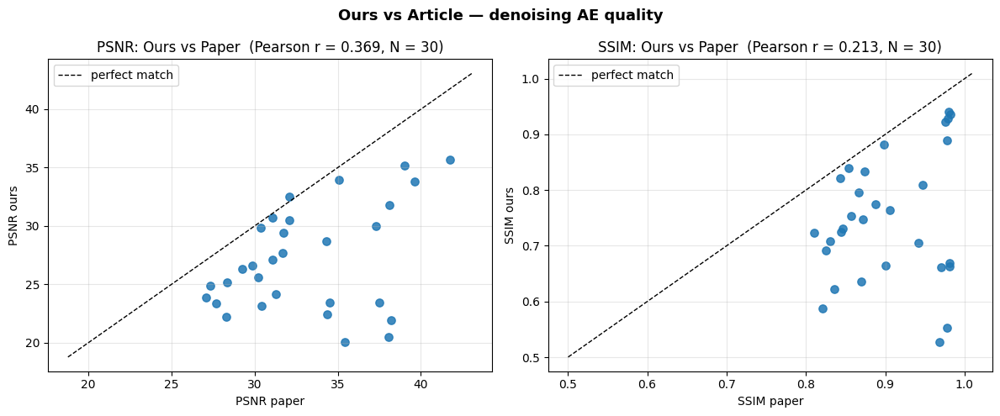


DROP-IN SUMMARY CELL DONE


In [2]:
# =====================================================================
#  DROP-IN SUMMARY CELL
#  1) All hyperparameters used   2) Random images from the database
#  3) Similarity: my AE PSNR/SSIM  vs  the article's
#  Safe to run on a fresh kernel OR after your full pipeline.
# =====================================================================
import os, glob, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings('ignore')

# ---- optional heavy deps ----
try:
    import cv2
    _HAS_CV = True
except Exception:
    _HAS_CV = False
try:
    from IPython.display import display as _idisplay
except Exception:
    _idisplay = None

def _show(df):
    if _idisplay is not None:
        _idisplay(df)
    else:
        with pd.option_context('display.max_columns', None,
                               'display.width', 200,
                               'display.max_rows', 400):
            print(df.to_string(index=False))

# ---------- paths / globals (reuse notebook values if already defined) ----------
PROJECT_ROOT = Path(globals().get('PROJECT_ROOT') or r"C:\Users\USER\Desktop\DIP_PROJECT")
SPLITS_DIR   = Path(globals().get('SPLITS_DIR')   or PROJECT_ROOT / "splits")
RESULTS_DIR  = Path(globals().get('RESULTS_DIR')  or PROJECT_ROOT / "results")
DATA_UNIFIED = Path(globals().get('DATA_UNIFIED') or PROJECT_ROOT / "data_unified")

IMG_SIZE    = int(globals().get('IMG_SIZE', 224))
NOISE_TYPES = globals().get('NOISE_TYPES', ['gaussian', 'salt_pepper', 'speckle'])
NOISE_VARS  = globals().get('NOISE_VARS',  [0.05, 0.10, 0.15, 0.20, 0.25])

# =====================================================================
# 1) ALL HYPERPARAMETERS
# =====================================================================
print("=" * 100)
print("1) ALL HYPERPARAMETERS USED IN THIS PROJECT")
print("=" * 100)

HP = [
    # ---- global / reproducibility ----
    ("Global",            "Random seed (SEED)",                        42),
    ("Global",            "Image size (IMG_SIZE)",                      "224 x 224 x 3"),
    ("Global",            "cudnn.benchmark",                           True),
    ("Global",            "Device",                                    str(globals().get('DEVICE', 'auto (cuda/cpu)'))),
    # ---- data ----
    ("Data",              "Noise types",                               ['gaussian', 'salt_pepper', 'speckle']),
    ("Data",              "Noise variances",                           [0.05, 0.10, 0.15, 0.20, 0.25]),
    ("Data",              "Train/test splits",                         ["80/20", "70/30", "60/40"]),
    ("Data",              "X-ray targets (COVID/PNEUMONIA/NORMAL)",     "1161 / 4240 / 3800"),
    ("Data",              "CT targets (COVID/NORMAL)",                  "1305 / 1457"),
    # ---- denoising autoencoder ----
    ("Denoising AE",      "Learning rate (AD_LR)",                     2e-4),
    ("Denoising AE",      "Adam betas (AD_B1, AD_B2)",                 "(0.5, 0.999)"),
    ("Denoising AE",      "Adam epsilon (AD_EPS)",                     1e-8),
    ("Denoising AE",      "Epochs (AE_TRAIN_EPOCHS, paper = 20)",      20),
    ("Denoising AE",      "Batch size (AD_BATCH / AE_BATCH_FAST)",     16),
    ("Denoising AE",      "Early-stop patience (AE_PATIENCE)",         3),
    ("Denoising AE",      "Train subset fraction (SUBSET_FRAC)",       1.0),
    ("Denoising AE",      "Eval samples per config (EVAL_SAMPLES)",    75),
    ("Denoising AE",      "Loss",                                      "MSE (modified Gaussian likelihood)"),
    ("Denoising AE",      "Optimizer",                                 "Adam"),
    ("Denoising AE",      "Encoder filters",                           "3 -> BN -> 128 -> 64 -> 32 (latent)"),
    ("Denoising AE",      "Decoder filters",                           "32 -> 64 -> 128 -> 3 (sigmoid)"),
    ("Denoising AE",      "Kernel / stride / padding",                 "3x3 / stride 1 / same (=1)"),
    ("Denoising AE",      "Mixed precision (AMP)",                     "enabled on CUDA"),
    # ---- paper classifier ----
    ("Classifier (paper)","Learning rate (CLS_LR)",                    1e-5),
    ("Classifier (paper)","Adam betas (CLS_B1, CLS_B2)",               "(0.9, 0.999)"),
    ("Classifier (paper)","Epochs (CLS_EPOCHS / CLS_EPOCHS_FAST)",     30),
    ("Classifier (paper)","Batch size (CLS_BATCH)",                    16),
    ("Classifier (paper)","Early-stop patience (CLS_PATIENCE)",        4),
    ("Classifier (paper)","Head learning rate",                        "CLS_LR * 10"),
    ("Classifier (paper)","Loss",                                      "CrossEntropyLoss"),
    ("Classifier (paper)","Optimizer",                                 "Adam"),
    ("Classifier (paper)","LR schedule (head-on-features)",            "StepLR(step=2, gamma=0.5)"),
    # ---- CT-specific fixes ----
    ("Classifier (CT fix)","CT FCNN LR (CT_FCNN_LR)",                  3e-4),
    ("Classifier (CT fix)","CT FCNN epochs (CT_FCNN_EPOCHS)",          40),
    ("Classifier (CT fix)","CT FCNN patience (CT_FCNN_PATIENCE)",      8),
    ("Classifier (CT fix)","CT FCNN dropout (CT_FCNN_DROPOUT)",        "(0.10, 0.05)"),
    ("Classifier (CT fix)","CT FCNN weight decay",                     1e-4),
    ("Classifier (CT fix)","CT FCNN LR schedule",                      "CosineAnnealingLR(T_max=40)"),
    ("Classifier (CT fix)","CT head epochs (CT_HEAD_EPOCHS_AUG)",      20),
    ("Classifier (CT fix)","CT head patience (CT_HEAD_PATIENCE)",      6),
    ("Classifier (CT fix)", "CT head LR schedule",                     "StepLR(step=4, gamma=0.5)"),
    # ---- transfer learning ----
    ("Transfer learning", "Use ImageNet pretrained (USE_PRETRAINED)",  True),
    ("Transfer learning", "Freeze backbone (FREEZE_BACKBONE)",         True),
    ("Transfer learning", "Pretrained weights",                        "IMAGENET1K_V1"),
    ("Transfer learning", "Batches (FCNN/VGG16/ResNet50/DenseNet121)", "32 / 32 / 16 / 16"),
    ("Transfer learning", "Head batch (feature-cache path)",           256),
    ("Transfer learning", "Feature-extract batch (VGG16/ResNet50/Dense)", "32 / 32 / 32"),
    ("Transfer learning", "CT augmentation",                           "RandomAffine(4 deg) + ColorJitter(0.5-1.5)"),
]

hp_df = pd.DataFrame(HP, columns=["Category", "Hyperparameter", "Value"])
_show(hp_df)

# =====================================================================
# 2) RANDOM IMAGES FROM THE DATABASE
# =====================================================================
print()
print("=" * 100)
print("2) RANDOM IMAGES FROM THE DATABASE")
print("=" * 100)

def _read_rgb(path):
    if _HAS_CV:
        bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if bgr is not None:
            return bgr[:, :, ::-1]        # BGR -> RGB
    from PIL import Image                  # fallback
    return np.array(Image.open(path).convert('RGB'))

def _gather_images(n_imgs=8):
    rows = []
    csvs = sorted(glob.glob(str(SPLITS_DIR / "*.csv")))
    if csvs:
        df = pd.read_csv(csvs[0])
        if 'split' in df.columns:
            df = df[df['split'] == 'test']
        if len(df):
            df = df.sample(n=min(n_imgs, len(df)), random_state=42)
            for _, r in df.iterrows():
                rows.append((r['filepath'], r.get('class', '?')))
    if not rows:
        files = sorted(str(p) for p in DATA_UNIFIED.rglob('*.png'))
        random.Random(42).shuffle(files)
        for f in files[:n_imgs]:
            rows.append((f, Path(f).parent.name))
    return rows

rows = _gather_images()
if not rows:
    print("[WARN] No images found. Set PROJECT_ROOT (or run the dataset-prep cells) and re-run.")
else:
    n = len(rows)
    cols = 4
    nrow = int(np.ceil(n / cols))
    fig, axes = plt.subplots(nrow, cols, figsize=(3.3 * cols, 3.1 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for i, (path, cls) in enumerate(rows):
        try:
            axes[i].imshow(_read_rgb(path))
            axes[i].set_title(f"{cls}\n{Path(path).name}", fontsize=8)
        except Exception as e:
            axes[i].text(0.5, 0.5, f"unreadable\n{e}", ha='center', va='center', fontsize=7)
        axes[i].axis('off')
    for j in range(n, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f"{n} random images from the database", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# =====================================================================
# 3) SIMILARITY: MY DENOISING AE  vs  ARTICLE  (PSNR / SSIM)
# =====================================================================
print()
print("=" * 100)
print("3) SIMILARITY: MY DENOISING AE  vs  ARTICLE  (PSNR / SSIM)")
print("=" * 100)

# ---- article Table 5 (reproduced in notebook Step 8) ----
paper_table5 = pd.DataFrame([
    ('xray','gaussian',0.05,37.30,0.9469),('ct','gaussian',0.05,34.49,0.9421),
    ('xray','gaussian',0.10,34.29,0.9063),('ct','gaussian',0.10,31.26,0.9003),
    ('xray','gaussian',0.15,31.66,0.8715),('ct','gaussian',0.15,30.40,0.8698),
    ('xray','gaussian',0.20,31.06,0.8444),('ct','gaussian',0.20,27.71,0.8363),
    ('xray','gaussian',0.25,29.86,0.8309),('ct','gaussian',0.25,28.31,0.8214),
    ('xray','salt_pepper',0.05,41.77,0.9801),('ct','salt_pepper',0.05,38.20,0.9811),
    ('xray','salt_pepper',0.10,39.01,0.9824),('ct','salt_pepper',0.10,37.48,0.9807),
    ('xray','salt_pepper',0.15,39.60,0.9758),('ct','salt_pepper',0.15,34.34,0.9703),
    ('xray','salt_pepper',0.20,35.08,0.9792),('ct','salt_pepper',0.20,38.07,0.9783),
    ('xray','salt_pepper',0.25,38.11,0.9779),('ct','salt_pepper',0.25,35.43,0.9680),
    ('xray','speckle',0.05,32.11,0.8979),('ct','speckle',0.05,30.20,0.8882),
    ('xray','speckle',0.10,32.11,0.8740),('ct','speckle',0.10,29.28,0.8575),
    ('xray','speckle',0.15,31.73,0.8669),('ct','speckle',0.15,28.33,0.8463),
    ('xray','speckle',0.20,31.10,0.8543),('ct','speckle',0.20,27.36,0.8100),
    ('xray','speckle',0.25,30.38,0.8433),('ct','speckle',0.25,27.10,0.8247),
], columns=['modality','noise','variance','PSNR_paper','SSIM_paper'])

# ---- my (ours) results ----
ae_df = globals().get('ae_df', None)
if ae_df is None or not hasattr(ae_df, '__len__') or len(ae_df) == 0:
    csv_path = RESULTS_DIR / 'ae_table5.csv'
    if csv_path.exists():
        ae_df = pd.read_csv(csv_path)
        print(f"[loaded] my results <- {csv_path}")
    else:
        ae_df = None
        print("[WARN] No 'ae_df' in memory and results/ae_table5.csv not found.")
        print("       Run the denoising-AE training cell (Step 7) first, then re-run.")

if ae_df is not None and len(ae_df) > 0:
    ours = ae_df.copy()
    ours['v']      = (ours['variance'].astype(float) * 100).round().astype(int)
    paper_table5['v'] = (paper_table5['variance'].astype(float) * 100).round().astype(int)

    merged = ours.merge(
        paper_table5[['modality', 'noise', 'v', 'PSNR_paper', 'SSIM_paper']],
        on=['modality', 'noise', 'v'], how='inner')

    merged['PSNR_diff'] = merged['PSNR'] - merged['PSNR_paper']
    merged['SSIM_diff'] = merged['SSIM'] - merged['SSIM_paper']

    print(f"\n[matched] {len(merged)} / {len(paper_table5)} article configurations\n")

    def _sim(df, metric, paper_col):
        y = df[metric].to_numpy(dtype=float)
        x = df[paper_col].to_numpy(dtype=float)
        d = y - x
        n = len(d)
        r = float(np.corrcoef(y, x)[0, 1]) if n > 1 else float('nan')
        return {
            'Metric': metric,
            'N configs': n,
            'Mean |Ours-Paper|': float(np.mean(np.abs(d))),
            'RMSE': float(np.sqrt(np.mean(d ** 2))),
            'Mean bias (Ours-Paper)': float(np.mean(d)),
            'Max |Ours-Paper|': float(np.max(np.abs(d))),
            'Pearson r': r,
        }

    sim_summary = pd.DataFrame([_sim(merged, 'PSNR', 'PSNR_paper'),
                                _sim(merged, 'SSIM', 'SSIM_paper')])
    print("----- SIMILARITY SUMMARY -----")
    _show(sim_summary)

    display_cols = [c for c in ['modality', 'noise', 'variance', 'PSNR', 'PSNR_paper',
                                'PSNR_diff', 'SSIM', 'SSIM_paper', 'SSIM_diff'] if c in merged.columns]
    print("\n----- PER-CONFIGURATION COMPARISON -----")
    _show(merged.sort_values(['modality', 'noise', 'v'])[display_cols])

    out_csv = RESULTS_DIR / 'table5_comparison_dropin.csv'
    merged.to_csv(out_csv, index=False)
    print(f"\n[saved] {out_csv}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric, paper_col in [(axes[0], 'PSNR', 'PSNR_paper'),
                                  (axes[1], 'SSIM', 'SSIM_paper')]:
        y = merged[metric].to_numpy(dtype=float)
        x = merged[paper_col].to_numpy(dtype=float)
        ax.scatter(x, y, s=45, alpha=0.85)
        lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
        pad = (hi - lo) * 0.06 + 1e-9
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', lw=1, label='perfect match')
        r = float(np.corrcoef(y, x)[0, 1]) if len(x) > 1 else float('nan')
        ax.set_title(f"{metric}: Ours vs Paper  (Pearson r = {r:.3f}, N = {len(x)})")
        ax.set_xlabel(f"{metric} paper")
        ax.set_ylabel(f"{metric} ours")
        ax.legend()
        ax.grid(alpha=0.3)
    fig.suptitle("Ours vs Article — denoising AE quality", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print()
print("DROP-IN SUMMARY CELL DONE")
